# MIMIC-AF — DDPM/DDIM



| § | Content |
|---|----------|
| 0 | Setup, constants, paths |
| 1 | Subject catalogue (CSV) |
| 2 | IBI feature extraction |
| 3 | Subject-level split + normalisation |
| 4 | Dataset & DataLoader |
| 5 | UNet1D backbone |
| 5b | Diffusion schedule + ddpm\_loss + samplers (ancestral + DDIM) |
| 6 | Training |
| 7 | Load checkpoint + visual inspection |
| 8 | Spectral evaluation (guidance sweep, LSD, PSD) |
| 9 | Physiological consistency |
| 10 | Statistical validation and other tests |
| 10b | NN Morphological Metrics (PRD + Pearson) |
| 10b-v2 | Morphological Metrics (PRD + Pearson) — paired |
| 10c | Conditioning Fidelity — non-paired |
| 10c-v2 | Conditioning Fidelity — paired |
| 11 | Functional validation — Clf1D (TRTR/TSTR-DDPM/TSTR-DDIM/ClfB) |
| 11b | Synthetic pool generation (DDIM) and ClufUNetGAN |
| 12- Part B Cross-domian | MIMIC-III |
| 12- Part C Cross-domian | Zenodo V2 |
| 12- Part D Cross-domian | VitalDB |
| 13- Data Scarcity  | Clf1D and ClfUNetGAN |

## §0 — Setup

In [2]:
import subprocess, sys
subprocess.check_call([sys.executable,'-m','pip','install','neurokit2','-q','--no-deps'])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 23.6 MB/s eta 0:00:00


0

In [3]:
import torch
torch.optim.AdamW([torch.nn.Parameter(torch.zeros(1))], lr=1e-3)
print("torch OK antes de continuar")

torch OK antes de continuar


In [4]:
import os, glob, warnings, random, time, copy, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch, find_peaks
from scipy.stats import wasserstein_distance
from scipy.spatial.distance import pdist
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.metrics import (roc_auc_score, precision_score, f1_score,
                              recall_score, accuracy_score, confusion_matrix)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
import neurokit2 as nk
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi':120,'font.size':10})

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed(SEED)

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = torch.cuda.is_available()
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

scaler_amp = torch.cuda.amp.GradScaler(
    enabled=USE_AMP, init_scale=128,
    growth_factor=2.0, backoff_factor=0.5, growth_interval=1000)

# ── Paths ──────────────────────────────────────────────────────────────────
MIMIC_AF_DIR   = '/kaggle/input/datasets/raditya0/mimic-perform-iii-af-and-non-af-dataset'
WORK_DIR       = '/kaggle/working'
IBI_SESSION    = os.path.join(WORK_DIR, 'ibi_session_mimic_af.csv')
CKPT_PATH_DDPM = os.path.join(WORK_DIR, 'best_model_mimic_af_ddpm_b2.pt')

# ── Signal constants ───────────────────────────────────────────────────────
FS      = 125
WIN_SEC = 10
WIN_LEN = FS * WIN_SEC          # 1250
PAD_LEN = (256 - WIN_LEN % 256) % 256   # 30
STEP    = WIN_LEN // 2          # 625 (50% overlap)
CAP     = 300
BATCH_SIZE = 64
EPOCHS  = 70
LR      = 1e-4
BASE_CH = 64
T_DIM   = 256
COND_DIM= 128
RAW_COND_DIM = 4                # IBI_mean, IBI_std, RMSSD, rhythm_sign
IBI_MIN = 0.3
IBI_MAX = 2.0
EMA_DECAY = 0.999
CFG_DROP  = 0.10
N_EVAL    = 300
EXCLUDED  = {'mimic_perform_non_af_014'}

# ── DDPM-specific constants ────────────────────────────────────────────────
T_STEPS       = 1000
BETA_SCHEDULE = 'cosine'        # 'linear' or 'cosine'
BETA_START    = 1e-4
BETA_END      = 0.02
DDIM_STEPS    = 100             # matches ODE_STEPS in OT-CFM for fair comparison

print(f'WIN_LEN={WIN_LEN}  PAD={PAD_LEN}  EPOCHS={EPOCHS}')
print(f'DDPM: T={T_STEPS}  schedule={BETA_SCHEDULE}  DDIM steps={DDIM_STEPS}')
print(f'CKPT: {CKPT_PATH_DDPM}')


Device: cuda
GPU   : Tesla T4
VRAM  : 15.6 GB
WIN_LEN=1250  PAD=30  EPOCHS=70
DDPM: T=1000  schedule=cosine  DDIM steps=100
CKPT: /kaggle/working/best_model_mimic_af_ddpm_b2.pt


## §1 — Subject Catalogue

In [5]:
af_csvs = sorted(glob.glob(os.path.join(MIMIC_AF_DIR,'af','*_data.csv')))
sr_csvs = sorted(glob.glob(os.path.join(MIMIC_AF_DIR,'non-af','*_data.csv')))
print(f'AF CSV files: {len(af_csvs)}  |  SR CSV files: {len(sr_csvs)}')

rows = []
for rhythm, csv_list in [('AF',af_csvs),('SR',sr_csvs)]:
    for fpath in csv_list:
        sid = os.path.basename(fpath).replace('_data.csv','')
        if sid in EXCLUDED: continue
        n_total   = 150001
        n_windows = (n_total - WIN_LEN) // STEP + 1
        for w in range(n_windows):
            rows.append({'csv_path':fpath,'subject_id':sid,
                         'event_rhythm':rhythm,
                         'start_sample':w*STEP,'window_idx':w})

df = pd.DataFrame(rows)

all_sids = df['subject_id'].unique()
af_sids  = set(df[df['event_rhythm']=='AF']['subject_id'].unique())
has_af   = [s for s in all_sids if s in af_sids]
no_af    = [s for s in all_sids if s not in af_sids]

def split_70_15_15(lst, seed=SEED):
    tr,tmp = train_test_split(lst,test_size=0.30,random_state=seed)
    vl,te  = train_test_split(tmp,test_size=0.50,random_state=seed)
    return tr,vl,te

af_tr,af_vl,af_te = split_70_15_15(has_af)
sr_tr,sr_vl,sr_te = split_70_15_15(no_af)
TRAIN_SIDS = set(af_tr)|set(sr_tr)
VAL_SIDS   = set(af_vl)|set(sr_vl)
TEST_SIDS  = set(af_te)|set(sr_te)
assert not(TRAIN_SIDS & VAL_SIDS) and not(TRAIN_SIDS & TEST_SIDS)

def cap_segs(df_fold,cap=CAP,seed=SEED):
    out=[]
    for(_,_),grp in df_fold.groupby(['subject_id','event_rhythm']):
        out.append(grp.sample(min(cap,len(grp)),random_state=seed))
    return pd.concat(out).reset_index(drop=True)

df_capped = pd.concat([
    cap_segs(df[df['subject_id'].isin(TRAIN_SIDS)]),
    cap_segs(df[df['subject_id'].isin(VAL_SIDS)]),
    cap_segs(df[df['subject_id'].isin(TEST_SIDS)]),
]).reset_index(drop=True)

print(f'Total subjects: {len(all_sids)}  (AF={len(has_af)} SR={len(no_af)})')
print(f'Split: Train={len(TRAIN_SIDS)} Val={len(VAL_SIDS)} Test={len(TEST_SIDS)}')
print(f'Windows after cap={CAP}: {len(df_capped):,}')


AF CSV files: 19  |  SR CSV files: 16
Total subjects: 34  (AF=19 SR=15)
Split: Train=23 Val=5 Test=6
Windows after cap=300: 8,126


## §2 — IBI Feature Extraction

In [6]:
_csv_cache = {}
def _load_csv(csv_path):
    if csv_path not in _csv_cache:
        d = pd.read_csv(csv_path)
        _csv_cache[csv_path] = {
            'PPG': d['PPG'].values.astype(np.float32),
            'ECG': d['ECG'].values.astype(np.float32),
        }
    return _csv_cache[csv_path]


def ecg_ibi_10s_csv(csv_path, start_sample):
    """IBI_mean, IBI_std, RMSSD from a 10s ECG slice (B2 conditioning)."""
    end = start_sample + WIN_LEN
    try:
        ecg = _load_csv(csv_path)['ECG'][start_sample:end]
        if len(ecg)<WIN_LEN or np.isnan(ecg).any() or np.all(ecg==ecg[0]):
            return None,None,None
        _,info = nk.ecg_peaks(ecg, sampling_rate=FS, method='neurokit')
        rr = np.diff(info['ECG_R_Peaks']) / FS
        rr = rr[(rr>=IBI_MIN)&(rr<=IBI_MAX)]
        if len(rr)<2: return None,None,None
        rmssd = float(np.sqrt(np.mean(np.diff(rr)**2)))
        return float(np.mean(rr)),float(np.std(rr)),rmssd
    except: return None,None,None


_cache_ok = os.path.exists(IBI_SESSION)
if _cache_ok:
    _peek = pd.read_csv(IBI_SESSION, nrows=1)
    if 'RMSSD' not in _peek.columns:
        print('Cache pre-RMSSD — deleting.'); os.remove(IBI_SESSION); _cache_ok=False

if _cache_ok:
    print(f'Loading cache: {IBI_SESSION}')
    df_ibi = pd.read_csv(IBI_SESSION)
    key_c  = df_ibi['csv_path']+'_'+df_ibi['start_sample'].astype(str)
    key_d  = df_capped['csv_path']+'_'+df_capped['start_sample'].astype(str)
    df_ibi = df_ibi[key_c.isin(set(key_d))].copy()
    print(f'Loaded: {len(df_ibi):,} records')
else:
    print(f'Computing IBI for {len(df_capped):,} windows...')
    rows_ibi,t0 = [],time.time()
    for i,(_,row) in enumerate(df_capped.iterrows()):
        if i%2000==0 and i>0:
            eta=(time.time()-t0)/i*(len(df_capped)-i)
            print(f'  {i}/{len(df_capped)}  ETA: {eta/60:.1f} min')
        im,is_,irm = ecg_ibi_10s_csv(row['csv_path'],int(row['start_sample']))
        rows_ibi.append({'csv_path':row['csv_path'],
                         'start_sample':int(row['start_sample']),
                         'subject_id':row['subject_id'],
                         'event_rhythm':row['event_rhythm'],
                         'window_idx':int(row['window_idx']),
                         'IBI_mean':im,'IBI_std':is_,'RMSSD':irm})
    df_ibi = pd.DataFrame(rows_ibi)
    df_ibi.to_csv(IBI_SESSION,index=False)
    print(f'Saved. Elapsed: {(time.time()-t0)/60:.1f} min')

df_ibi = df_ibi.dropna(subset=['IBI_mean','IBI_std','RMSSD'])
df_ibi = df_ibi[(df_ibi.IBI_mean>=IBI_MIN)&(df_ibi.IBI_mean<=IBI_MAX)&
                (df_ibi.IBI_std>=0)&(df_ibi.IBI_std<=0.5)].copy()
print(f'After filter: {len(df_ibi):,} windows')
for r in ['AF','SR']:
    s=df_ibi[df_ibi.event_rhythm==r]
    print(f'  {r}: {len(s):,}  IBI_mean={s.IBI_mean.mean():.4f}  '
          f'IBI_std={s.IBI_std.mean():.4f}  RMSSD={s.RMSSD.mean():.4f}')


Computing IBI for 8,126 windows...
  2000/8126  ETA: 0.2 min
  4000/8126  ETA: 0.1 min
  6000/8126  ETA: 0.1 min
  8000/8126  ETA: 0.0 min
Saved. Elapsed: 0.3 min
After filter: 8,029 windows
  AF: 4,507  IBI_mean=0.6626  IBI_std=0.1276  RMSSD=0.1837
  SR: 3,522  IBI_mean=0.7673  IBI_std=0.0266  RMSSD=0.0391


## §3 — Split + Normalisation

In [7]:
df_train = df_ibi[df_ibi.subject_id.isin(TRAIN_SIDS)].copy()
df_val   = df_ibi[df_ibi.subject_id.isin(VAL_SIDS)].copy()
df_test  = df_ibi[df_ibi.subject_id.isin(TEST_SIDS)].copy()
assert not(set(df_train.subject_id)&set(df_val.subject_id))
assert not(set(df_train.subject_id)&set(df_test.subject_id))

IBI_MEAN_MU  = df_train['IBI_mean'].mean(); IBI_MEAN_STD = df_train['IBI_mean'].std()
IBI_STD_MU   = df_train['IBI_std'].mean();  IBI_STD_STD  = df_train['IBI_std'].std()
RMSSD_MU     = df_train['RMSSD'].mean();    RMSSD_STD    = df_train['RMSSD'].std()

def norm_ibi(ibi_mean, ibi_std, rmssd):
    nm=(np.asarray(ibi_mean)-IBI_MEAN_MU)/(IBI_MEAN_STD+1e-8)
    ns=(np.asarray(ibi_std) -IBI_STD_MU) /(IBI_STD_STD +1e-8)
    nr=(np.asarray(rmssd)   -RMSSD_MU)   /(RMSSD_STD   +1e-8)
    return nm.astype(np.float32),ns.astype(np.float32),nr.astype(np.float32)

print(f'IBI_mean: μ={IBI_MEAN_MU:.4f}  σ={IBI_MEAN_STD:.4f}')
print(f'IBI_std : μ={IBI_STD_MU:.4f}  σ={IBI_STD_STD:.4f}')
print(f'RMSSD   : μ={RMSSD_MU:.4f}  σ={RMSSD_STD:.4f}')
print()
print('╔══════════════════════════════════════════════════════╗')
for name,fold in [('Train',df_train),('Val',df_val),('Test',df_test)]:
    af=(fold.event_rhythm=='AF').sum(); sr=len(fold)-af
    ns=fold.subject_id.nunique()
    print(f'║  {name:5s}: {len(fold):>6} segs (AF={af:>5}, SR={sr:>5})  {ns:>3} subjects  ║')
print('╚══════════════════════════════════════════════════════╝')


IBI_mean: μ=0.7107  σ=0.1700
IBI_std : μ=0.0852  σ=0.0727
RMSSD   : μ=0.1228  σ=0.1089

╔══════════════════════════════════════════════════════╗
║  Train:   5487 segs (AF= 3103, SR= 2384)   23 subjects  ║
║  Val  :   1195 segs (AF=  717, SR=  478)    5 subjects  ║
║  Test :   1347 segs (AF=  687, SR=  660)    6 subjects  ║
╚══════════════════════════════════════════════════════╝


## §4 — Dataset & DataLoader

In [8]:
def load_ppg(csv_path, start_sample):
    """Load, bandpass-filter and min-max normalise a 10s PPG window."""
    end = start_sample + WIN_LEN
    try:
        sig = _load_csv(csv_path)['PPG'][start_sample:end].copy()
        if len(sig)<WIN_LEN or np.isnan(sig).any() or np.all(sig==sig[0]):
            return None
        nyq=FS/2; b,a=butter(4,[0.5/nyq,8./nyq],btype='band')
        sig=filtfilt(b,a,sig)
        mn,mx=sig.min(),sig.max()
        if mx-mn<1e-8: return None
        return (2*(sig-mn)/(mx-mn)-1).astype(np.float32)
    except: return None


def build_cond(nm,ns,nr,rhythm):
    sign=np.full(len(nm),{'SR':-1.,'AF':1.}[rhythm],dtype=np.float32)
    return np.stack([nm,ns,nr,sign],axis=1)

def build_cond_from_df(nm,ns,nr,rhythms):
    sign=np.array([{'SR':-1.,'AF':1.}[r] for r in rhythms],dtype=np.float32)
    return np.stack([nm,ns,nr,sign],axis=1)


class PPGDataset(Dataset):
    LABEL={'SR':0,'AF':1}; RHYTHM_SIGN={'SR':-1.,'AF':1.}
    def __init__(self,df):
        self.df=df.reset_index(drop=True)
        nm,ns,nr=norm_ibi(df.IBI_mean.values,df.IBI_std.values,df.RMSSD.values)
        self.cond=build_cond_from_df(nm,ns,nr,df.event_rhythm.values)
    def __len__(self): return len(self.df)
    def __getitem__(self,idx):
        row=self.df.iloc[idx]
        sig=load_ppg(row['csv_path'],int(row['start_sample']))
        if sig is None: sig=np.random.uniform(-1,1,WIN_LEN).astype(np.float32)
        return (torch.from_numpy(sig).unsqueeze(0),
                torch.from_numpy(self.cond[idx]),
                self.LABEL[row['event_rhythm']])


ds_train=PPGDataset(df_train); ds_val=PPGDataset(df_val); ds_test=PPGDataset(df_test)
dl_train=DataLoader(ds_train,batch_size=BATCH_SIZE,shuffle=True,
                    num_workers=0,pin_memory=True,drop_last=True)
dl_val  =DataLoader(ds_val,  batch_size=BATCH_SIZE,shuffle=False,
                    num_workers=0,pin_memory=True)
dl_test =DataLoader(ds_test, batch_size=BATCH_SIZE,shuffle=False,
                    num_workers=0,pin_memory=True)
print(f'Train: {len(ds_train):,} | {len(dl_train)} batches')
print(f'Val:   {len(ds_val):,}  | {len(dl_val)} batches')
print(f'Test:  {len(ds_test):,}  | {len(dl_test)} batches')
s,c,l=next(iter(dl_train))
print(f'Batch: signal={s.shape}  cond={c.shape}  range=[{s.min():.2f},{s.max():.2f}]')


Train: 5,487 | 85 batches
Val:   1,195  | 19 batches
Test:  1,347  | 22 batches
Batch: signal=torch.Size([64, 1, 1250])  cond=torch.Size([64, 4])  range=[-1.00,1.00]


## §5 — UNet1D Backbone
Idêntico ao OT-CFM B2 — agnostic to the generative mechanism.

In [9]:
def sinusoidal_embedding(t,dim):
    half=dim//2
    freqs=torch.exp(-torch.arange(half,device=t.device,dtype=torch.float32)
                    *(np.log(10000)/(half-1)))
    args=t[:,None].float()*freqs[None]*1000
    return torch.cat([torch.sin(args),torch.cos(args)],dim=-1)

class AdaGN(nn.Module):
    def __init__(self,ch,emb_dim,groups=8):
        super().__init__()
        self.gn=nn.GroupNorm(groups,ch)
        self.scale=nn.Linear(emb_dim,ch); self.shift=nn.Linear(emb_dim,ch)
        nn.init.zeros_(self.scale.weight); nn.init.ones_(self.scale.bias)
        nn.init.zeros_(self.shift.weight); nn.init.zeros_(self.shift.bias)
    def forward(self,x,emb):
        return self.gn(x)*(1+self.scale(emb)[:,:,None])+self.shift(emb)[:,:,None]

class ResBlock(nn.Module):
    def __init__(self,ch,emb_dim,k=5,dropout=0.05):
        super().__init__()
        p=k//2
        self.c1=nn.Conv1d(ch,ch,k,padding=p); self.c2=nn.Conv1d(ch,ch,k,padding=p)
        self.a1=AdaGN(ch,emb_dim); self.a2=AdaGN(ch,emb_dim)
        self.act=nn.SiLU(); self.drop=nn.Dropout(dropout)
    def forward(self,x,emb):
        h=self.act(self.a1(self.c1(x),emb)); h=self.drop(h)
        return self.act(x+self.a2(self.c2(h),emb))

class UNet1D(nn.Module):
    def __init__(self,base_ch=BASE_CH,t_dim=T_DIM,cond_dim=COND_DIM):
        super().__init__()
        ch=base_ch; emb=t_dim+cond_dim
        self.t_proj=nn.Sequential(nn.Linear(t_dim,t_dim),nn.SiLU(),nn.Linear(t_dim,t_dim))
        self.c_proj=nn.Sequential(nn.Linear(RAW_COND_DIM,cond_dim),nn.SiLU(),nn.Linear(cond_dim,cond_dim))
        self.in_conv=nn.Conv1d(1,ch,7,padding=3)
        self.d1=nn.Sequential(ResBlock(ch,emb),ResBlock(ch,emb))
        self.p1=nn.Conv1d(ch,ch*2,4,stride=4)
        self.d2=nn.Sequential(ResBlock(ch*2,emb),ResBlock(ch*2,emb))
        self.p2=nn.Conv1d(ch*2,ch*4,4,stride=4)
        self.d3=nn.Sequential(ResBlock(ch*4,emb),ResBlock(ch*4,emb))
        self.p3=nn.Conv1d(ch*4,ch*8,4,stride=4)
        self.d4=nn.Sequential(ResBlock(ch*8,emb),ResBlock(ch*8,emb))
        self.p4=nn.Conv1d(ch*8,ch*8,4,stride=4)
        self.mid=nn.Sequential(ResBlock(ch*8,emb),ResBlock(ch*8,emb))
        self.u4=nn.ConvTranspose1d(ch*8,ch*8,4,stride=4)
        self.r4=nn.Sequential(ResBlock(ch*16,emb),ResBlock(ch*16,emb))
        self.c4=nn.Conv1d(ch*16,ch*8,1)
        self.u3=nn.ConvTranspose1d(ch*8,ch*4,4,stride=4)
        self.r3=nn.Sequential(ResBlock(ch*8,emb),ResBlock(ch*8,emb))
        self.c3=nn.Conv1d(ch*8,ch*4,1)
        self.u2=nn.ConvTranspose1d(ch*4,ch*2,4,stride=4)
        self.r2=nn.Sequential(ResBlock(ch*4,emb),ResBlock(ch*4,emb))
        self.c2_=nn.Conv1d(ch*4,ch*2,1)
        self.u1=nn.ConvTranspose1d(ch*2,ch,4,stride=4)
        self.r1=nn.Sequential(ResBlock(ch*2,emb),ResBlock(ch*2,emb))
        self.c1_=nn.Conv1d(ch*2,ch,1)
        self.out=nn.Sequential(nn.GroupNorm(8,ch),nn.SiLU(),nn.Conv1d(ch,1,7,padding=3))
    def _emb(self,t,cond):
        return torch.cat([self.t_proj(sinusoidal_embedding(t,T_DIM)),self.c_proj(cond)],dim=-1)
    def _run(self,blocks,x,emb):
        for b in blocks: x=b(x,emb); return x
    def forward(self,x,t,cond):
        L=x.shape[-1]
        if PAD_LEN>0: x=F.pad(x,(0,PAD_LEN),mode='reflect')
        emb=self._emb(t,cond); x0=self.in_conv(x)
        s1=self._run(self.d1,x0,emb); s2=self._run(self.d2,self.p1(s1),emb)
        s3=self._run(self.d3,self.p2(s2),emb); s4=self._run(self.d4,self.p3(s3),emb)
        m=self._run(self.mid,self.p4(s4),emb)
        def up(uc,ur,ucat,h,skip):
            h=uc(h); sl=min(h.shape[-1],skip.shape[-1])
            return ucat(self._run(ur,torch.cat([h[...,:sl],skip[...,:sl]],dim=1),emb))
        out=self.out(up(self.u1,self.r1,self.c1_,
                        up(self.u2,self.r2,self.c2_,
                           up(self.u3,self.r3,self.c3,
                              up(self.u4,self.r4,self.c4,m,s4),s3),s2),s1))
        return out[...,:L]

model=UNet1D().to(DEVICE)
n_params=sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'UNet1D — {n_params/1e6:.2f}M parameters')
with torch.no_grad():
    _o=model(torch.randn(4,1,WIN_LEN).to(DEVICE),torch.rand(4).to(DEVICE),
             torch.randn(4,RAW_COND_DIM).to(DEVICE))
assert _o.shape==(4,1,WIN_LEN), f'Shape mismatch: {_o.shape}'
print(f'Forward pass OK — output: {_o.shape}')


UNet1D — 54.87M parameters
Forward pass OK — output: torch.Size([4, 1, 1250])


## §5b — Diffusion Process
β schedule (cosine), forward noising `q_sample`, ε-prediction loss `ddpm_loss`,
ancestral sampler `ddpm_sample`, and accelerated DDIM sampler `ddim_sample`.
Reused verbatim from the MIMIC-III-Ext DDPM notebook — the schedule and samplers
are dataset-agnostic.

In [10]:
def linear_beta_schedule(T, beta_start=BETA_START, beta_end=BETA_END):
    return torch.linspace(beta_start, beta_end, T)

def cosine_beta_schedule(T, s=0.008):
    steps=T+1; x=torch.linspace(0,T,steps)
    ac=torch.cos(((x/T)+s)/(1+s)*math.pi*0.5)**2
    ac=ac/ac[0]; betas=1-(ac[1:]/ac[:-1])
    return torch.clip(betas,1e-4,0.9999)

class DiffusionSchedule:
    def __init__(self,T,schedule='cosine',device='cpu'):
        self.T=T
        betas=(cosine_beta_schedule(T) if schedule=='cosine'
               else linear_beta_schedule(T))
        alphas=1.-betas
        ac=torch.cumprod(alphas,dim=0)
        ac_prev=torch.cat([torch.ones(1),ac[:-1]])
        self.betas=betas.to(device)
        self.alphas=alphas.to(device)
        self.alphas_cumprod=ac.to(device)
        self.alphas_cumprod_prev=ac_prev.to(device)
        self.sqrt_alphas_cumprod=torch.sqrt(ac).to(device)
        self.sqrt_one_minus_alphas_cumprod=torch.sqrt(1.-ac).to(device)
        self.sqrt_recip_alphas=torch.sqrt(1./alphas).to(device)
        self.posterior_variance=(betas*(1.-ac_prev)/(1.-ac)).to(device)
        self.posterior_mean_coef1=(betas*torch.sqrt(ac_prev)/(1.-ac)).to(device)
        self.posterior_mean_coef2=((1.-ac_prev)*torch.sqrt(alphas)/(1.-ac)).to(device)

def q_sample(x0,t,schedule,noise=None):
    if noise is None: noise=torch.randn_like(x0)
    sa=schedule.sqrt_alphas_cumprod[t].view(-1,1,1)
    so=schedule.sqrt_one_minus_alphas_cumprod[t].view(-1,1,1)
    return sa*x0+so*noise, noise

def ddpm_loss(model,x0,cond,schedule,cfg_drop=CFG_DROP,reduction='mean'):
    B=x0.size(0)
    t=torch.randint(0,schedule.T,(B,),device=x0.device).long()
    t_norm=t.float()/schedule.T
    noise=torch.randn_like(x0)
    xt,_=q_sample(x0,t,schedule,noise)
    mask=(torch.rand(B,device=x0.device)<cfg_drop).float()
    cin=cond*(1-mask.unsqueeze(1))
    with torch.cuda.amp.autocast(enabled=USE_AMP):
        eps_pred=model(xt,t_norm,cin)
    if reduction=='none':
        return F.mse_loss(eps_pred.float(),noise,reduction='none').mean(dim=(1,2))
    return F.mse_loss(eps_pred.float(),noise)

diff_schedule=DiffusionSchedule(T_STEPS,schedule=BETA_SCHEDULE,device=DEVICE)
print(f'Schedule: {BETA_SCHEDULE}  T={T_STEPS}')
print(f'beta range: [{diff_schedule.betas.min():.6f}, {diff_schedule.betas.max():.6f}]')
print(f'alpha_bar_0={diff_schedule.alphas_cumprod[0]:.6f} (→1)  '
      f'alpha_bar_T={diff_schedule.alphas_cumprod[-1]:.6f} (→0)')
assert diff_schedule.alphas_cumprod[-1]<0.01
assert diff_schedule.alphas_cumprod[0] >0.99
print('Schedule validated OK')


Schedule: cosine  T=1000
beta range: [0.000100, 0.999900]
alpha_bar_0=0.999900 (→1)  alpha_bar_T=0.000000 (→0)
Schedule validated OK


In [11]:
@torch.no_grad()
def ddpm_sample(model,shape,cond,schedule,guidance_scale=1.0):
    """Ancestral (T steps). Mirrors ddim_sample signature for interchangeable use."""
    device=cond.device; x=torch.randn(shape,device=device)
    for t_step in reversed(range(schedule.T)):
        tb=torch.full((shape[0],),t_step,device=device,dtype=torch.long)
        tn=tb.float()/schedule.T
        eps_c=model(x,tn,cond)
        if guidance_scale!=1.0:
            eps_u=model(x,tn,torch.zeros_like(cond))
            eps=eps_u+guidance_scale*(eps_c-eps_u)
        else:
            eps=eps_c
        ab=schedule.alphas_cumprod[t_step].clamp(min=1e-8)
        x0_pred=((x-torch.sqrt(1-ab)*eps)/torch.sqrt(ab)).clamp(-1.,1.)
        c1=schedule.posterior_mean_coef1[t_step]
        c2=schedule.posterior_mean_coef2[t_step]
        mean=c1*x0_pred+c2*x
        if t_step>0:
            var=schedule.posterior_variance[t_step]
            x=mean+torch.sqrt(var)*torch.randn_like(x)
        else:
            x=mean
    return x

@torch.no_grad()
def ddim_sample(model,shape,cond,schedule,steps=DDIM_STEPS,
                guidance_scale=1.0,eta=0.0):
    """DDIM accelerated (deterministic by default, eta=0)."""
    device=cond.device
    step_idx=torch.linspace(0,schedule.T-1,steps).long().flip(0).to(device)
    x=torch.randn(shape,device=device)
    for i,t_step in enumerate(step_idx):
        tb=torch.full((shape[0],),t_step.item(),device=device,dtype=torch.long)
        tn=tb.float()/schedule.T
        eps_c=model(x,tn,cond)
        if guidance_scale!=1.0:
            eps_u=model(x,tn,torch.zeros_like(cond))
            eps=eps_u+guidance_scale*(eps_c-eps_u)
        else:
            eps=eps_c
        ab=schedule.alphas_cumprod[t_step].clamp(min=1e-8)
        x0_pred=((x-torch.sqrt(1-ab)*eps)/torch.sqrt(ab)).clamp(-1.,1.)
        ab_prev=(schedule.alphas_cumprod[step_idx[i+1]]
                 if i<len(step_idx)-1 else torch.tensor(1.,device=device))
        sigma=eta*torch.sqrt((1-ab_prev)/(1-ab)*(1-ab/ab_prev))
        dir_xt=torch.sqrt(1-ab_prev-sigma**2)*eps
        noise=sigma*torch.randn_like(x) if eta>0 else 0.
        x=torch.sqrt(ab_prev)*x0_pred+dir_xt+noise
    return x

# Sanity check
model.eval()
with torch.no_grad():
    _s,_c,_=next(iter(dl_val)); _c=_c[:4].to(DEVICE); _sh=(4,1,WIN_LEN)
    _xa=ddpm_sample(model,_sh,_c,diff_schedule)
    _xd=ddim_sample(model,_sh,_c,diff_schedule,steps=20)
assert _xa.shape==_sh and _xd.shape==_sh
print(f'ddpm_sample OK: {tuple(_xa.shape)}  (T={T_STEPS})')
print(f'ddim_sample OK: {tuple(_xd.shape)}  (20 steps, test)')
model.train()


ddpm_sample OK: (4, 1, 1250)  (T=1000)
ddim_sample OK: (4, 1, 1250)  (20 steps, test)


UNet1D(
  (t_proj): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): SiLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  )
  (c_proj): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (in_conv): Conv1d(1, 64, kernel_size=(7,), stride=(1,), padding=(3,))
  (d1): Sequential(
    (0): ResBlock(
      (c1): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (c2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (a1): AdaGN(
        (gn): GroupNorm(8, 64, eps=1e-05, affine=True)
        (scale): Linear(in_features=384, out_features=64, bias=True)
        (shift): Linear(in_features=384, out_features=64, bias=True)
      )
      (a2): AdaGN(
        (gn): GroupNorm(8, 64, eps=1e-05, affine=True)
        (scale): Linear(in_features=384, out_features=64, bias=True)
        (shift): Linear(in_features=384,

## §6 — Training

In [12]:
optimizer=torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=1e-3)
scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=EPOCHS)
EMA_DECAY=0.999
ema_model=copy.deepcopy(model); ema_model.eval()
for p in ema_model.parameters(): p.requires_grad_(False)

def update_ema(model,ema,decay=EMA_DECAY):
    with torch.no_grad():
        for p,ep in zip(model.parameters(),ema.parameters()):
            ep.data.mul_(decay).add_(p.data,alpha=1.-decay)

# Sanity check: random-init loss should be ~1.0
model.eval()
with torch.no_grad():
    _s,_c,_=next(iter(dl_train))
    _chk=ddpm_loss(model,_s.to(DEVICE),_c.to(DEVICE),diff_schedule).item()
print(f'Pre-train loss (expect ~1.0): {_chk:.4f}')
assert _chk>0.5, 'ERROR: model looks pre-trained — restart kernel.'
model.train()

print(f'Training — {EPOCHS} epochs | AMP={USE_AMP} | DDPM {BETA_SCHEDULE} T={T_STEPS}')
print(f'Train batches: {len(dl_train)} | Val batches: {len(dl_val)}')
print('-'*60)


Pre-train loss (expect ~1.0): 1.1171
Training — 70 epochs | AMP=True | DDPM cosine T=1000
Train batches: 85 | Val batches: 19
------------------------------------------------------------


In [13]:
history={'train':[],'val':[],'val_sr':[],'val_af':[]}
best_val_loss=float('inf'); skipped_total=0
LOG_BATCHES={0,1,10,50,84}
t0=time.time()

for epoch in range(1,EPOCHS+1):
    model.train(); tr_losses=[]; skipped_epoch=0
    if epoch==1: print('-- Epoch 1 batch-level loss ----------------------------')
    for bi,(sig,cond,_) in enumerate(dl_train):
        sig=sig.to(DEVICE,non_blocking=True)
        cond=cond.to(DEVICE,non_blocking=True)
        optimizer.zero_grad()
        loss=ddpm_loss(model,sig,cond,diff_schedule)
        scaler_amp.scale(loss).backward()
        scaler_amp.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(),1.0)
        sb=scaler_amp.get_scale()
        scaler_amp.step(optimizer); scaler_amp.update(); update_ema(model,ema_model)
        if scaler_amp.get_scale()<sb: skipped_epoch+=1
        tr_losses.append(loss.item())
        if epoch==1 and bi in LOG_BATCHES:
            print(f'  Batch {bi:>3}/{len(dl_train)-1}  loss={loss.item():.4f}  '
                  f'running={np.mean(tr_losses):.4f}')
    if epoch==1: print('-'*60)
    skipped_total+=skipped_epoch; scheduler.step()
    ema_model.eval(); vl_losses=[]; vc={0:[],1:[]}
    with torch.no_grad():
        for sig,cond,lbl in dl_val:
            sig=sig.to(DEVICE,non_blocking=True); cond=cond.to(DEVICE,non_blocking=True)
            ps=ddpm_loss(ema_model,sig,cond,diff_schedule,reduction='none').cpu().numpy()
            vl_losses.extend(ps.tolist())
            for c in(0,1):
                m=lbl.numpy()==c
                if m.any(): vc[c].extend(ps[m].tolist())
    tl=np.mean(tr_losses); vl=np.mean(vl_losses)
    history['train'].append(tl); history['val'].append(vl)
    history['val_sr'].append(np.mean(vc[0]) if vc[0] else float('nan'))
    history['val_af'].append(np.mean(vc[1]) if vc[1] else float('nan'))
    if epoch%5==0: torch.cuda.empty_cache()
    if vl<best_val_loss:
        best_val_loss=vl
        torch.save({'epoch':epoch,'model':model.state_dict(),
                    'ema_model':ema_model.state_dict(),'val_loss':vl,
                    'beta_schedule':BETA_SCHEDULE,'T_steps':T_STEPS,
                    'ibi_stats':{'mean_mu':IBI_MEAN_MU,'mean_std':IBI_MEAN_STD,
                                 'std_mu':IBI_STD_MU,'std_std':IBI_STD_STD,
                                 'rmssd_mu':RMSSD_MU,'rmssd_std':RMSSD_STD}},
                   CKPT_PATH_DDPM)
    if epoch%10==0 or epoch==1:
        el=(time.time()-t0)/60; sk_pct=skipped_epoch/len(dl_train)*100
        print(f'Epoch {epoch:>3}/{EPOCHS}  train={tl:.4f}  val={vl:.4f}  '
              f'(SR={history["val_sr"][-1]:.4f} AF={history["val_af"][-1]:.4f})  '
              f'best={best_val_loss:.4f}  skip={sk_pct:.0f}%  [{el:.1f} min]')

print('-'*60)
print(f'Training complete.  Best val loss: {best_val_loss:.4f}')
print(f'Total skipped steps: {skipped_total}/{EPOCHS*len(dl_train)} '
      f'({100*skipped_total/(EPOCHS*len(dl_train)):.1f}%)')


-- Epoch 1 batch-level loss ----------------------------
  Batch   0/84  loss=1.1146  running=1.1146
  Batch   1/84  loss=0.9011  running=1.0078
  Batch  10/84  loss=0.2051  running=0.5393
  Batch  50/84  loss=0.0778  running=0.2031
  Batch  84/84  loss=0.0699  running=0.1489
------------------------------------------------------------
Epoch   1/70  train=0.1489  val=0.8906  (SR=0.8963 AF=0.8869)  best=0.8906  skip=0%  [0.3 min]
Epoch  10/70  train=0.0317  val=0.0801  (SR=0.0783 AF=0.0813)  best=0.0801  skip=0%  [2.8 min]
Epoch  20/70  train=0.0285  val=0.0505  (SR=0.0487 AF=0.0517)  best=0.0489  skip=0%  [5.6 min]
Epoch  30/70  train=0.0280  val=0.0424  (SR=0.0401 AF=0.0439)  best=0.0424  skip=0%  [8.3 min]
Epoch  40/70  train=0.0267  val=0.0394  (SR=0.0375 AF=0.0406)  best=0.0389  skip=0%  [11.0 min]
Epoch  50/70  train=0.0247  val=0.0348  (SR=0.0333 AF=0.0358)  best=0.0345  skip=0%  [13.8 min]
Epoch  60/70  train=0.0246  val=0.0336  (SR=0.0309 AF=0.0354)  best=0.0314  skip=0%  [16.5

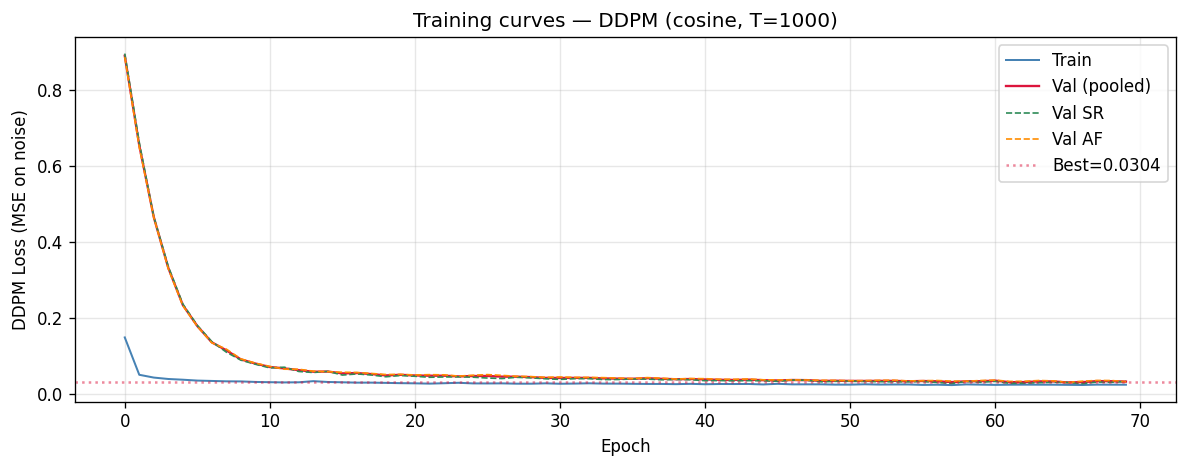

Final: train=0.0244  val=0.0327


In [14]:
fig,ax=plt.subplots(figsize=(10,4))
ax.plot(history['train'],label='Train',color='steelblue',lw=1.2)
ax.plot(history['val'],  label='Val (pooled)',color='crimson',lw=1.4)
ax.plot(history['val_sr'],label='Val SR',color='seagreen',lw=1.0,ls='--')
ax.plot(history['val_af'],label='Val AF',color='darkorange',lw=1.0,ls='--')
ax.axhline(best_val_loss,color='crimson',ls=':',alpha=0.5,
           label=f'Best={best_val_loss:.4f}')
ax.set_xlabel('Epoch'); ax.set_ylabel('DDPM Loss (MSE on noise)')
ax.set_title(f'Training curves — DDPM ({BETA_SCHEDULE}, T={T_STEPS})')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f'Final: train={history["train"][-1]:.4f}  '
      f'val={history["val"][-1]:.4f}')


## §7 — Load Best Checkpoint + Visual Inspection

In [ ]:
#Cell used to load the best saved model: best_cfm_zenodov2_01102
#To do this, I need to comment out the line “ckpt torch.load(CKPT_PATH,...)” 
#and uncomment the following line, where the path “path_para_modelo” 
#must be replaced with the actual path pointing to the model file.

# Load best checkpoint
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
#ckpt = torch.load('path_para_modelo/best_model_af_00304.pt', map_location=DEVICE, weights_only=False)

ema_model.load_state_dict(ckpt['ema_model'])
ema_model.eval()
model.load_state_dict(ckpt['model']); model.eval()
print(f'Checkpoint loaded — epoch {ckpt["epoch"]}  val_loss={ckpt["val_loss"]:.4f}')
print(f'schedule={ckpt["beta_schedule"]}  T={ckpt["T_steps"]}')

In [15]:
N_VIS=50; vis_real,vis_ddpm,vis_ddim,timing={},{},{},{}
for rh in ['AF','SR']:
    df_cls=df_test[df_test.event_rhythm==rh].sample(
        min(N_VIS,len(df_test[df_test.event_rhythm==rh])),random_state=SEED)
    nm,ns,nr=norm_ibi(df_cls.IBI_mean.values,df_cls.IBI_std.values,df_cls.RMSSD.values)
    cond=torch.tensor(build_cond(nm,ns,nr,rh),dtype=torch.float32).to(DEVICE)
    vis_real[rh]=np.array([s for s in
        [load_ppg(r['csv_path'],int(r['start_sample'])) for _,r in df_cls.iterrows()]
        if s is not None][:N_VIS])
    t0=time.time()
    chunks=[]
    for i in range(0,len(cond),64):
        c=cond[i:i+64]
        chunks.append(ddpm_sample(ema_model,(c.size(0),1,WIN_LEN),c,diff_schedule).cpu().numpy())
    vis_ddpm[rh]=np.concatenate(chunks).squeeze(1); t_anc=time.time()-t0
    t0=time.time()
    chunks=[]
    for i in range(0,len(cond),64):
        c=cond[i:i+64]
        chunks.append(ddim_sample(ema_model,(c.size(0),1,WIN_LEN),c,diff_schedule,
                                  steps=DDIM_STEPS).cpu().numpy())
    vis_ddim[rh]=np.concatenate(chunks).squeeze(1); t_ddim=time.time()-t0
    timing[rh]=(t_anc,t_ddim)
    print(f'{rh}: ancestral={t_anc:.1f}s  DDIM={t_ddim:.1f}s  speedup x{t_anc/t_ddim:.1f}')


Checkpoint loaded — epoch 66  val_loss=0.0304
schedule=cosine  T=1000
AF: ancestral=52.0s  DDIM=5.1s  speedup x10.1
SR: ancestral=51.6s  DDIM=5.2s  speedup x10.0


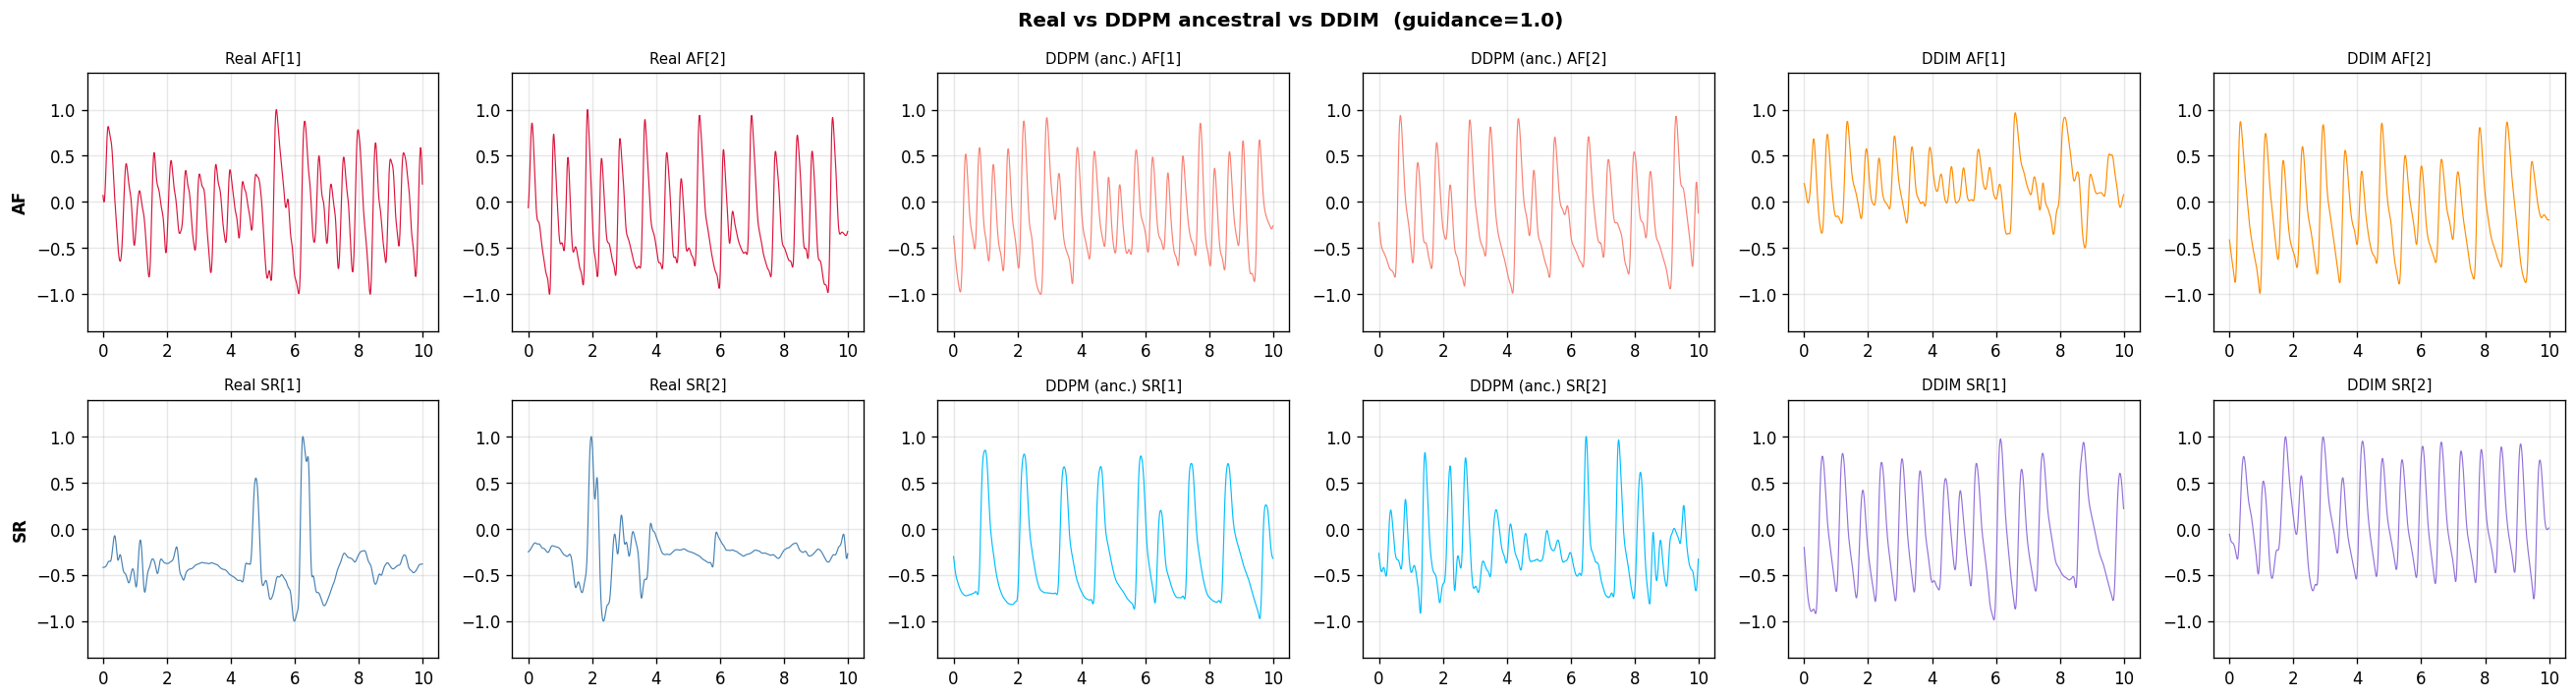

In [16]:
t_ax=np.arange(WIN_LEN)/FS
fig,axes=plt.subplots(2,6,figsize=(22,6))
sources=[('Real',vis_real,'crimson','steelblue'),
         ('DDPM (anc.)',vis_ddpm,'salmon','deepskyblue'),
         ('DDIM',vis_ddim,'darkorange','mediumpurple')]
for ri,rh in enumerate(['AF','SR']):
    ci=0
    for sname,sdict,ca,cs in sources:
        clr=ca if rh=='AF' else cs
        for k in range(2):
            ax=axes[ri][ci]
            ax.plot(t_ax,sdict[rh][k],lw=0.7,color=clr)
            ax.set_title(f'{sname} {rh}[{k+1}]',fontsize=9)
            ax.set_ylim(-1.4,1.4); ax.grid(alpha=0.3)
            if ci==0: ax.set_ylabel(rh,fontweight='bold'); 
            ci+=1
plt.suptitle('Real vs DDPM ancestral vs DDIM  (guidance=1.0)',fontweight='bold')
plt.tight_layout(); plt.show()


## §8 — Spectral Evaluation (Guidance Sweep + LSD + PSD)

In [17]:
def lsd(real_b,synth_b,n_fft=512,band=None):
    eps=1e-10; vals=[]; mask=None
    for i in range(min(len(real_b),len(synth_b))):
        f,r=welch(real_b[i],fs=FS,nperseg=n_fft)
        _,s=welch(synth_b[i],fs=FS,nperseg=n_fft)
        if band is not None and mask is None: mask=(f>=band[0])&(f<=band[1])
        ru,su=(r[mask],s[mask]) if band is not None else (r,s)
        v=np.sqrt(np.mean((10*np.log10(ru+eps)-10*np.log10(su+eps))**2))
        if not np.isnan(v): vals.append(v)
    return float(np.mean(vals)) if vals else np.nan

# ── Guidance sweep on DDIM (fast) — optimise LSD AF ─────────────────────────
GS_VALUES=[0.5,1.0,1.5,2.0,2.5,3.0]
N_GS=100
df_gs=df_test[df_test.event_rhythm=='AF'].sample(min(N_GS,
    len(df_test[df_test.event_rhythm=='AF'])),random_state=SEED)
real_gs=np.array([s for s in
    [load_ppg(r['csv_path'],int(r['start_sample'])) for _,r in df_gs.iterrows()]
    if s is not None][:N_GS])
nm,ns,nr=norm_ibi(df_gs.IBI_mean.values,df_gs.IBI_std.values,df_gs.RMSSD.values)
cond_gs=torch.tensor(build_cond(nm,ns,nr,'AF'),dtype=torch.float32).to(DEVICE)[:N_GS]

print('Guidance sweep (DDIM, AF LSD):')
gs_results={}
for gs in GS_VALUES:
    chunks=[]
    for i in range(0,len(cond_gs),64):
        c=cond_gs[i:i+64]
        chunks.append(ddim_sample(ema_model,(c.size(0),1,WIN_LEN),c,
                                  diff_schedule,steps=DDIM_STEPS,
                                  guidance_scale=gs).cpu().numpy())
    synth_gs=np.concatenate(chunks).squeeze(1)
    l=lsd(real_gs,synth_gs,band=(0.5,8.0))
    gs_results[gs]=l
    print(f'  GS={gs:.1f}  LSD(AF,DDIM)={l:.2f} dB')

BEST_GS_DDIM=min(gs_results,key=gs_results.get)
print(f'\nBest guidance scale (DDIM): {BEST_GS_DDIM}  (LSD={gs_results[BEST_GS_DDIM]:.2f} dB)')


Guidance sweep (DDIM, AF LSD):
  GS=0.5  LSD(AF,DDIM)=5.70 dB
  GS=1.0  LSD(AF,DDIM)=5.58 dB
  GS=1.5  LSD(AF,DDIM)=5.91 dB
  GS=2.0  LSD(AF,DDIM)=6.00 dB
  GS=2.5  LSD(AF,DDIM)=5.56 dB
  GS=3.0  LSD(AF,DDIM)=5.51 dB

Best guidance scale (DDIM): 3.0  (LSD=5.51 dB)


In [18]:
GS_VALUES = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
N_GS = 80

print('Guidance sweep (DDIM, joint AF+SR LSD):')
gs_results = {}
for gs in GS_VALUES:
    lsd_parts = []
    for rh in ['AF', 'SR']:
        df_gs = df_test[df_test.event_rhythm == rh].sample(
            min(N_GS, len(df_test[df_test.event_rhythm == rh])), random_state=SEED)
        real_gs = np.array([s for s in
            [load_ppg(r['csv_path'], int(r['start_sample'])) for _, r in df_gs.iterrows()]
            if s is not None][:N_GS])
        nm, ns, nr = norm_ibi(df_gs.IBI_mean.values, df_gs.IBI_std.values, df_gs.RMSSD.values)
        cond_gs = torch.tensor(build_cond(nm, ns, nr, rh), dtype=torch.float32).to(DEVICE)
        chunks = []
        for i in range(0, len(cond_gs), 64):
            c = cond_gs[i:i+64]
            chunks.append(ddim_sample(ema_model, (c.size(0),1,WIN_LEN), c,
                                       diff_schedule, steps=DDIM_STEPS,
                                       guidance_scale=gs).cpu().numpy())
        synth_gs = np.concatenate(chunks).squeeze(1)
        lsd_parts.append(lsd(real_gs, synth_gs, band=(0.5, 8.0)))
    joint = float(np.mean(lsd_parts))
    gs_results[gs] = {'joint': joint, 'AF': lsd_parts[0], 'SR': lsd_parts[1]}
    print(f'  GS={gs:.1f}  joint={joint:.2f} dB  (AF={lsd_parts[0]:.2f}  SR={lsd_parts[1]:.2f})')

BEST_GS_DDIM = min(gs_results, key=lambda g: gs_results[g]['joint'])
BEST_GS_DDPM = 1.0   # conservative for ancestral — CFG less critical at T=1000 steps
print(f'\nBest GS (DDIM, joint): {BEST_GS_DDIM}  '
      f'(joint={gs_results[BEST_GS_DDIM]["joint"]:.2f} dB  '
      f'AF={gs_results[BEST_GS_DDIM]["AF"]:.2f}  '
      f'SR={gs_results[BEST_GS_DDIM]["SR"]:.2f})')
print(f'DDPM ancestral GS: {BEST_GS_DDPM}  (fixed — sweep would take ~30 min)')

Guidance sweep (DDIM, joint AF+SR LSD):
  GS=0.5  joint=7.17 dB  (AF=5.91  SR=8.43)
  GS=1.0  joint=7.49 dB  (AF=5.70  SR=9.29)
  GS=1.5  joint=7.40 dB  (AF=5.72  SR=9.08)
  GS=2.0  joint=7.14 dB  (AF=5.46  SR=8.82)
  GS=2.5  joint=7.11 dB  (AF=5.33  SR=8.89)
  GS=3.0  joint=7.31 dB  (AF=5.62  SR=9.00)

Best GS (DDIM, joint): 2.5  (joint=7.11 dB  AF=5.33  SR=8.89)
DDPM ancestral GS: 1.0  (fixed — sweep would take ~30 min)


In [19]:
# ── Full eval set (N_EVAL/class) with both samplers ──────────────────────────
eval_real,eval_ddpm,eval_ddim={},{},{}
for rh in ['AF','SR']:
    df_cls=df_test[df_test.event_rhythm==rh].sample(
        min(N_EVAL,len(df_test[df_test.event_rhythm==rh])),random_state=SEED)
    nm,ns,nr=norm_ibi(df_cls.IBI_mean.values,df_cls.IBI_std.values,df_cls.RMSSD.values)
    cond=torch.tensor(build_cond(nm,ns,nr,rh),dtype=torch.float32).to(DEVICE)
    real=[load_ppg(r['csv_path'],int(r['start_sample'])) for _,r in df_cls.iterrows()]
    eval_real[rh]=np.array([s for s in real if s is not None][:N_EVAL])
    sa,sd=[],[]
    for i in range(0,len(cond),64):
        c=cond[i:i+64]
        sa.append(ddpm_sample(ema_model,(c.size(0),1,WIN_LEN),c,
                              diff_schedule,guidance_scale=BEST_GS_DDIM).cpu().numpy())
        sd.append(ddim_sample(ema_model,(c.size(0),1,WIN_LEN),c,
                              diff_schedule,steps=DDIM_STEPS,
                              guidance_scale=BEST_GS_DDIM).cpu().numpy())
    eval_ddpm[rh]=np.concatenate(sa).squeeze(1)
    eval_ddim[rh]=np.concatenate(sd).squeeze(1)
    print(f'{rh}: real={len(eval_real[rh])}  ddpm={eval_ddpm[rh].shape[0]}  '
          f'ddim={eval_ddim[rh].shape[0]}')

# Use DDIM as primary eval_synth (faster, comparable quality)
eval_synth=eval_ddim

print()
for name,es in [('DDPM (ancestral)',eval_ddpm),('DDIM',eval_ddim)]:
    la=lsd(eval_real['AF'],es['AF'],band=(0.5,8.)); ls_=lsd(eval_real['SR'],es['SR'],band=(0.5,8.))
    la_f=lsd(eval_real['AF'],es['AF']); ls_f=lsd(eval_real['SR'],es['SR'])
    print(f'[{name}]')
    print(f'  LSD (0.5-8 Hz): AF={la:.2f} dB  SR={ls_:.2f} dB  mean={(la+ls_)/2:.2f} dB')
    print(f'  LSD (full):     AF={la_f:.2f} dB  SR={ls_f:.2f} dB  (inflated by out-of-band)')
lsd_af=lsd(eval_real['AF'],eval_ddim['AF'],band=(0.5,8.))
lsd_sr=lsd(eval_real['SR'],eval_ddim['SR'],band=(0.5,8.))


AF: real=300  ddpm=300  ddim=300
SR: real=261  ddpm=300  ddim=300

[DDPM (ancestral)]
  LSD (0.5-8 Hz): AF=5.46 dB  SR=10.29 dB  mean=7.87 dB
  LSD (full):     AF=15.28 dB  SR=18.45 dB  (inflated by out-of-band)
[DDIM]
  LSD (0.5-8 Hz): AF=5.70 dB  SR=8.71 dB  mean=7.21 dB
  LSD (full):     AF=13.25 dB  SR=24.42 dB  (inflated by out-of-band)


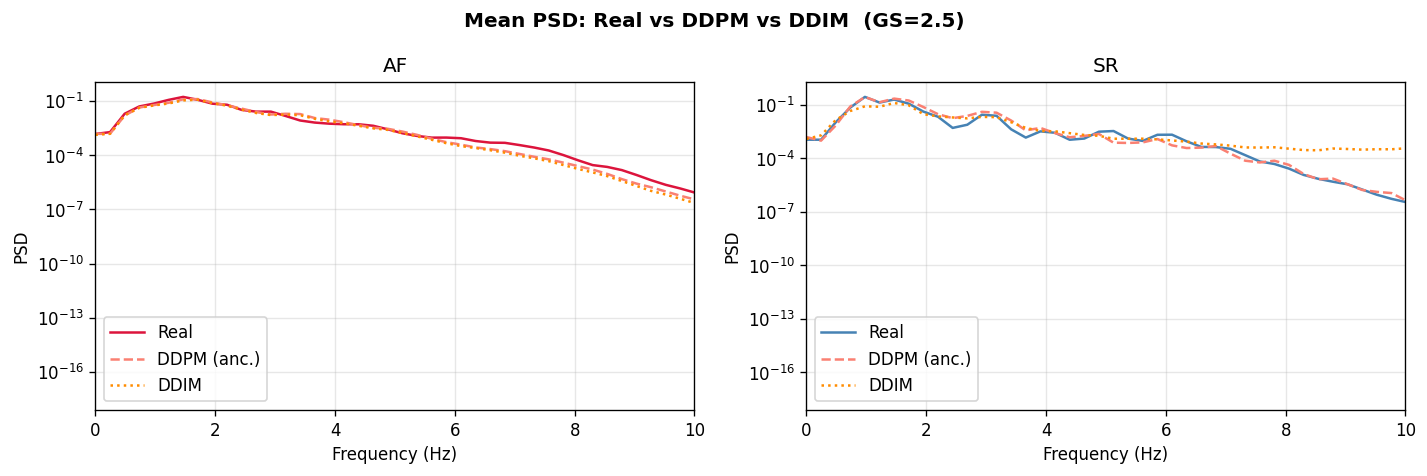

In [20]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
for ax,rh in zip(axes,['AF','SR']):
    psd_r,psd_ddpm,psd_ddim=[],[],[]
    for i in range(min(200,len(eval_real[rh]))):
        _,p=welch(eval_real[rh][i],fs=FS,nperseg=512);  psd_r.append(p)
        _,p=welch(eval_ddpm[rh][i],fs=FS,nperseg=512); psd_ddpm.append(p)
        _,p=welch(eval_ddim[rh][i],fs=FS,nperseg=512); psd_ddim.append(p)
    freq=np.linspace(0,FS/2,len(psd_r[0]))
    ca='crimson' if rh=='AF' else 'steelblue'
    ax.semilogy(freq,np.mean(psd_r,0),   color=ca,      lw=1.5,     label='Real')
    ax.semilogy(freq,np.mean(psd_ddpm,0),color='salmon', lw=1.5,ls='--',label='DDPM (anc.)')
    ax.semilogy(freq,np.mean(psd_ddim,0),color='darkorange',lw=1.5,ls=':',label='DDIM')
    ax.set_xlim(0,10); ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('PSD')
    ax.set_title(rh); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle(f'Mean PSD: Real vs DDPM vs DDIM  (GS={BEST_GS_DDIM})',fontweight='bold')
plt.tight_layout(); plt.show()


## §9 — Physiological Consistency

In [21]:
def ppg_hr(sig, fs=FS):
    try:
        peaks, _ = find_peaks(sig, distance=int(fs * 0.3), height=0.05)
        if len(peaks) < 3:
            return np.nan, np.nan, np.nan, np.nan
        ibi = np.diff(peaks) / fs
        ibi = ibi[(ibi >= IBI_MIN) & (ibi <= IBI_MAX)]
        if len(ibi) < 2:
            return np.nan, np.nan, np.nan, np.nan
        rmssd = float(np.sqrt(np.mean(np.diff(ibi) ** 2)))
        return 60.0 / np.mean(ibi), np.mean(ibi), np.std(ibi), rmssd
    except Exception:
        return np.nan, np.nan, np.nan, np.nan


print('Computing physiological features (real, DDPM ancestral, DDIM)...')
phy_metrics = {}
for rh in ['AF', 'SR']:
    for kind, src in [
        ('real', eval_real),
        ('ddpm', eval_ddpm),
        ('ddim', eval_ddim),
    ]:
        hrs, ibim, ibis, rmssds = [], [], [], []
        for sig in src[rh]:
            h, m, s, rm = ppg_hr(sig)
            if not np.isnan(h):
                hrs.append(h)
                ibim.append(m)
                ibis.append(s)
                rmssds.append(rm)
        phy_metrics[f'{rh}_{kind}'] = {
            'HR': hrs,
            'IBI_mean': ibim,
            'IBI_std': ibis,
            'RMSSD': rmssds,
        }

print(
    f'\n{"Metric":<12}  {"Real AF":>12}  {"DDPM AF":>12}  {"DDIM AF":>12}  '
    f'{"Real SR":>12}  {"DDPM SR":>12}  {"DDIM SR":>12}'
)
print('-' * 96)
for feat in ['HR', 'IBI_mean', 'IBI_std', 'RMSSD']:
    vals = []
    for key in [
        'AF_real',
        'AF_ddpm',
        'AF_ddim',
        'SR_real',
        'SR_ddpm',
        'SR_ddim',
    ]:
        v = phy_metrics[key][feat]
        vals.append(f'{np.mean(v):.3f}\u00b1{np.std(v):.3f}' if v else 'N/A')
    print(f'  {feat:<10}  {"".join([f"{x:>12}  " for x in vals])}')

print('\n-- Variability ratios (synth / real, ideal = 1.0) --')
for rh in ['AF', 'SR']:
    real_std = np.mean(phy_metrics[f'{rh}_real']['IBI_std'])
    real_rmssd = np.mean(phy_metrics[f'{rh}_real']['RMSSD'])
    for kind in ['ddpm', 'ddim']:
        syn_std = np.mean(phy_metrics[f'{rh}_{kind}']['IBI_std'])
        syn_rmssd = np.mean(phy_metrics[f'{rh}_{kind}']['RMSSD'])
        print(
            f'  {rh} {kind:<4}: IBI_std ratio={syn_std/real_std:.2f} | RMSSD ratio={syn_rmssd/real_rmssd:.2f}'
        )

Computing physiological features (real, DDPM ancestral, DDIM)...

Metric             Real AF       DDPM AF       DDIM AF       Real SR       DDPM SR       DDIM SR
------------------------------------------------------------------------------------------------
  HR          102.364±16.029  102.792±17.297  104.859±17.654  75.474±16.420  75.575±15.490  85.538±23.400  
  IBI_mean     0.600±0.091   0.601±0.112   0.589±0.103   0.835±0.188   0.829±0.172   0.746±0.174  
  IBI_std      0.124±0.051   0.129±0.058   0.127±0.064   0.099±0.118   0.056±0.090   0.133±0.100  
  RMSSD        0.175±0.073   0.180±0.082   0.182±0.097   0.148±0.189   0.081±0.134   0.188±0.144  

-- Variability ratios (synth / real, ideal = 1.0) --
  AF ddpm: IBI_std ratio=1.04 | RMSSD ratio=1.03
  AF ddim: IBI_std ratio=1.02 | RMSSD ratio=1.04
  SR ddpm: IBI_std ratio=0.57 | RMSSD ratio=0.55
  SR ddim: IBI_std ratio=1.34 | RMSSD ratio=1.27


## §10 — Statistical Validation and other tests

This section includes the following statistical evaluation tests and analysis cells:

* **Wasserstein Distance**
* **Maximum Mean Discrepancy (MMD)**
* **Dynamic Time Warping (DTW)**
* **t-SNE**
* **Nearest-Neighbour Morphological Similarity** (PRD + Pearson)
* **Paired PRD / Pearson** (Conditioning-Vector-Paired)
* **Conditioning Fidelity:** HR MAE and IBI_std Ratio
* **Conditioning Fidelity:** Paired

In [22]:
def feature_vec(signals):
    feats=[]
    for sig in signals:
        try:
            peaks,_=find_peaks(sig,distance=int(FS*0.3),height=0.1)
            hr_v=[FS*60/d for d in np.diff(peaks) if 30<FS*60/d<200]
            hr_m=np.mean(hr_v) if hr_v else 75.; hr_s=np.std(hr_v) if len(hr_v)>1 else 0.
        except: hr_m,hr_s=75.,0.
        freq,pxx=welch(sig,fs=FS,nperseg=256)
        p_lo=np.trapezoid(pxx[(freq>=0)&(freq<4)],freq[(freq>=0)&(freq<4)])
        p_hi=np.trapezoid(pxx[(freq>=4)&(freq<8)],freq[(freq>=4)&(freq<8)])
        feats.append([hr_m,hr_s,p_lo,p_hi,np.sqrt(np.mean(sig**2))])
    return np.array(feats)

N_STAT=min(200,len(eval_real['AF']),len(eval_real['SR']))
feat_names=['HR_mean','HR_std','Power_0-4Hz','Power_4-8Hz','RMS']
feats={'real_AF':feature_vec(eval_real['AF'][:N_STAT]),
       'real_SR':feature_vec(eval_real['SR'][:N_STAT]),
       'ddpm_AF':feature_vec(eval_ddpm['AF'][:N_STAT]),
       'ddpm_SR':feature_vec(eval_ddpm['SR'][:N_STAT]),
       'ddim_AF':feature_vec(eval_ddim['AF'][:N_STAT]),
       'ddim_SR':feature_vec(eval_ddim['SR'][:N_STAT])}

for name,key in [('DDPM (ancestral)','ddpm'),('DDIM','ddim')]:
    print(f'[{name}] Wasserstein (real vs synthetic):')
    print(f'{"Feature":<15}  {"AF":>10}  {"SR":>10}')
    print('-'*40)
    for i,fn in enumerate(feat_names):
        wa=wasserstein_distance(feats['real_AF'][:,i],feats[f'{key}_AF'][:,i])
        ws=wasserstein_distance(feats['real_SR'][:,i],feats[f'{key}_SR'][:,i])
        print(f'  {fn:<13}  {wa:>10.4f}  {ws:>10.4f}')
    print()


[DDPM (ancestral)] Wasserstein (real vs synthetic):
Feature                  AF          SR
----------------------------------------
  HR_mean            1.9317      3.8634
  HR_std             0.7678      4.9748
  Power_0-4Hz        0.0133      0.0446
  Power_4-8Hz        0.0005      0.0026
  RMS                0.0140      0.0915

[DDIM] Wasserstein (real vs synthetic):
Feature                  AF          SR
----------------------------------------
  HR_mean            2.8300     11.2485
  HR_std             0.4774      8.6642
  Power_0-4Hz        0.0275      0.0922
  Power_4-8Hz        0.0009      0.0019
  RMS                0.0260      0.0828



In [23]:
def mmd_rbf(X,Y,gamma=None):
    X=np.atleast_2d(X); Y=np.atleast_2d(Y)
    if gamma is None:
        Z=np.vstack([X,Y]); d2=pdist(Z,'sqeuclidean')
        gamma=1./(np.median(d2)+1e-8)
    def rbf(A,B):
        d2=np.sum(A**2,1)[:,None]+np.sum(B**2,1)[None,:]-2*A@B.T
        return np.exp(-gamma*np.clip(d2,0,None))
    Kxx,Kyy,Kxy=rbf(X,X),rbf(Y,Y),rbf(X,Y)
    m,n=len(X),len(Y)
    return float((Kxx.sum()-np.trace(Kxx))/(m*(m-1))
                 +(Kyy.sum()-np.trace(Kyy))/(n*(n-1))
                 -2*Kxy.sum()/(m*n))

print('MMD\u00b2 (features standardised, RBF kernel):')
print(f'{"Sampler":<18}  {"AF":>10}  {"SR":>10}')
print('-'*44)
sc_all=StandardScaler().fit(np.vstack([feats['real_AF'],feats['real_SR']]))
for name,key in [('DDPM (ancestral)','ddpm'),('DDIM','ddim')]:
    maf=mmd_rbf(sc_all.transform(feats['real_AF']),sc_all.transform(feats[f'{key}_AF']))
    msr=mmd_rbf(sc_all.transform(feats['real_SR']),sc_all.transform(feats[f'{key}_SR']))
    print(f'  {name:<16}  {maf:>10.5f}  {msr:>10.5f}')


MMD² (features standardised, RBF kernel):
Sampler                     AF          SR
--------------------------------------------
  DDPM (ancestral)     0.00841     0.15581
  DDIM                 0.03438     0.23774


In [44]:
DOWN_FACTOR=5; DTW_BAND=25; N_DTW=30

def dtw_distance(a,b,band):
    n,m=len(a),len(b); D=np.full((n+1,m+1),np.inf); D[0,0]=0.
    for i in range(1,n+1):
        for j in range(max(1,i-band),min(m,i+band)+1):
            D[i,j]=abs(a[i-1]-b[j-1])+min(D[i-1,j],D[i,j-1],D[i-1,j-1])
    return D[n,m]

def dtw_nn_summary(real_sigs,synth_sigs,n=N_DTW,down=DOWN_FACTOR,band=DTW_BAND,seed=SEED):
    rng=np.random.RandomState(seed)
    idx_r=rng.choice(len(real_sigs),min(n,len(real_sigs)),replace=False)
    idx_s=rng.choice(len(synth_sigs),min(n,len(synth_sigs)),replace=False)
    R=[real_sigs[i][::down] for i in idx_r]; S=[synth_sigs[i][::down] for i in idx_s]
    D=np.zeros((len(S),len(R)))
    for i,s in enumerate(S):
        for j,r in enumerate(R): D[i,j]=dtw_distance(s,r,band)
    return float(D.min(axis=1).mean()),float(D.min(axis=0).mean())

print(f'DTW NN (N={N_DTW}, down x{DOWN_FACTOR}, band={DTW_BAND}):')
print(f'{"Sampler":<18}  {"AF fid":>9}  {"AF cov":>9}  {"SR fid":>9}  {"SR cov":>9}')
print('-'*60)
for name,src in [('DDPM (ancestral)',eval_ddpm),('DDIM',eval_ddim)]:
    fa,ca=dtw_nn_summary(eval_real['AF'],src['AF'])
    fs,cs=dtw_nn_summary(eval_real['SR'],src['SR'])
    print(f'  {name:<16}  {fa:>9.3f}  {ca:>9.3f}  {fs:>9.3f}  {cs:>9.3f}')


DTW NN (N=30, down x5, band=25):
Sampler                AF fid     AF cov     SR fid     SR cov
------------------------------------------------------------
  DDPM (ancestral)     33.487     33.074     21.835     38.289
  DDIM                 33.537     30.942     38.626     31.442


In [45]:
DOWN_FACTOR = 5
DTW_BAND = 25
N_DTW = 30


def dtw_distance(a, b, band):
    n, m = len(a), len(b)
    D = np.full((n + 1, m + 1), np.inf)
    D[0, 0] = 0.0
    for i in range(1, n + 1):
        for j in range(max(1, i - band), min(m, i + band) + 1):
            D[i, j] = abs(a[i - 1] - b[j - 1]) + min(
                D[i - 1, j], D[i, j - 1], D[i - 1, j - 1]
            )
    return D[n, m]


def dtw_nn_summary(
    real_sigs,
    synth_sigs,
    n=N_DTW,
    down=DOWN_FACTOR,
    band=DTW_BAND,
    seed=SEED,
):
    rng = np.random.RandomState(seed)
    idx_r = rng.choice(len(real_sigs), min(n, len(real_sigs)), replace=False)
    idx_s = rng.choice(len(synth_sigs), min(n, len(synth_sigs)), replace=False)
    R = [real_sigs[i][::down] for i in idx_r]
    S = [synth_sigs[i][::down] for i in idx_s]
    D = np.zeros((len(S), len(R)))
    for i, s in enumerate(S):
        for j, r in enumerate(R):
            D[i, j] = dtw_distance(s, r, band)
    return float(D.min(axis=1).mean()), float(D.min(axis=0).mean())


def dtw_nn_baseline(
    real_sigs, n=N_DTW, down=DOWN_FACTOR, band=DTW_BAND, seed=SEED
):
    """Real vs Real baseline: divide o dataset real em dois grupos disjuntos e

    calcula a distância DTW entre eles (evita comparar um sinal consigo mesmo).
    """
    rng = np.random.RandomState(seed)
    k = min(n, len(real_sigs) // 2)
    indices = rng.choice(len(real_sigs), 2 * k, replace=False)
    real_A = [real_sigs[i] for i in indices[:k]]
    real_B = [real_sigs[i] for i in indices[k:]]
    fid, cov = dtw_nn_summary(
        real_A, real_B, n=k, down=down, band=band, seed=seed
    )
    return fid, cov, (fid + cov) / 2


# ── 1. Calcular baselines Real vs Real ─────────────────────────────────────────
print("Computing DTW baselines (Real vs Real)...")
base_af_fid, base_af_cov, base_af = dtw_nn_baseline(eval_real['AF'])
base_sr_fid, base_sr_cov, base_sr = dtw_nn_baseline(eval_real['SR'])

print(f"  AF baseline (média): {base_af:.3f}")
print(f"  SR baseline (média): {base_sr:.3f}\n")

# ── 2. Tabela de Comparação dos Samplers + Baseline ───────────────────────────
print(f"DTW NN (N={N_DTW}, down x{DOWN_FACTOR}, band={DTW_BAND}):")
print(
    f"{'Sampler':<18}  {'AF fid':>9}  {'AF cov':>9}  {'SR fid':>9}  {'SR cov':>9}"
)
print("─" * 60)

# Linha da Baseline Real vs Real
print(
    f"{'Baseline (R↔R)':<18}  {base_af_fid:>9.3f}  {base_af_cov:>9.3f}  {base_sr_fid:>9.3f}  {base_sr_cov:>9.3f}"
)

# Loop pelos samplers DDPM
samplers = [('DDPM (ancestral)', eval_ddpm), ('DDIM', eval_ddim)]
results = {}

for name, src in samplers:
    fa, ca = dtw_nn_summary(eval_real['AF'], src['AF'])
    fs, cs = dtw_nn_summary(eval_real['SR'], src['SR'])
    results[name] = (fa, ca, fs, cs)
    print(f"{name:<18}  {fa:>9.3f}  {ca:>9.3f}  {fs:>9.3f}  {cs:>9.3f}")

# ── 3. Overhead individual vs Baseline ─────────────────────────────────────────
print("\nOverhead vs Baseline (Real vs Real):")
print("─" * 60)
for name, (fa, ca, fs, cs) in results.items():
    print(f"• {name}:")
    print(
        f"  AF — Fidelidade: {fa - base_af:+.3f} | Cobertura: {ca - base_af:+.3f}"
    )
    print(
        f"  SR — Fidelidade: {fs - base_sr:+.3f} | Cobertura: {cs - base_sr:+.3f}"
    )

print(
    "\n(Overhead próximo de 0 → sintéticos tão variáveis quanto sinais reais entre si)"
)
print(
    "(Menor Fidelidade e Cobertura são melhores; Baseline é o piso natural)"
)

Computing DTW baselines (Real vs Real)...
  AF baseline (média): 31.799
  SR baseline (média): 24.355

DTW NN (N=30, down x5, band=25):
Sampler                AF fid     AF cov     SR fid     SR cov
────────────────────────────────────────────────────────────
Baseline (R↔R)         31.643     31.956     22.439     26.271
DDPM (ancestral)       33.487     33.074     21.835     38.289
DDIM                   33.537     30.942     38.626     31.442

Overhead vs Baseline (Real vs Real):
────────────────────────────────────────────────────────────
• DDPM (ancestral):
  AF — Fidelidade: +1.688 | Cobertura: +1.275
  SR — Fidelidade: -2.519 | Cobertura: +13.934
• DDIM:
  AF — Fidelidade: +1.738 | Cobertura: -0.858
  SR — Fidelidade: +14.271 | Cobertura: +7.087

(Overhead próximo de 0 → sintéticos tão variáveis quanto sinais reais entre si)
(Menor Fidelidade e Cobertura são melhores; Baseline é o piso natural)


Computing t-SNE...


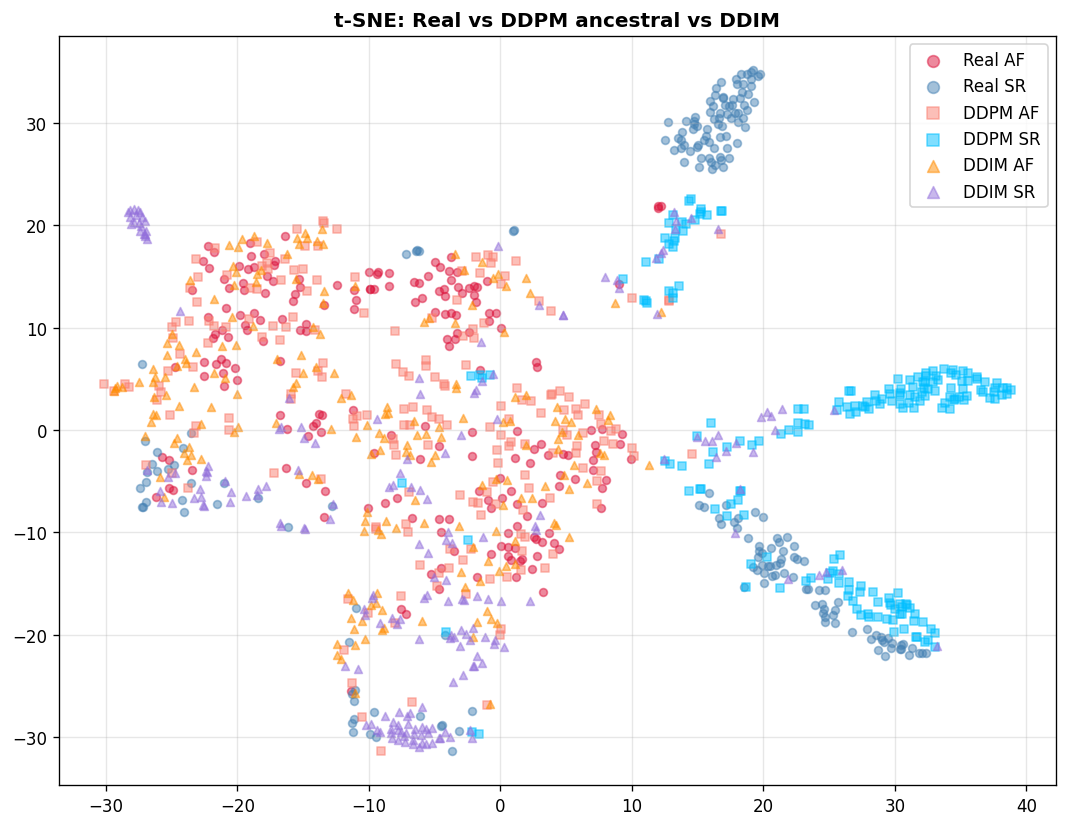

In [26]:
all_keys=['real_AF','real_SR','ddpm_AF','ddpm_SR','ddim_AF','ddim_SR']
label_map={'real_AF':'Real AF','real_SR':'Real SR',
           'ddpm_AF':'DDPM AF','ddpm_SR':'DDPM SR',
           'ddim_AF':'DDIM AF','ddim_SR':'DDIM SR'}
colours={'Real AF':'crimson','Real SR':'steelblue',
         'DDPM AF':'salmon','DDPM SR':'deepskyblue',
         'DDIM AF':'darkorange','DDIM SR':'mediumpurple'}
markers={'Real AF':'o','Real SR':'o','DDPM AF':'s','DDPM SR':'s',
         'DDIM AF':'^','DDIM SR':'^'}
all_f=np.concatenate([feats[k] for k in all_keys])
all_l=np.concatenate([[label_map[k]]*len(feats[k]) for k in all_keys])
sc=StandardScaler().fit_transform(all_f)
print('Computing t-SNE...')
emb=TSNE(n_components=2,perplexity=40,random_state=SEED,n_iter=1000).fit_transform(sc)
fig,ax=plt.subplots(figsize=(9,7))
for key in all_keys:
    lbl2=label_map[key]; mask=all_l==lbl2
    ax.scatter(emb[mask,0],emb[mask,1],c=colours[lbl2],marker=markers[lbl2],
               alpha=0.5,s=22,label=lbl2)
ax.set_title('t-SNE: Real vs DDPM ancestral vs DDIM',fontweight='bold')
ax.legend(markerscale=1.5); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


## §10b — Nearest-Neighbour Morphological Metrics (PRD + Pearson)

`eval_synth = eval_ddim` (primary). Synth→Real NN is compared against the Real↔Real baseline to distinguish *generator quality* from *inter-patient morphological variability*.

In [27]:
# eval_synth already set to eval_ddim above
def prd_signal(real,synth):
    num=np.sum((real-synth)**2); den=np.sum(real**2)
    return 100.*np.sqrt(num/(den+1e-10))

def nn_metrics(real_sigs,synth_sigs,n=200,seed=SEED):
    rng=np.random.default_rng(seed)
    idx_r=rng.choice(len(real_sigs),min(n,len(real_sigs)),replace=False)
    idx_s=rng.choice(len(synth_sigs),min(n,len(synth_sigs)),replace=False)
    R,S=real_sigs[idx_r],synth_sigs[idx_s]
    D=pairwise_distances(S,R,metric='euclidean'); nn_i=D.argmin(axis=1)
    prds,pccs=[],[]
    for i,j in enumerate(nn_i):
        prds.append(prd_signal(R[j],S[i]))
        r=np.corrcoef(R[j],S[i])[0,1]
        if not np.isnan(r): pccs.append(r)
    return float(np.mean(prds)),float(np.std(prds)),float(np.mean(pccs)),float(np.std(pccs))

def nn_metrics_real_vs_real(real_sigs,n=200,seed=SEED+1):
    rng=np.random.default_rng(seed)
    n_use=min(n*2,len(real_sigs)); idx=rng.choice(len(real_sigs),n_use,replace=False)
    nh=n_use//2; R1,R2=real_sigs[idx[:nh]],real_sigs[idx[nh:2*nh]]
    D=pairwise_distances(R1,R2,metric='euclidean'); nn_i=D.argmin(axis=1)
    prds,pccs=[],[]
    for i,j in enumerate(nn_i):
        prds.append(prd_signal(R2[j],R1[i]))
        r=np.corrcoef(R2[j],R1[i])[0,1]
        if not np.isnan(r): pccs.append(r)
    return float(np.mean(prds)),float(np.std(prds)),float(np.mean(pccs)),float(np.std(pccs))

print('Computing nearest-neighbour PRD and Pearson (n=200 per class)...')
nn_res={}
for rh in ['AF','SR']:
    pm,ps,cm,cs=nn_metrics(eval_real[rh],eval_synth[rh])
    rpm,rps,rcm,rcs=nn_metrics_real_vs_real(eval_real[rh])
    nn_res[rh]=dict(prd_sv=(pm,ps),pcc_sv=(cm,cs),prd_rr=(rpm,rps),pcc_rr=(rcm,rcs))
    print(f'  {rh} done')

print()
print('='*80)
print('  \u00a710b \u2014 Nearest-Neighbour Morphological Metrics  (eval_synth = DDIM)')
print('='*80)
for rh in ['AF','SR']:
    r=nn_res[rh]
    pm,ps=r['prd_sv']; cm,cs=r['pcc_sv']
    rpm,rps=r['prd_rr']; rcm,rcs=r['pcc_rr']
    print(f'  {"─"*72}')
    print(f'  Class: {rh}')
    print(f'  {"PRD (%)":<28}  {pm:>8.2f}\u00b1{ps:>6.2f} (NN)    {rpm:>8.2f}\u00b1{rps:>6.2f} (Real\u2194Real)')
    print(f'  {"Pearson":<28}  {cm:>8.4f}\u00b1{cs:>6.4f} (NN)    {rcm:>8.4f}\u00b1{rcs:>6.4f} (Real\u2194Real)')
print('='*80)
print()
print('PRD > 100% and low Pearson are EXPECTED for generation (vs reconstruction).')
print('Key question: Synth\u2192Real values comparable to Real\u2194Real baseline?')
for rh in ['AF','SR']:
    r=nn_res[rh]
    print(f'  {rh}: PRD overhead={r["prd_sv"][0]-r["prd_rr"][0]:+.2f}%  '
          f'Pearson gap={r["pcc_sv"][0]-r["pcc_rr"][0]:+.4f}')


Computing nearest-neighbour PRD and Pearson (n=200 per class)...
  AF done
  SR done

  §10b — Nearest-Neighbour Morphological Metrics  (eval_synth = DDIM)
  ────────────────────────────────────────────────────────────────────────
  Class: AF
  PRD (%)                         120.40± 24.22 (NN)      115.66± 26.83 (Real↔Real)
  Pearson                         0.2936±0.1550 (NN)      0.3455±0.1576 (Real↔Real)
  ────────────────────────────────────────────────────────────────────────
  Class: SR
  PRD (%)                         117.96± 56.48 (NN)       65.93± 34.31 (Real↔Real)
  Pearson                         0.4392±0.2803 (NN)      0.7105±0.2895 (Real↔Real)

PRD > 100% and low Pearson are EXPECTED for generation (vs reconstruction).
Key question: Synth→Real values comparable to Real↔Real baseline?
  AF: PRD overhead=+4.73%  Pearson gap=-0.0518
  SR: PRD overhead=+52.03%  Pearson gap=-0.2714


**Nearest-Neighbour Morphological Metrics (PRD + Pearson) para o sampler Ancestral**

In [28]:
# eval_synth already set to eval_ddim above
eval_novo = eval_ddpm
def prd_signal(real,synth):
    num=np.sum((real-synth)**2); den=np.sum(real**2)
    return 100.*np.sqrt(num/(den+1e-10))

def nn_metrics(real_sigs,synth_sigs,n=200,seed=SEED):
    rng=np.random.default_rng(seed)
    idx_r=rng.choice(len(real_sigs),min(n,len(real_sigs)),replace=False)
    idx_s=rng.choice(len(synth_sigs),min(n,len(synth_sigs)),replace=False)
    R,S=real_sigs[idx_r],synth_sigs[idx_s]
    D=pairwise_distances(S,R,metric='euclidean'); nn_i=D.argmin(axis=1)
    prds,pccs=[],[]
    for i,j in enumerate(nn_i):
        prds.append(prd_signal(R[j],S[i]))
        r=np.corrcoef(R[j],S[i])[0,1]
        if not np.isnan(r): pccs.append(r)
    return float(np.mean(prds)),float(np.std(prds)),float(np.mean(pccs)),float(np.std(pccs))

def nn_metrics_real_vs_real(real_sigs,n=200,seed=SEED+1):
    rng=np.random.default_rng(seed)
    n_use=min(n*2,len(real_sigs)); idx=rng.choice(len(real_sigs),n_use,replace=False)
    nh=n_use//2; R1,R2=real_sigs[idx[:nh]],real_sigs[idx[nh:2*nh]]
    D=pairwise_distances(R1,R2,metric='euclidean'); nn_i=D.argmin(axis=1)
    prds,pccs=[],[]
    for i,j in enumerate(nn_i):
        prds.append(prd_signal(R2[j],R1[i]))
        r=np.corrcoef(R2[j],R1[i])[0,1]
        if not np.isnan(r): pccs.append(r)
    return float(np.mean(prds)),float(np.std(prds)),float(np.mean(pccs)),float(np.std(pccs))

print('Computing nearest-neighbour PRD and Pearson (n=200 per class)...')
nn_res={}
for rh in ['AF','SR']:
    pm,ps,cm,cs=nn_metrics(eval_real[rh],eval_novo[rh])
    rpm,rps,rcm,rcs=nn_metrics_real_vs_real(eval_real[rh])
    nn_res[rh]=dict(prd_sv=(pm,ps),pcc_sv=(cm,cs),prd_rr=(rpm,rps),pcc_rr=(rcm,rcs))
    print(f'  {rh} done')

print()
print('='*80)
print('  \u00a710b \u2014 Nearest-Neighbour Morphological Metrics  (eval_synth = Ancestral)')
print('='*80)
for rh in ['AF','SR']:
    r=nn_res[rh]
    pm,ps=r['prd_sv']; cm,cs=r['pcc_sv']
    rpm,rps=r['prd_rr']; rcm,rcs=r['pcc_rr']
    print(f'  {"─"*72}')
    print(f'  Class: {rh}')
    print(f'  {"PRD (%)":<28}  {pm:>8.2f}\u00b1{ps:>6.2f} (NN)    {rpm:>8.2f}\u00b1{rps:>6.2f} (Real\u2194Real)')
    print(f'  {"Pearson":<28}  {cm:>8.4f}\u00b1{cs:>6.4f} (NN)    {rcm:>8.4f}\u00b1{rcs:>6.4f} (Real\u2194Real)')
print('='*80)
print()
print('PRD > 100% and low Pearson are EXPECTED for generation (vs reconstruction).')
print('Key question: Synth\u2192Real values comparable to Real\u2194Real baseline?')
for rh in ['AF','SR']:
    r=nn_res[rh]
    print(f'  {rh}: PRD overhead={r["prd_sv"][0]-r["prd_rr"][0]:+.2f}%  '
          f'Pearson gap={r["pcc_sv"][0]-r["pcc_rr"][0]:+.4f}')


Computing nearest-neighbour PRD and Pearson (n=200 per class)...
  AF done
  SR done

  §10b — Nearest-Neighbour Morphological Metrics  (eval_synth = Ancestral)
  ────────────────────────────────────────────────────────────────────────
  Class: AF
  PRD (%)                         114.84± 22.31 (NN)      115.66± 26.83 (Real↔Real)
  Pearson                         0.3372±0.1418 (NN)      0.3455±0.1576 (Real↔Real)
  ────────────────────────────────────────────────────────────────────────
  Class: SR
  PRD (%)                          76.93± 43.02 (NN)       65.93± 34.31 (Real↔Real)
  Pearson                         0.7072±0.2670 (NN)      0.7105±0.2895 (Real↔Real)

PRD > 100% and low Pearson are EXPECTED for generation (vs reconstruction).
Key question: Synth→Real values comparable to Real↔Real baseline?
  AF: PRD overhead=-0.83%  Pearson gap=-0.0083
  SR: PRD overhead=+11.00%  Pearson gap=-0.0033


## §10b-v2 Paired PRD/Pearson (conditioning-vector-paired)

In [29]:
# ── §10b-v2 — Paired PRD/Pearson (conditioning-vector-paired) — MIMIC-AF DDPM
# Versão mais rigorosa da métrica de morfologia:
#   Paired:   synthetic_i gerado do conditioning de real_i → PRD/Pearson(synth_i, real_i)
#   Baseline: para cada real_i, encontra real_j com conditioning mais próximo (j≠i)
#             → PRD/Pearson(real_i, real_j)
#
# eval_synth está definido como eval_ddim acima — esta célula gera com DDIM.
# Para usar o ancestral em vez do DDIM, muda PAIRED_SAMPLER = 'ddpm' abaixo.

from sklearn.preprocessing import StandardScaler as _SS

PAIRED_SAMPLER = 'ddpm'   # 'ddim' ou 'ddpm'

if 'prd_signal' not in dir():
    def prd_signal(real, synth):
        num = np.sum((real - synth) ** 2)
        den = np.sum(real ** 2)
        return 100.0 * np.sqrt(num / (den + 1e-10))

N_PAIRED = 200

print(f'§10b-v2 — Paired PRD/Pearson (conditioning-vector-paired)')
print(f'Sampler: {PAIRED_SAMPLER.upper()}  |  N = {N_PAIRED} pares por classe\n')

paired_res = {}

for rh in ['AF', 'SR']:

    # ── 1. Amostrar N linhas de df_test ──────────────────────────────────────
    df_rh = (df_test[df_test['event_rhythm'] == rh]
             .sample(min(N_PAIRED * 2, len(df_test[df_test['event_rhythm'] == rh])),
                     random_state=SEED)
             .reset_index(drop=True))

    # ── 2. Carregar sinais reais (MIMIC-AF CSV format) ────────────────────────
    reals, valid_rows = [], []
    for _, row in df_rh.iterrows():
        try:
            sig = load_ppg(row['csv_path'], int(row['start_sample']))
            if sig is not None and len(sig) == WIN_LEN:
                reals.append(sig)
                valid_rows.append(row)
                if len(reals) >= N_PAIRED:
                    break
        except:
            continue

    df_valid = pd.DataFrame(valid_rows).reset_index(drop=True)
    X_real_p = np.array(reals, dtype=np.float32)
    n_valid  = len(X_real_p)
    print(f'{rh}: {n_valid} sinais reais carregados')

    if n_valid < 10:
        print(f'  WARN: menos de 10 sinais válidos — saltar\n')
        continue

    # ── 3. Gerar sintéticos paired ────────────────────────────────────────────
    torch.cuda.empty_cache()
    nm, ns, nr = norm_ibi(df_valid['IBI_mean'].values,
                           df_valid['IBI_std'].values,
                           df_valid['RMSSD'].values)
    cond_np = build_cond_from_df(nm, ns, nr, df_valid['event_rhythm'].values)

    chunks = []
    for i in range(0, n_valid, 64):
        cond_b  = torch.tensor(cond_np[i:i+64],
                                dtype=torch.float32).to(DEVICE)
        shape_b = (cond_b.size(0), 1, WIN_LEN)   # (batch, channels, samples)

        if PAIRED_SAMPLER == 'ddim':
            out = ddim_sample(ema_model, shape_b, cond_b,
                              diff_schedule,
                              steps=DDIM_STEPS,
                              guidance_scale=BEST_GS_DDIM)
        else:
            out = ddpm_sample(ema_model, shape_b, cond_b,
                              diff_schedule,
                              guidance_scale=BEST_GS_DDIM)

        chunks.append(out.cpu().numpy().squeeze(1))

    X_synth_p = np.concatenate(chunks)
    torch.cuda.empty_cache()

    
    
    #ddim_sample(ema_model,(c.size(0),1,WIN_LEN),c,
                              #diff_schedule,steps=DDIM_STEPS,
                             # guidance_scale=BEST_GS_DDIM).cpu().numpy())
    
    
    
    # ── 4. PRD/Pearson paired: synthetic_i vs real_i ──────────────────────────
    prds_p, pccs_p = [], []
    for i in range(n_valid):
        prds_p.append(prd_signal(X_real_p[i], X_synth_p[i]))
        r = np.corrcoef(X_real_p[i], X_synth_p[i])[0, 1]
        if not np.isnan(r):
            pccs_p.append(r)

    # ── 5. Baseline: nearest conditioning neighbor (real vs conditioning-matched real)
    cond_raw    = df_valid[['IBI_mean', 'IBI_std', 'RMSSD']].values
    cond_scaled = _SS().fit_transform(cond_raw)
    D_cond      = pairwise_distances(cond_scaled, metric='euclidean')
    np.fill_diagonal(D_cond, np.inf)
    nn_cond_idx = D_cond.argmin(axis=1)

    prds_b, pccs_b, cond_dists = [], [], []
    for i in range(n_valid):
        j = nn_cond_idx[i]
        prds_b.append(prd_signal(X_real_p[i], X_real_p[j]))
        r = np.corrcoef(X_real_p[i], X_real_p[j])[0, 1]
        if not np.isnan(r):
            pccs_b.append(r)
        cond_dists.append(D_cond[i, j])

    overhead_prd = float(np.mean(prds_p)) - float(np.mean(prds_b))
    overhead_pcc = float(np.mean(pccs_p)) - float(np.mean(pccs_b))

    paired_res[rh] = dict(
        prd_p  = (float(np.mean(prds_p)), float(np.std(prds_p))),
        pcc_p  = (float(np.mean(pccs_p)), float(np.std(pccs_p))),
        prd_b  = (float(np.mean(prds_b)), float(np.std(prds_b))),
        pcc_b  = (float(np.mean(pccs_b)), float(np.std(pccs_b))),
        cond_d = (float(np.mean(cond_dists)), float(np.std(cond_dists))),
        n      = n_valid,
        X_real  = X_real_p,
        X_synth = X_synth_p,
        nn_cond_i = nn_cond_idx,
    )

    print(f'  PRD  paired={np.mean(prds_p):.2f}%  '
          f'baseline={np.mean(prds_b):.2f}%  '
          f'overhead={overhead_prd:+.2f}%')
    print(f'  PCC  paired={np.mean(pccs_p):.4f}   '
          f'baseline={np.mean(pccs_b):.4f}   '
          f'gap={overhead_pcc:+.4f}')
    print(f'  Mean conditioning distance of baseline pairs: '
          f'{np.mean(cond_dists):.4f}')
    print()

# ── Tabela de resultados ───────────────────────────────────────────────────────
print()
print('=' * 82)
print(f'  §10b-v2 — Paired PRD/Pearson ({PAIRED_SAMPLER.upper()}) — MIMIC-AF DDPM B2')
print('=' * 82)
for rh in ['AF', 'SR']:
    if rh not in paired_res:
        continue
    r = paired_res[rh]
    print(f'  {"─"*78}')
    print(f'  Class {rh}  (n = {r["n"]})')
    print(f'  {"PRD (%) — synth_i vs real_i":<44}  '
          f'{r["prd_p"][0]:>7.2f}±{r["prd_p"][1]:>6.2f}%')
    print(f'  {"PRD (%) — real_i vs cond-NN real_j (baseline)":<44}  '
          f'{r["prd_b"][0]:>7.2f}±{r["prd_b"][1]:>6.2f}%')
    print(f'  {"PRD overhead (synth − baseline)":<44}  '
          f'{r["prd_p"][0]-r["prd_b"][0]:>+13.2f}%')
    print(f'  {"Pearson — synth_i vs real_i":<44}  '
          f'{r["pcc_p"][0]:>7.4f}±{r["pcc_p"][1]:>6.4f}')
    print(f'  {"Pearson — real_i vs cond-NN real_j (baseline)":<44}  '
          f'{r["pcc_b"][0]:>7.4f}±{r["pcc_b"][1]:>6.4f}')
    print(f'  {"Pearson gap (synth − baseline)":<44}  '
          f'{r["pcc_p"][0]-r["pcc_b"][0]:>+13.4f}')
print('=' * 82)

print()
print('Interpretation:')
print('  Baseline = real_i vs real_j with most similar conditioning vector.')
print('  PRD overhead ≈ 0  → generator morphology as close to real_i as another')
print('                       real with the same HRV features would be.')
print('  PRD overhead >> 0 → generator introduces extra morphological variation')
print('                       beyond what conditioning determines.')
print()
for rh in paired_res:
    r = paired_res[rh]
    print(f'  {rh}: PRD overhead = {r["prd_p"][0]-r["prd_b"][0]:+.2f}%  |  '
          f'Pearson gap = {r["pcc_p"][0]-r["pcc_b"][0]:+.4f}  |  '
          f'mean cond-dist baseline pairs = {r["cond_d"][0]:.4f}')

# ── Comparação com §10b (NN em espaço de sinal) ───────────────────────────────
if 'nn_res' in dir():
    print()
    print('─' * 82)
    print(f'  Comparação §10b (NN sinal-espaço) vs §10b-v2 (conditioning-paired)'
          f' — {PAIRED_SAMPLER.upper()}')
    print('─' * 82)
    for rh in ['AF', 'SR']:
        if rh not in paired_res or rh not in nn_res:
            continue
        r_nn = nn_res[rh]
        r_p  = paired_res[rh]
        print(f'  {rh}  PRD §10b    (synth→NN real):           '
              f'{r_nn["prd_sv"][0]:>8.2f}%')
        print(f'  {rh}  PRD §10b-v2 (synth→conditioning real): '
              f'{r_p["prd_p"][0]:>8.2f}%')
    print('─' * 82)

§10b-v2 — Paired PRD/Pearson (conditioning-vector-paired)
Sampler: DDPM  |  N = 200 pares por classe

AF: 200 sinais reais carregados
  PRD  paired=140.43%  baseline=135.28%  overhead=+5.15%
  PCC  paired=-0.0291   baseline=0.0084   gap=-0.0376
  Mean conditioning distance of baseline pairs: 0.2115

SR: 200 sinais reais carregados
  PRD  paired=150.73%  baseline=124.65%  overhead=+26.08%
  PCC  paired=-0.0200   baseline=0.1207   gap=-0.1407
  Mean conditioning distance of baseline pairs: 0.1225


  §10b-v2 — Paired PRD/Pearson (DDPM) — MIMIC-AF DDPM B2
  ──────────────────────────────────────────────────────────────────────────────
  Class AF  (n = 200)
  PRD (%) — synth_i vs real_i                    140.43± 20.05%
  PRD (%) — real_i vs cond-NN real_j (baseline)   135.28± 17.86%
  PRD overhead (synth − baseline)                       +5.15%
  Pearson — synth_i vs real_i                   -0.0291±0.1742
  Pearson — real_i vs cond-NN real_j (baseline)   0.0084±0.1884
  Pearson gap (synt

## Local density check

In [30]:
# ── §10b-v3 — Densidade local dos pares conditioning-matched ─────────────────
from sklearn.metrics import pairwise_distances as _pwd

print('§10b-v3 — Local density verification of conditioning-matched pairs')
print('Confirms pairs lie in dense regions (not isolated outliers)\n')

for rh in ['AF', 'SR']:
    if rh not in paired_res or 'X_real' not in paired_res[rh]:
        print(f'{rh}: dados não encontrados — correr §10b-v2 primeiro')
        continue

    X_real_p   = paired_res[rh]['X_real']
    X_synth_p  = paired_res[rh]['X_synth']
    nn_cond_i  = paired_res[rh]['nn_cond_i']
    n          = paired_res[rh]['n']

    # Matriz de distâncias de sinal entre todos os reais
    D_sig = _pwd(X_real_p, metric='euclidean')
    np.fill_diagonal(D_sig, np.inf)

    # Raio = percentil 25 de todas as distâncias (define "zona densa")
    r25 = np.percentile(D_sig[D_sig < np.inf], 25)

    # Para cada real_i: quantos reais estão dentro do raio r25?
    k_real = [(D_sig[i] < r25).sum() for i in range(n)]

    # Para cada par baseline (real_i, real_j): distância de sinal
    dist_baseline_signal = [D_sig[i, nn_cond_i[i]] for i in range(n)]

    # Para cada par paired (synth_i, real_i): distância de sinal
    dist_paired_signal = [
        float(np.linalg.norm(X_synth_p[i] - X_real_p[i])) for i in range(n)
    ]

    # Distâncias aleatórias (pares random real_i vs real_j, j≠i) como referência
    rng_d = np.random.default_rng(SEED)
    rand_j = [rng_d.choice([k for k in range(n) if k != i]) for i in range(n)]
    dist_random_signal = [D_sig[i, rand_j[i]] for i in range(n)]

    print(f'── Class {rh} (n={n}) ──────────────────────────────────────────────')
    print(f'  Signal-space distance (L2):')
    print(f'    synth_i vs real_i  (paired)    : '
          f'{np.mean(dist_paired_signal):>8.3f} ± {np.std(dist_paired_signal):.3f}')
    print(f'    real_i vs cond-NN real_j (base): '
          f'{np.mean(dist_baseline_signal):>8.3f} ± {np.std(dist_baseline_signal):.3f}')
    print(f'    real_i vs random real_j         : '
          f'{np.mean(dist_random_signal):>8.3f} ± {np.std(dist_random_signal):.3f}')
    print(f'  Local density (neighbours within r25={r25:.2f}):')
    print(f'    Mean neighbours per real_i      : {np.mean(k_real):.1f}')
    print(f'    Min / Max                       : {min(k_real)} / {max(k_real)}')
    frac_isolated = sum(1 for k in k_real if k == 0) / n
    print(f'    Fraction isolated (0 neighbours): {frac_isolated:.1%}')
    print()

print('Interpretation:')
print('  dist(synth_i, real_i) < dist(random real pair)')
print('  → conditioning-paired synthetics are closer to their target than chance.')
print()
print('  dist(cond-NN baseline) < dist(random real pair)')
print('  → conditioning vector has predictive power over signal morphology.')
print()
print('  fraction isolated ≈ 0 → pairs are in dense regions, baseline is reliable.')
print('  fraction isolated >> 0 → some reals are outliers; baseline PRD for those')
print('  pairs is inflated and should be interpreted with caution.')

§10b-v3 — Local density verification of conditioning-matched pairs
Confirms pairs lie in dense regions (not isolated outliers)

── Class AF (n=200) ──────────────────────────────────────────────
  Signal-space distance (L2):
    synth_i vs real_i  (paired)    :   23.364 ± 2.976
    real_i vs cond-NN real_j (base):   22.503 ± 2.679
    real_i vs random real_j         :   23.034 ± 2.330
  Local density (neighbours within r25=21.45):
    Mean neighbours per real_i      : 49.8
    Min / Max                       : 6 / 179
    Fraction isolated (0 neighbours): 0.0%

── Class SR (n=200) ──────────────────────────────────────────────
  Signal-space distance (L2):
    synth_i vs real_i  (paired)    :   26.774 ± 6.500
    real_i vs cond-NN real_j (base):   22.242 ± 7.322
    real_i vs random real_j         :   24.788 ± 4.938
  Local density (neighbours within r25=22.10):
    Mean neighbours per real_i      : 49.8
    Min / Max                       : 7 / 181
    Fraction isolated (0 neighbours)

## §10c — Conditioning Fidelity: HR MAE + IBI_std Ratio

In [31]:
#Para trocar entre samplr DDIM e ancestral, trocar eval_synth[rh] por eval_novo[rh] na linha 23
from scipy.signal import find_peaks as _find_peaks

def _extract_hr_ibi(signals, fs=FS):
    hrs, ibi_stds = [], []
    for sig in signals:
        try:
            peaks,_=_find_peaks(sig,distance=int(fs*0.3),height=0.05)
            ibi=np.diff(peaks)/fs; ibi=ibi[(ibi>=IBI_MIN)&(ibi<=IBI_MAX)]
            if len(ibi)>=2:
                hrs.append(60./ibi.mean()); ibi_stds.append(float(ibi.std()))
        except: pass
    return np.array(hrs), np.array(ibi_stds)

print('Computing conditioning fidelity (HR MAE, IBI_std ratio)...')
cond_res={}
for rh in ['AF','SR']:
    df_rh=df_test[df_test.event_rhythm==rh].sample(
        min(N_EVAL,len(df_test[df_test.event_rhythm==rh])),random_state=SEED)
    hr_target=60./df_rh['IBI_mean'].values
    ibi_std_tgt=df_rh['IBI_std'].values
    hrs_synth,ibi_stds_synth=_extract_hr_ibi(eval_synth[rh])
    hrs_real, ibi_stds_real =_extract_hr_ibi(eval_real[rh])
    n_mae=min(len(hrs_synth),len(hr_target))
    mae_hr=float(np.mean(np.abs(hrs_synth[:n_mae]-hr_target[:n_mae])))
    ibi_ratio=(ibi_stds_synth.mean()/ibi_stds_real.mean()
               if len(ibi_stds_real)>0 and ibi_stds_real.mean()>0 else float('nan'))
    cond_res[rh]={'hr_target':hr_target.mean(),
                  'hr_synth':hrs_synth.mean() if len(hrs_synth)>0 else float('nan'),
                  'hr_real':hrs_real.mean()   if len(hrs_real)>0  else float('nan'),
                  'mae_hr':mae_hr,
                  'ibi_std_syn':ibi_stds_synth.mean() if len(ibi_stds_synth)>0 else float('nan'),
                  'ibi_std_real':ibi_stds_real.mean() if len(ibi_stds_real)>0  else float('nan'),
                  'ibi_ratio':ibi_ratio}

print('='*68)
print('  \u00a710c \u2014 Conditioning Fidelity (HR MAE, IBI_std ratio)  [eval_synth=DDIM]')
print('='*68)
print(f"  {'Metric':<30}  {'AF':>16}  {'SR':>16}")
print('  '+'\u2500'*64)
rows=[('HR target  (bpm)','hr_target'),('HR synthetic (bpm)','hr_synth'),
      ('HR real     (bpm)','hr_real'),('MAE HR      (bpm)','mae_hr'),
      ('IBI_std synthetic','ibi_std_syn'),('IBI_std real','ibi_std_real'),
      ('IBI_std ratio','ibi_ratio')]
for label,key in rows:
    print(f"  {label:<30}  {cond_res['AF'][key]:>16.4f}  {cond_res['SR'][key]:>16.4f}")
print('='*68)


Computing conditioning fidelity (HR MAE, IBI_std ratio)...
  §10c — Conditioning Fidelity (HR MAE, IBI_std ratio)  [eval_synth=DDIM]
  Metric                                        AF                SR
  ────────────────────────────────────────────────────────────────
  HR target  (bpm)                        105.6685           77.2612
  HR synthetic (bpm)                      104.8591           85.5377
  HR real     (bpm)                       102.3640           75.4736
  MAE HR      (bpm)                         8.3618           13.0989
  IBI_std synthetic                         0.1274            0.1331
  IBI_std real                              0.1243            0.0992
  IBI_std ratio                             1.0249            1.3427


## §10c-v2 — Conditioning Fidelity (Paired)

Generates a fresh set of synthetics paired to the exact conditioning vectors
of the test-set rows, removing the misalignment artefact of the non-paired §10c.
Uses DDIM (`BEST_GS_DDIM`, `DDIM_STEPS`) in place of the OT-CFM Heun sampler.

  Generating 300 paired DDIM synthetics for AF...
    DDIM AF: MAE=6.69 bpm  IBI_std ratio=1.358  Pearson=0.817  detect=99.7%
  Generating 300 paired DDPM synthetics for AF...
    DDPM AF: MAE=11.09 bpm  IBI_std ratio=1.673  Pearson=0.606  detect=99.0%
  Generating 300 paired DDIM synthetics for SR...
    DDIM SR: MAE=10.92 bpm  IBI_std ratio=3.943  Pearson=0.262  detect=100.0%
  Generating 300 paired DDPM synthetics for SR...
    DDPM SR: MAE=4.46 bpm  IBI_std ratio=1.307  Pearson=0.869  detect=99.7%

  §10c-v2 — Paired Conditioning Fidelity (both samplers)
  Metric                                   AF DDIM       AF DDPM       SR DDIM       SR DDPM
  ──────────────────────────────────────────────────────────────────────────
  HR target (bpm)                         105.6685      105.6685       77.2612       77.2612
  HR synthetic (bpm)                      103.8873       97.5401       83.5459       76.3076
  MAE HR paired (bpm)                       6.6904       11.0893       10.9157 

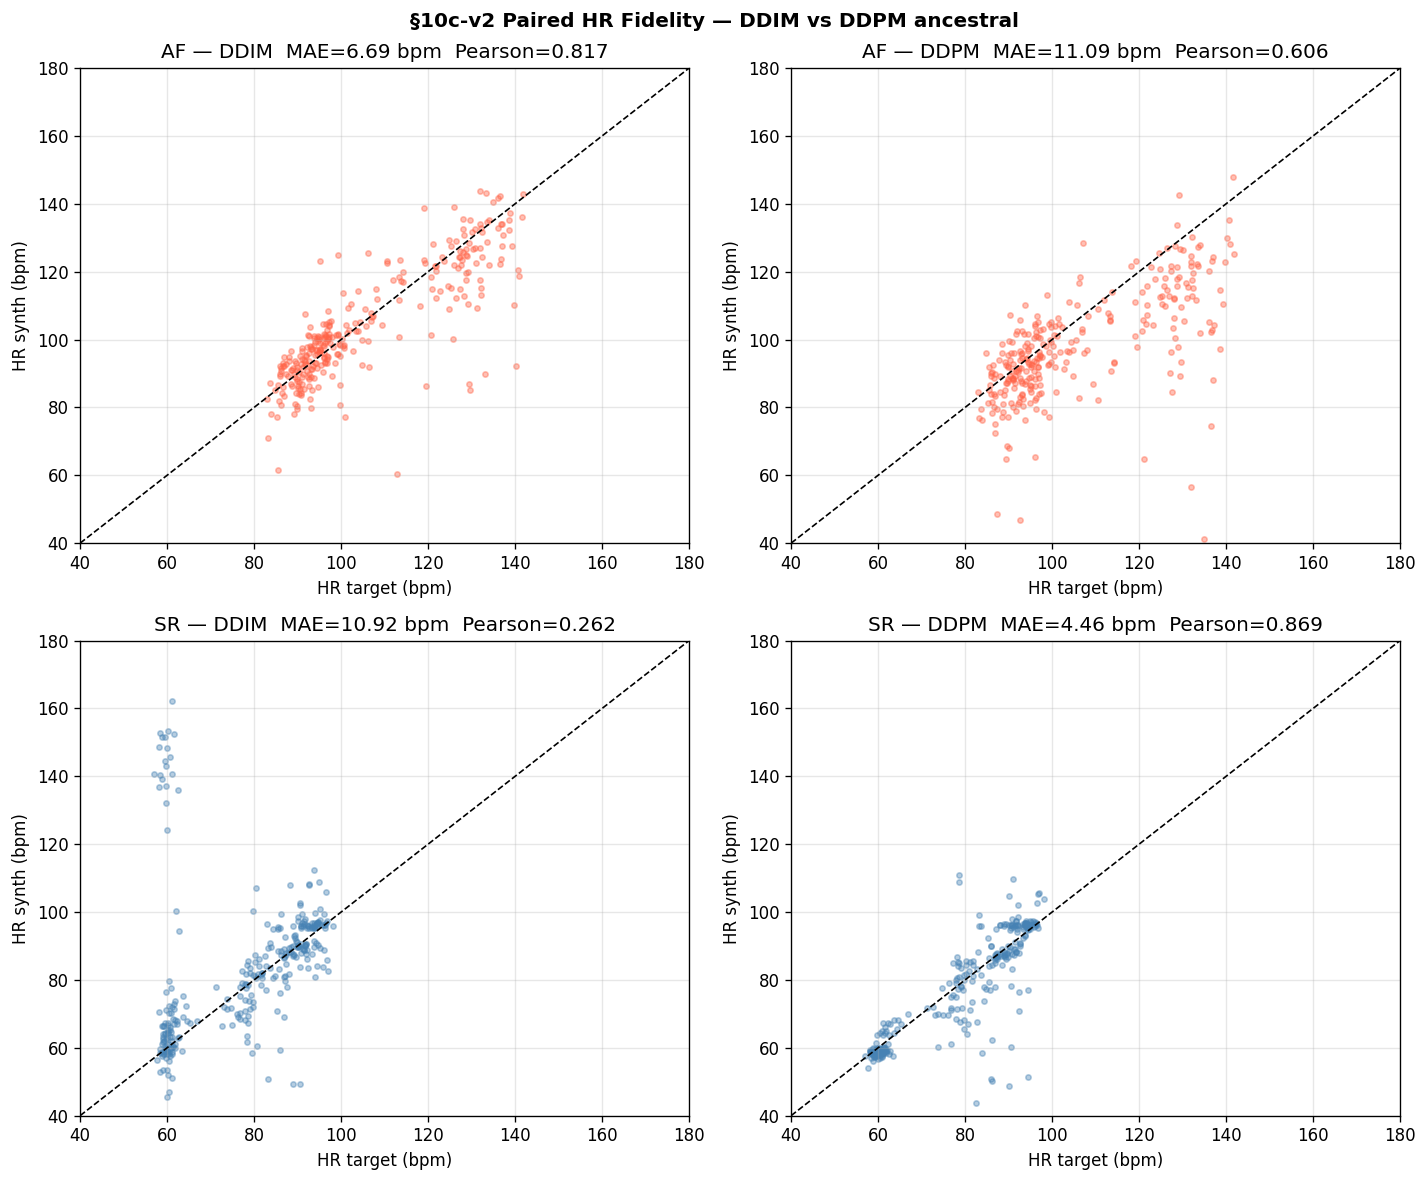

In [32]:
# ── §10c-v2 — Conditioning Fidelity (Paired) — both samplers ────────────────
# Generates N_COND_EVAL paired synthetics per class for DDIM and DDPM ancestral.
# Removes sample-misalignment artefact: each row's conditioning vector is used
# to generate exactly one synthetic, then MAE HR and IBI_std ratio are computed
# per pair before averaging.
#
# DDIM (100 steps): ~2 min/class   DDPM ancestral (T=1000): ~6 min/class

N_COND_EVAL = 300; MIN_IBI_STD = 0.01


def _est_hr_ibi(signals, fs=FS):
    hrs = np.full(len(signals), np.nan); ibi_stds = np.full(len(signals), np.nan)
    for i, sig in enumerate(signals):
        try:
            peaks, _ = _find_peaks(sig, distance=int(fs*0.3), height=0.05)
            ibi = np.diff(peaks)/fs; ibi = ibi[(ibi>=IBI_MIN)&(ibi<=IBI_MAX)]
            if len(ibi) >= 2:
                hrs[i] = 60./ibi.mean(); ibi_stds[i] = float(ibi.std())
        except: pass
    return hrs, ibi_stds

cond_paired_both = {}
_SAMPLERS = [
    ('DDIM',  DDIM_STEPS, BEST_GS_DDIM, False),
    ('DDPM',  None,       BEST_GS_DDPM, True ),   # True → ancestral
]

for rh in ['AF', 'SR']:
    df_rh = (df_test[df_test.event_rhythm==rh]
             .sample(min(N_COND_EVAL, len(df_test[df_test.event_rhythm==rh])),
                     random_state=SEED).reset_index(drop=True))
    hr_tgt = 60./df_rh['IBI_mean'].values; ibi_std_tgt = df_rh['IBI_std'].values
    nm, ns, nr = norm_ibi(df_rh.IBI_mean.values, df_rh.IBI_std.values, df_rh.RMSSD.values)
    cond_t = torch.tensor(build_cond(nm, ns, nr, rh), dtype=torch.float32).to(DEVICE)
    cond_paired_both[rh] = {}

    for sname, steps, gs, use_ancestral in _SAMPLERS:
        print(f'  Generating {len(cond_t)} paired {sname} synthetics for {rh}...')
        torch.cuda.empty_cache(); chunks = []
        for i in range(0, len(cond_t), 64):
            c = cond_t[i:i+64]
            if use_ancestral:
                out = ddpm_sample(ema_model, (c.size(0),1,WIN_LEN), c,
                                   diff_schedule, guidance_scale=gs)
            else:
                out = ddim_sample(ema_model, (c.size(0),1,WIN_LEN), c,
                                   diff_schedule, steps=steps, guidance_scale=gs)
            chunks.append(out.cpu().numpy().squeeze(1))
        synth_p = np.concatenate(chunks); n = len(df_rh)
        hrs_s, ibi_stds_s = _est_hr_ibi(synth_p); valid = ~np.isnan(hrs_s)
        mae_hr = float(np.nanmean(np.abs(hrs_s - hr_tgt))) # hr_tgt is array here
        ratio_mask = (ibi_std_tgt >= MIN_IBI_STD) & ~np.isnan(ibi_stds_s)
        ratio_m = float((ibi_stds_s[ratio_mask]/ibi_std_tgt[ratio_mask]).mean()) if ratio_mask.sum()>=5 else float('nan')
        n_ratio = int(ratio_mask.sum())
        valid_both = valid & (ibi_std_tgt > 0)
        pcc = (float(np.corrcoef(hr_tgt[valid_both], hrs_s[valid_both])[0,1])
               if valid_both.sum() >= 5 else float('nan'))
        cond_paired_both[rh][sname] = dict(
            hr_tgt_mean=hr_tgt.mean(), # Renamed to avoid keyword argument repeated error
            hr_syn=float(np.nanmean(hrs_s)),
            mae_hr=mae_hr, ibi_std_tgt=ibi_std_tgt.mean(),
            ibi_std_syn=float(np.nanmean(ibi_stds_s)),
            ratio_m=ratio_m, n_ratio=n_ratio, pcc=pcc,
            valid_pct=100*valid.sum()/n, hrs_s=hrs_s, hr_tgt=hr_tgt) # hr_tgt stores the array for plotting
        print(f'    {sname} {rh}: MAE={mae_hr:.2f} bpm  IBI_std ratio={ratio_m:.3f}'
              f'  Pearson={pcc:.3f}  detect={100*valid.sum()/n:.1f}%')

# ── Results table ─────────────────────────────────────────────────────────────
print()
print('='*78)
print('  §10c-v2 — Paired Conditioning Fidelity (both samplers)')
print('='*78)
print(f"  {'Metric':<34}  {'AF DDIM':>12}  {'AF DDPM':>12}  {'SR DDIM':>12}  {'SR DDPM':>12}")
print('  '+'─'*74)
for label, key in [('HR target (bpm)','hr_tgt_mean'), # Changed key here
                    ('HR synthetic (bpm)','hr_syn'),
                    ('MAE HR paired (bpm)','mae_hr'),('IBI_std target (s)','ibi_std_tgt'),
                    ('IBI_std synthetic (s)','ibi_std_syn'),('IBI_std ratio','ratio_m'),
                    ('Pearson HR','pcc'),('Peak detect (%)','valid_pct')]:
    vals = [cond_paired_both[rh][sn][key]
            for rh in ['AF','SR'] for sn in ['DDIM','DDPM']]
    print(f"  {label:<34}  {'  '.join(f'{v:>12.4f}' for v in vals)}")
print('='*78)
print(f'  IBI_std ratio: excl. IBI_std<{MIN_IBI_STD}s  '
      f'(AF DDIM n={cond_paired_both["AF"]["DDIM"]["n_ratio"]}  '
      f'AF DDPM n={cond_paired_both["AF"]["DDPM"]["n_ratio"]}  '
      f'SR DDIM n={cond_paired_both["SR"]["DDIM"]["n_ratio"]}  '
      f'SR DDPM n={cond_paired_both["SR"]["DDPM"]["n_ratio"]})')

# ── Scatter HR target vs HR synthetic (2×2) ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ri, rh in enumerate(['AF', 'SR']):
    for ci, sname in enumerate(['DDIM', 'DDPM']):
        r = cond_paired_both[rh][sname]
        valid = ~np.isnan(r['hrs_s'])
        lims = (40, 180)
        axes[ri,ci].scatter(r['hr_tgt'][valid], r['hrs_s'][valid],
                            s=10, alpha=0.4,
                            c='tomato' if rh=='AF' else 'steelblue')
        axes[ri,ci].plot(lims, lims, 'k--', lw=1)
        axes[ri,ci].set_xlim(lims); axes[ri,ci].set_ylim(lims)
        axes[ri,ci].set_xlabel('HR target (bpm)'); axes[ri,ci].set_ylabel('HR synth (bpm)')
        axes[ri,ci].set_title(f'{rh} — {sname}  MAE={r["mae_hr"]:.2f} bpm  Pearson={r["pcc"]:.3f}')
        axes[ri,ci].grid(alpha=0.3)
plt.suptitle('§10c-v2 Paired HR Fidelity — DDIM vs DDPM ancestral', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/fig_cond_paired_both.png', dpi=150); plt.show()



## §11 — Functional Validation (Clf1D)
Five conditions: TRTR · TSTR-DDPM · TSTR-DDIM · ClfB-DDPM · ClfB-DDIM.
5 seeds each, optimal val-set threshold.

In [33]:
class Clf1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(
            nn.Conv1d(1,32,15,stride=2,padding=7), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32,64,9,stride=2,padding=4),  nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64,128,7,stride=2,padding=3), nn.BatchNorm1d(128),nn.ReLU(),
            nn.Conv1d(128,256,5,stride=4,padding=2),nn.BatchNorm1d(256),nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),nn.Flatten(),
            nn.Linear(256,64),nn.ReLU(),nn.Dropout(0.3),nn.Linear(64,1))
    def forward(self,x): return self.net(x).squeeze(1)

def find_best_threshold(y_true,probs,ths=None):
    if ths is None: ths=np.linspace(0.01,0.99,99)
    f1s=[f1_score(y_true,(probs>t).astype(int),zero_division=0) for t in ths]
    return float(ths[np.argmax(f1s)]),float(np.max(f1s))

def train_clf(Xtr,ytr,Xvl,yvl,epochs=30,lr=1e-3,batch=128):
    clf=Clf1D().to(DEVICE)
    opt=torch.optim.Adam(clf.parameters(),lr=lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=epochs)
    pw=torch.tensor([len(ytr[ytr==0])/len(ytr[ytr==1])],dtype=torch.float32).to(DEVICE)
    crit=nn.BCEWithLogitsLoss(pos_weight=pw)
    Xt=torch.tensor(Xtr[:,None,:],dtype=torch.float32)
    yt=torch.tensor(ytr,dtype=torch.float32)
    Xv=torch.tensor(Xvl[:,None,:],dtype=torch.float32)
    dl=DataLoader(list(zip(Xt,yt)),batch_size=batch,shuffle=True)
    best_auc,best_st=0.,None
    for ep in range(epochs):
        clf.train()
        for xb,yb in dl:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE)
            opt.zero_grad(); crit(clf(xb),yb).backward(); opt.step()
        sch.step(); clf.eval()
        with torch.no_grad():
            lg=clf(Xv.to(DEVICE)).cpu().numpy()
        auc=roc_auc_score(yvl,lg)
        if auc>best_auc: best_auc=auc; best_st={k:v.clone() for k,v in clf.state_dict().items()}
    clf.load_state_dict(best_st); clf.eval()
    with torch.no_grad():
        vl=1/(1+np.exp(-clf(Xv.to(DEVICE)).cpu().numpy()))
    best_thr,_=find_best_threshold(yvl,vl)
    return clf,best_thr

def eval_clf(clf,Xte,yte,threshold=0.5):
    clf.eval()
    with torch.no_grad():
        lg=clf(torch.tensor(Xte[:,None,:],dtype=torch.float32).to(DEVICE)).cpu().numpy()
    probs=1/(1+np.exp(-lg)); preds=(probs>threshold).astype(int)
    return {'auroc':roc_auc_score(yte,lg),
            'precision':precision_score(yte,preds,zero_division=0),
            'f1':f1_score(yte,preds,zero_division=0)}

def load_fold(df_fold,max_per_class=None):
    signals,labels=[],[]
    for rh,lbl in [('AF',1),('SR',0)]:
        sub=df_fold[df_fold.event_rhythm==rh]
        if max_per_class: sub=sub.sample(min(max_per_class,len(sub)),random_state=SEED)
        for _,row in sub.iterrows():
            sig=load_ppg(row['csv_path'],int(row['start_sample']))
            if sig is not None: signals.append(sig); labels.append(lbl)
    return np.array(signals),np.array(labels)

print('Loading real signals...')
X_tr,y_tr=load_fold(df_train,max_per_class=1000)
X_vl,y_vl=load_fold(df_val)
X_te,y_te=load_fold(df_test)
print(f'Train: {X_tr.shape} | Val: {X_vl.shape} | Test: {X_te.shape}')


Loading real signals...
Train: (1986, 1250) | Val: (1195, 1250) | Test: (1260, 1250)


In [34]:
N_SYN=1000
print(f'Generating {N_SYN}/class synthetics (DDPM ancestral + DDIM, GS={BEST_GS_DDIM})...')
synth_tr={'ddpm':{},'ddim':{}}
gen_time={'ddpm':0.,'ddim':0.}
for rh in ['AF','SR']:
    df_cls=df_train[df_train.event_rhythm==rh].sample(
        min(N_SYN,len(df_train[df_train.event_rhythm==rh])),random_state=SEED)
    nm,ns,nr=norm_ibi(df_cls.IBI_mean.values,df_cls.IBI_std.values,df_cls.RMSSD.values)
    cond=torch.tensor(build_cond(nm,ns,nr,rh),dtype=torch.float32).to(DEVICE)
    t0=time.time()
    out=[]
    for i in range(0,len(cond),64):
        c=cond[i:i+64]
        out.append(ddpm_sample(ema_model,(c.size(0),1,WIN_LEN),c,
                               diff_schedule,guidance_scale=BEST_GS_DDIM).cpu().numpy())
    synth_tr['ddpm'][rh]=np.concatenate(out).squeeze(1)
    gen_time['ddpm']+=time.time()-t0
    print(f'  {rh} (ddpm): {synth_tr["ddpm"][rh].shape[0]}  [{gen_time["ddpm"]/60:.1f} min]')
    t0=time.time()
    out=[]
    for i in range(0,len(cond),64):
        c=cond[i:i+64]
        out.append(ddim_sample(ema_model,(c.size(0),1,WIN_LEN),c,
                               diff_schedule,steps=DDIM_STEPS,
                               guidance_scale=BEST_GS_DDIM).cpu().numpy())
    synth_tr['ddim'][rh]=np.concatenate(out).squeeze(1)
    gen_time['ddim']+=time.time()-t0
    print(f'  {rh} (ddim): {synth_tr["ddim"][rh].shape[0]}  [{gen_time["ddim"]/60:.1f} min]')

print(f'Gen time: DDPM ancestral={gen_time["ddpm"]/60:.1f} min  '
      f'DDIM={gen_time["ddim"]/60:.1f} min  speedup x{gen_time["ddpm"]/gen_time["ddim"]:.1f}')
X_syn={k:np.concatenate([synth_tr[k]['AF'],synth_tr[k]['SR']]) for k in ['ddpm','ddim']}
y_syn={k:np.array([1]*len(synth_tr[k]['AF'])+[0]*len(synth_tr[k]['SR'])) for k in ['ddpm','ddim']}


Generating 1000/class synthetics (DDPM ancestral + DDIM, GS=2.5)...
  AF (ddpm): 1000  [31.9 min]
  AF (ddim): 1000  [3.2 min]
  SR (ddpm): 1000  [63.8 min]
  SR (ddim): 1000  [6.4 min]
Gen time: DDPM ancestral=63.8 min  DDIM=6.4 min  speedup x10.0


In [35]:
N_SEEDS=5; results={}
conditions=[('TRTR',X_tr,y_tr),
             ('TSTR-DDPM',X_syn['ddpm'],y_syn['ddpm']),
             ('TSTR-DDIM',X_syn['ddim'],y_syn['ddim']),
             ('ClfB-DDPM',np.vstack([X_tr,X_syn['ddpm']]),np.concatenate([y_tr,y_syn['ddpm']])),
             ('ClfB-DDIM',np.vstack([X_tr,X_syn['ddim']]),np.concatenate([y_tr,y_syn['ddim']]))]

for cond_name,Xtr_c,ytr_c in conditions:
    print(f'\n{cond_name} \u2014 {N_SEEDS} seeds...')
    ml={'auroc':[],'precision':[],'f1':[],'threshold':[]}
    for s in range(N_SEEDS):
        torch.manual_seed(s); np.random.seed(s)
        clf,thr=train_clf(Xtr_c,ytr_c,X_vl,y_vl)
        m=eval_clf(clf,X_te,y_te,threshold=thr)
        m['threshold']=thr
        for k in ml: ml[k].append(m[k])
        print(f'  seed {s}: thr={thr:.2f}  AUROC={m["auroc"]:.4f}  F1={m["f1"]:.4f}')
    results[cond_name]={k:(np.mean(v),np.std(v)) for k,v in ml.items()}
    r=results[cond_name]
    print(f'  -> AUROC={r["auroc"][0]:.4f}\u00b1{r["auroc"][1]:.4f}  F1={r["f1"][0]:.4f}')

trtr_auroc=results['TRTR']['auroc'][0]
print()
print('='*100)
print('  Functional Evaluation Summary  (optimal val-set threshold, 5 seeds)')
print('='*100)
print(f"{'Condition':<12}  {'AUROC':>16}  {'Precision':>16}  {'F1':>16}  {'Gap vs TRTR':>12}")
print('-'*80)
for cn,m in results.items():
    gap=trtr_auroc-m['auroc'][0]
    print(f"{cn:<12}  {m['auroc'][0]:.4f}\u00b1{m['auroc'][1]:.4f}  "
          f"{m['precision'][0]:.4f}\u00b1{m['precision'][1]:.4f}  "
          f"{m['f1'][0]:.4f}\u00b1{m['f1'][1]:.4f}  {gap:>+.4f}")
print('='*100)



TRTR — 5 seeds...
  seed 0: thr=0.86  AUROC=0.7451  F1=0.7520
  seed 1: thr=0.22  AUROC=0.3345  F1=0.5414
  seed 2: thr=0.81  AUROC=0.5093  F1=0.6784
  seed 3: thr=0.16  AUROC=0.3671  F1=0.5959
  seed 4: thr=0.74  AUROC=0.4774  F1=0.6916
  -> AUROC=0.4867±0.1448  F1=0.6519

TSTR-DDPM — 5 seeds...
  seed 0: thr=0.81  AUROC=0.4707  F1=0.7097
  seed 1: thr=0.99  AUROC=0.3299  F1=0.6309
  seed 2: thr=0.65  AUROC=0.4911  F1=0.6890
  seed 3: thr=0.58  AUROC=0.5870  F1=0.6700
  seed 4: thr=0.49  AUROC=0.4784  F1=0.6863
  -> AUROC=0.4714±0.0823  F1=0.6772

TSTR-DDIM — 5 seeds...
  seed 0: thr=0.99  AUROC=0.2965  F1=0.4723
  seed 1: thr=0.15  AUROC=0.3100  F1=0.6140
  seed 2: thr=0.75  AUROC=0.2845  F1=0.5331
  seed 3: thr=0.03  AUROC=0.2989  F1=0.5231
  seed 4: thr=0.79  AUROC=0.2725  F1=0.4413
  -> AUROC=0.2925±0.0129  F1=0.5168

ClfB-DDPM — 5 seeds...
  seed 0: thr=0.13  AUROC=0.4049  F1=0.6840
  seed 1: thr=0.98  AUROC=0.6240  F1=0.7116
  seed 2: thr=0.11  AUROC=0.4436  F1=0.6444
  seed 3:

## Synthetic Pool Generation (DDIM)
Generates a large DDIM pool used for the data-scarcity experiments and FV2.
Uses DDIM for efficiency; quality is comparable to ancestral (see §11 TSTR comparison).

In [36]:
N_POOL=3200
print(f'Generating DDIM synthetic pool: {N_POOL}/class...')
synth_pool_ddim={'AF':[],'SR':[]}
for rh in ['AF','SR']:
    df_cls=df_train[df_train.event_rhythm==rh].sample(
        min(N_POOL,len(df_train[df_train.event_rhythm==rh])),random_state=SEED+1)
    nm,ns,nr=norm_ibi(df_cls.IBI_mean.values,df_cls.IBI_std.values,df_cls.RMSSD.values)
    cond=torch.tensor(build_cond(nm,ns,nr,rh),dtype=torch.float32).to(DEVICE)
    chunks=[]
    for i in range(0,len(cond),64):
        c=cond[i:i+64]
        chunks.append(ddim_sample(ema_model,(c.size(0),1,WIN_LEN),c,
                                  diff_schedule,steps=DDIM_STEPS,
                                  guidance_scale=BEST_GS_DDIM).cpu().numpy())
    synth_pool_ddim[rh]=np.concatenate(chunks).squeeze(1).astype(np.float32)
    print(f'  {rh}: {synth_pool_ddim[rh].shape[0]} windows')

# Alias for data-scarcity cells
synth_pool_m3=synth_pool_ddim
print(f'Pool: AF={len(synth_pool_ddim["AF"])} SR={len(synth_pool_ddim["SR"])}')


Generating DDIM synthetic pool: 3200/class...
  AF: 3103 windows
  SR: 2384 windows
Pool: AF=3103 SR=2384


In [37]:
class ClfUNetGAN(nn.Module):
    def __init__(self):
        super().__init__()
        filters=[1,4,8,16,32,64,128]; layers=[]
        for i in range(len(filters)-1):
            layers+=[nn.Conv1d(filters[i],filters[i+1],kernel_size=3,padding=1),
                     nn.LeakyReLU(0.15)]
        layers+=[nn.AdaptiveAvgPool1d(1),nn.Flatten()]
        self.features=nn.Sequential(*layers)
        self.classifier=nn.Linear(128,2)
    def forward(self,x): return self.classifier(self.features(x))

def train_clf_ug(Xtr,ytr,Xvl,yvl,epochs=30,lr=1e-3,batch=128):
    clf=ClfUNetGAN().to(DEVICE)
    opt=torch.optim.Adam(clf.parameters(),lr=lr)
    Xt=torch.tensor(Xtr[:,None,:],dtype=torch.float32)
    yt=torch.tensor(ytr,dtype=torch.long)
    Xv=torch.tensor(Xvl[:,None,:],dtype=torch.float32)
    dl=DataLoader(list(zip(Xt,yt)),batch_size=batch,shuffle=True)
    best_a,best_st=0.,None
    for ep in range(epochs):
        clf.train()
        for xb,yb in dl:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE)
            opt.zero_grad(); nn.CrossEntropyLoss()(clf(xb),yb).backward(); opt.step()
        clf.eval()
        with torch.no_grad():
            pr=torch.softmax(clf(Xv.to(DEVICE)),dim=1).cpu().numpy()[:,1]
        a=roc_auc_score(yvl,pr)
        if a>best_a: best_a=a; best_st={k:v.clone() for k,v in clf.state_dict().items()}
    clf.load_state_dict(best_st); clf.eval()
    with torch.no_grad():
        pr_v=torch.softmax(clf(Xv.to(DEVICE)),dim=1).cpu().numpy()[:,1]
    thr,_=find_best_threshold(yvl,pr_v)
    return clf,thr

def eval_clf_ug(clf,Xte,yte,threshold=0.5):
    clf.eval()
    with torch.no_grad():
        pr=torch.softmax(clf(torch.tensor(
            Xte[:,None,:],dtype=torch.float32).to(DEVICE)),dim=1).cpu().numpy()[:,1]
    preds=(pr>threshold).astype(int)
    return {'auroc':roc_auc_score(yte,pr),
            'precision':precision_score(yte,preds,zero_division=0),
            'f1':f1_score(yte,preds,zero_division=0)}

print('ClfUNetGAN helpers defined.')

ClfUNetGAN helpers defined.


---
##  FV2: ClfUNetGAN (D1–D5)

Same experimental design as the FV2 in the OT-CFM B2 notebook, now with DDIM synthetics.
Datasets D1–D5 vary the real/synthetic mix to isolate the contribution of each type.

| Dataset | Training data | Aim |
|---------|---------------|-----|
| D1 | 50% synth AF + 50% real SR | Can synthetics replace real AF? |
| D2 | 25% synth AF + 25% real AF + 50% real SR | Hybrid augmentation |
| D3 | 50% real AF + 50% synth SR | Can synthetics replace real SR? |
| D4 | 50% real AF + 50% real SR | Baseline (all real) |
| D5 | 75% real AF + 25% real SR | Class-imbalanced real baseline |

In [38]:
# ── Real signal pools from train split ───────────────────────────────────────
N_POOL_CLF=len(synth_pool_ddim['AF'])
N_UNIT=min(len(synth_pool_ddim['AF']),len(synth_pool_ddim['SR']),
           int((y_tr==1).sum()),int((y_tr==0).sum()))
print(f'Balancing unit N = {N_UNIT} segments per class')

rng_fv2=np.random.default_rng(SEED+200)
def sample_n(arr,n,rng):
    idx=rng.choice(len(arr),min(n,len(arr)),replace=False)
    return arr[idx]

real_af=X_tr[y_tr==1]; real_sr=X_tr[y_tr==0]
syn_af=synth_pool_ddim['AF']; syn_sr=synth_pool_ddim['SR']

# D1: 50% synth AF + 50% real SR
d1_X=np.vstack([sample_n(syn_af,N_UNIT,rng_fv2),sample_n(real_sr,N_UNIT,rng_fv2)])
d1_y=np.array([1]*N_UNIT+[0]*N_UNIT)
# D2: 25% synth AF + 25% real AF + 50% real SR
N2=N_UNIT//2
d2_X=np.vstack([sample_n(syn_af,N2,rng_fv2),sample_n(real_af,N2,rng_fv2),
                sample_n(real_sr,N_UNIT,rng_fv2)])
d2_y=np.array([1]*N2+[1]*N2+[0]*N_UNIT)
# D3: 50% real AF + 50% synth SR
d3_X=np.vstack([sample_n(real_af,N_UNIT,rng_fv2),sample_n(syn_sr,N_UNIT,rng_fv2)])
d3_y=np.array([1]*N_UNIT+[0]*N_UNIT)
# D4: 50% real AF + 50% real SR (baseline)
d4_X=np.vstack([sample_n(real_af,N_UNIT,rng_fv2),sample_n(real_sr,N_UNIT,rng_fv2)])
d4_y=np.array([1]*N_UNIT+[0]*N_UNIT)
# D5: 75% real AF + 25% real SR (imbalanced)
N5_af=min(int(N_UNIT*1.5),len(real_af)); N5_sr=N_UNIT//2
d5_X=np.vstack([sample_n(real_af,N5_af,rng_fv2),sample_n(real_sr,N5_sr,rng_fv2)])
d5_y=np.array([1]*N5_af+[0]*N5_sr)

datasets_fv2=[
    ('D1 \u2014 50% synth AF + 50% real SR',        d1_X,d1_y),
    ('D2 \u2014 25% synth AF + 25% real AF + 50% SR', d2_X,d2_y),
    ('D3 \u2014 50% real AF + 50% synth SR',         d3_X,d3_y),
    ('D4 \u2014 50% real AF + 50% real SR (baseline)',d4_X,d4_y),
    ('D5 \u2014 75% real AF + 25% real SR (imbal.)', d5_X,d5_y),
]
print('Dataset sizes:')
for name,X,y in datasets_fv2:
    print(f'  {name}: {len(X)} segs (AF={int((y==1).sum())}, SR={int((y==0).sum())})')


Balancing unit N = 989 segments per class
Dataset sizes:
  D1 — 50% synth AF + 50% real SR: 1978 segs (AF=989, SR=989)
  D2 — 25% synth AF + 25% real AF + 50% SR: 1977 segs (AF=988, SR=989)
  D3 — 50% real AF + 50% synth SR: 1978 segs (AF=989, SR=989)
  D4 — 50% real AF + 50% real SR (baseline): 1978 segs (AF=989, SR=989)
  D5 — 75% real AF + 25% real SR (imbal.): 1483 segs (AF=989, SR=494)


In [39]:
# ClfUNetGAN validation set from §12a
X_vl_g=X_vl; y_vl_g=y_vl; X_te_g=X_te; y_te_g=y_te

N_SEEDS_FV2=5; results_fv2={}
print(f'Training ClfUNetGAN on each dataset ({N_SEEDS_FV2} seeds)...')
print('='*70)

for ds_name,Xtr_d,ytr_d in datasets_fv2:
    print(f'\n{ds_name}')
    ml={'accuracy':[],'auroc':[],'precision':[],'recall':[],'specificity':[],'f1':[],'threshold':[]}
    for s in range(N_SEEDS_FV2):
        torch.manual_seed(s); np.random.seed(s)
        clf,thr=train_clf_ug(Xtr_d,ytr_d,X_vl_g,y_vl_g)
        clf.eval()
        with torch.no_grad():
            pr=torch.softmax(clf(torch.tensor(
                X_te_g[:,None,:],dtype=torch.float32).to(DEVICE)),dim=1).cpu().numpy()[:,1]
        preds=(pr>thr).astype(int)
        tn,fp,fn,tp=confusion_matrix(y_te_g,preds).ravel()
        ml['accuracy'].append(accuracy_score(y_te_g,preds))
        ml['auroc'].append(roc_auc_score(y_te_g,pr))
        ml['precision'].append(precision_score(y_te_g,preds,zero_division=0))
        ml['recall'].append(recall_score(y_te_g,preds,zero_division=0))
        ml['specificity'].append(tn/(tn+fp) if (tn+fp)>0 else 0.)
        ml['f1'].append(f1_score(y_te_g,preds,zero_division=0))
        ml['threshold'].append(thr)
        print(f'  seed {s}: Acc={ml["accuracy"][-1]:.4f}  '
              f'AUROC={ml["auroc"][-1]:.4f}  F1={ml["f1"][-1]:.4f}  thr={thr:.2f}')
    results_fv2[ds_name]={k:(float(np.mean(v)),float(np.std(v))) for k,v in ml.items()}
    r=results_fv2[ds_name]
    print(f'  -> AUROC={r["auroc"][0]:.4f}\u00b1{r["auroc"][1]:.4f}  F1={r["f1"][0]:.4f}\u00b1{r["f1"][1]:.4f}')

print()
print('='*110)
print('  Functional Validation 2 \u2014 ClfUNetGAN (DDIM synthetics, 5 seeds, optimal val threshold)')
print('='*110)
print(f"  {'Dataset':<46}  {'Accuracy':>13}  {'AUROC':>13}  {'Prec':>10}  "
      f"{'Recall':>10}  {'Spec':>10}  {'F1':>10}")
print('  '+'\u2500'*104)
for ds_name,r in results_fv2.items():
    print(f"  {ds_name:<46}  "
          f"{r['accuracy'][0]:.4f}\u00b1{r['accuracy'][1]:.3f}  "
          f"{r['auroc'][0]:.4f}\u00b1{r['auroc'][1]:.3f}  "
          f"{r['precision'][0]:.4f}\u00b1{r['precision'][1]:.3f}  "
          f"{r['recall'][0]:.4f}\u00b1{r['recall'][1]:.3f}  "
          f"{r['specificity'][0]:.4f}\u00b1{r['specificity'][1]:.3f}  "
          f"{r['f1'][0]:.4f}\u00b1{r['f1'][1]:.3f}")
print('='*110)


Training ClfUNetGAN on each dataset (5 seeds)...

D1 — 50% synth AF + 50% real SR
  seed 0: Acc=0.5429  AUROC=0.7465  F1=0.7037  thr=0.01
  seed 1: Acc=0.5429  AUROC=0.7488  F1=0.7037  thr=0.01
  seed 2: Acc=0.5429  AUROC=0.7453  F1=0.7037  thr=0.01
  seed 3: Acc=0.5429  AUROC=0.7432  F1=0.7037  thr=0.01
  seed 4: Acc=0.5675  AUROC=0.6908  F1=0.7151  thr=0.28
  -> AUROC=0.7349±0.0221  F1=0.7060±0.0046

D2 — 25% synth AF + 25% real AF + 50% SR
  seed 0: Acc=0.7095  AUROC=0.7029  F1=0.7857  thr=0.26
  seed 1: Acc=0.5429  AUROC=0.5143  F1=0.7037  thr=0.01
  seed 2: Acc=0.6698  AUROC=0.7131  F1=0.7658  thr=0.26
  seed 3: Acc=0.6881  AUROC=0.7071  F1=0.7737  thr=0.29
  seed 4: Acc=0.7079  AUROC=0.7010  F1=0.7817  thr=0.31
  -> AUROC=0.6677±0.0768  F1=0.7621±0.0300

D3 — 50% real AF + 50% synth SR
  seed 0: Acc=0.5429  AUROC=0.3073  F1=0.7037  thr=0.01
  seed 1: Acc=0.5429  AUROC=0.3447  F1=0.7037  thr=0.01
  seed 2: Acc=0.5429  AUROC=0.3287  F1=0.7037  thr=0.01
  seed 3: Acc=0.5429  AUROC=0

In [40]:
# ── Shared generation helper ─────────────────────────────────────────────────
# Generates synthetic windows using either DDIM or DDPM ancestral.
# Used in all cross-domain sections below.

def gen_synth(cond_np, sampler='ddim', n_max=None, seed=SEED):
    """
    cond_np: (N, RAW_COND_DIM) float32 conditioning array
    sampler: 'ddim' or 'ddpm'
    Returns: (N, WIN_LEN) float32 synthetic signals
    """
    rng = np.random.default_rng(seed)
    if n_max is not None and len(cond_np) > n_max:
        idx = rng.choice(len(cond_np), n_max, replace=False)
        cond_np = cond_np[idx]
    cond_t = torch.tensor(cond_np, dtype=torch.float32).to(DEVICE)
    chunks = []
    for i in range(0, len(cond_t), 64):
        c = cond_t[i:i+64]
        if sampler == 'ddpm':
            out = ddpm_sample(ema_model, (c.size(0),1,WIN_LEN), c,
                               diff_schedule, guidance_scale=BEST_GS_DDPM)
        else:
            out = ddim_sample(ema_model, (c.size(0),1,WIN_LEN), c,
                               diff_schedule, steps=DDIM_STEPS,
                               guidance_scale=BEST_GS_DDIM)
        chunks.append(out.cpu().numpy().squeeze(1))
        torch.cuda.empty_cache()
    return np.concatenate(chunks).astype(np.float32)


def samp(arr, n, rng):
    return arr[rng.choice(len(arr), min(n,len(arr)), replace=False)]


def fidelity_report(real, synth_dict, label_real, feats_real_af=None):
    """
    Print LSD, Wasserstein, MMD, DTW for each sampler in synth_dict.
    synth_dict: {'DDIM': array, 'DDPM': array}
    Returns dict of metrics for the table.
    """
    res = {}
    N_F = min(200, len(real))
    rng_f = np.random.default_rng(SEED)
    real_ev = real[rng_f.choice(len(real), N_F, replace=False)]
    feat_real = feature_vec(real_ev)
    for sname, synth in synth_dict.items():
        synth_ev = synth[rng_f.choice(len(synth), min(N_F,len(synth)), replace=False)]
        l = lsd(real_ev, synth_ev, band=(0.5,8.))
        feat_syn = feature_vec(synth_ev)
        wdists = [wasserstein_distance(feat_real[:,i],feat_syn[:,i]) for i in range(5)]
        mmd_v  = mmd_rbf(feat_real, feat_syn)
        dtw_v, _ = dtw_nn_summary(real_ev, synth_ev, n=30)
        res[sname] = dict(lsd=l, wd_mean=float(np.mean(wdists)),
                           mmd=mmd_v, dtw=dtw_v)
        print(f'  [{sname}]  LSD={l:.2f} dB  WD={np.mean(wdists):.4f}  '
              f'MMD²={mmd_v:.5f}  DTW={dtw_v:.3f}')
    # Domain gap baseline (vs MIMIC-AF real AF)
    if feats_real_af is not None:
        mmd_gap = mmd_rbf(feat_real, feats_real_af[:N_F])
        print(f'  [Domain gap: {label_real} vs MIMIC-AF real AF]  MMD²={mmd_gap:.5f}')
        for sname in synth_dict:
            res[sname]['mmd_gap'] = mmd_gap
    return res


#def dtw_nn_summary(real_sigs, synth_sigs, n=30, seed=SEED, down=5):
#    rng_ = np.random.default_rng(seed)
#    n = min(n, len(real_sigs), len(synth_sigs))
#    idx_r = rng_.choice(len(real_sigs),  n, replace=False)
#    idx_s = rng_.choice(len(synth_sigs), n, replace=False)
#    dists = [dtw_distance(real_sigs[i][::down],synth_sigs[j][::down])
#             for i,j in zip(idx_r,idx_s)]
#    return float(np.mean(dists)), float(np.std(dists))


# Verify feats from §10a are available
try: _ = feats
except NameError:
    print('WARNING: feats not in scope — run §10a first.')
print('Shared helpers defined (gen_synth, fidelity_report, samp, dtw_nn_summary).')


Shared helpers defined (gen_synth, fidelity_report, samp, dtw_nn_summary).


---
## §12 Part B — Cross-Domain: MIMIC-III-Ext-PPG

Generates synthetic AF PPG from MIMIC-III-Ext-PPG conditioning using the
MIMIC-AF DDPM model (both DDIM and ancestral).

**Prerequisites:** `ibi_session_3_380.csv` accessible at `IBI_SESSION_M3`,
and MIMIC-III WFDB files at the paths stored in that CSV.

- **B.1** Fidelity: LSD · Wasserstein · MMD · DTW · t-SNE (both samplers)
- **B.2** Classifier: ClfUNetGAN (DB1/DB2/DBref, DDIM pool, 2 test sets)

In [41]:
import subprocess, sys as _sys
try: import wfdb
except ImportError:
    subprocess.check_call([_sys.executable,'-m','pip','install','wfdb','-q'])
    import wfdb

IBI_SESSION_M3 = ('/kaggle/input/datasets/simaosoares4/ibi-values-b2/'
                  'ibi_session_3_380.csv')
N_B_GEN  = 2000   # max windows for generation
N_B_EVAL = 200    # windows for fidelity

real_m3  = np.zeros((0,WIN_LEN),dtype=np.float32)
cond_m3_np = np.zeros((0,RAW_COND_DIM),dtype=np.float32)
df_m3    = pd.DataFrame()

def _load_ppg_m3(wfdb_path, sub_win, fs=FS, win_len=WIN_LEN):
    start = int(sub_win)*win_len; end = start+win_len
    try:
        rec = wfdb.rdrecord(wfdb_path)
        if 'PLETH' not in rec.sig_name: return None
        sig = rec.p_signal[start:end, rec.sig_name.index('PLETH')].copy()
        if len(sig)<win_len or np.isnan(sig).any() or np.all(sig==sig[0]): return None
        nyq=fs/2; b,a=butter(4,[0.5/nyq,8./nyq],btype='band')
        sig=filtfilt(b,a,sig); mn,mx=sig.min(),sig.max()
        if mx-mn<1e-8: return None
        return (2*(sig-mn)/(mx-mn)-1).astype(np.float32)
    except: return None

if os.path.exists(IBI_SESSION_M3):
    df_m3 = pd.read_csv(IBI_SESSION_M3)
    df_m3 = df_m3.dropna(subset=['IBI_mean','IBI_std','RMSSD'])
    df_m3 = df_m3[(df_m3.IBI_mean>=IBI_MIN)&(df_m3.IBI_mean<=IBI_MAX)&
                   (df_m3.IBI_std>=0)&(df_m3.IBI_std<=0.5)].copy()
    df_m3_af = df_m3[df_m3.event_rhythm=='AF'].sample(
        min(N_B_GEN,len(df_m3[df_m3.event_rhythm=='AF'])),random_state=SEED)
    nm,ns,nr=norm_ibi(df_m3_af.IBI_mean.values,df_m3_af.IBI_std.values,df_m3_af.RMSSD.values)
    sign=np.full(len(nm),1.,dtype=np.float32)
    cond_m3_np=np.stack([nm,ns,nr,sign],axis=1)
    # Load real PPG
    _HAS_WFDB = 'wfdb_path' in df_m3_af.columns and 'sub_win' in df_m3_af.columns
    if _HAS_WFDB:
        print(f'Loading real MIMIC-III AF PPG ({len(df_m3_af)} windows)...')
        real_list=[]
        for _,row in df_m3_af.iterrows():
            sig=_load_ppg_m3(row['wfdb_path'],int(row['sub_win']))
            if sig is not None: real_list.append(sig)
        real_m3=np.array(real_list,dtype=np.float32)
        print(f'Loaded: {len(real_m3)} valid windows ({100*len(real_m3)/len(df_m3_af):.1f}%)')
    else:
        print('wfdb_path/sub_win not found — fidelity vs real PPG skipped.')
    print(f'Conditioning ready: {len(cond_m3_np)} windows')
else:
    print(f'Session file not found: {IBI_SESSION_M3}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.9 MB/s eta 0:00:00
Loading real MIMIC-III AF PPG (2000 windows)...
Loaded: 2000 valid windows (100.0%)
Conditioning ready: 2000 windows


In [42]:
# ── B2: Generate DDIM + DDPM ancestral from MIMIC-III conditioning ───────────
synth_m3 = {}
if len(cond_m3_np) > 0:
    for sname in ['DDIM', 'DDPM']:
        print(f'Generating {len(cond_m3_np)} MIMIC-III-conditioned [{sname}] synthetics...')
        synth_m3[sname] = gen_synth(cond_m3_np, sampler=sname.lower())
        print(f'  Done: {synth_m3[sname].shape}')
else:
    print('No M3 conditioning — skipping generation.')


Generating 2000 MIMIC-III-conditioned [DDIM] synthetics...
  Done: (2000, 1250)
Generating 2000 MIMIC-III-conditioned [DDPM] synthetics...
  Done: (2000, 1250)


Fidelity — MIMIC-III real AF vs generated:
  [DDIM]  LSD=6.79 dB  WD=1.9948  MMD²=0.02309  DTW=30.471
  [DDPM]  LSD=6.64 dB  WD=1.1364  MMD²=0.00791  DTW=32.631
  [Domain gap: MIMIC-III vs MIMIC-AF real AF]  MMD²=0.07319
Computing t-SNE (Part B)...


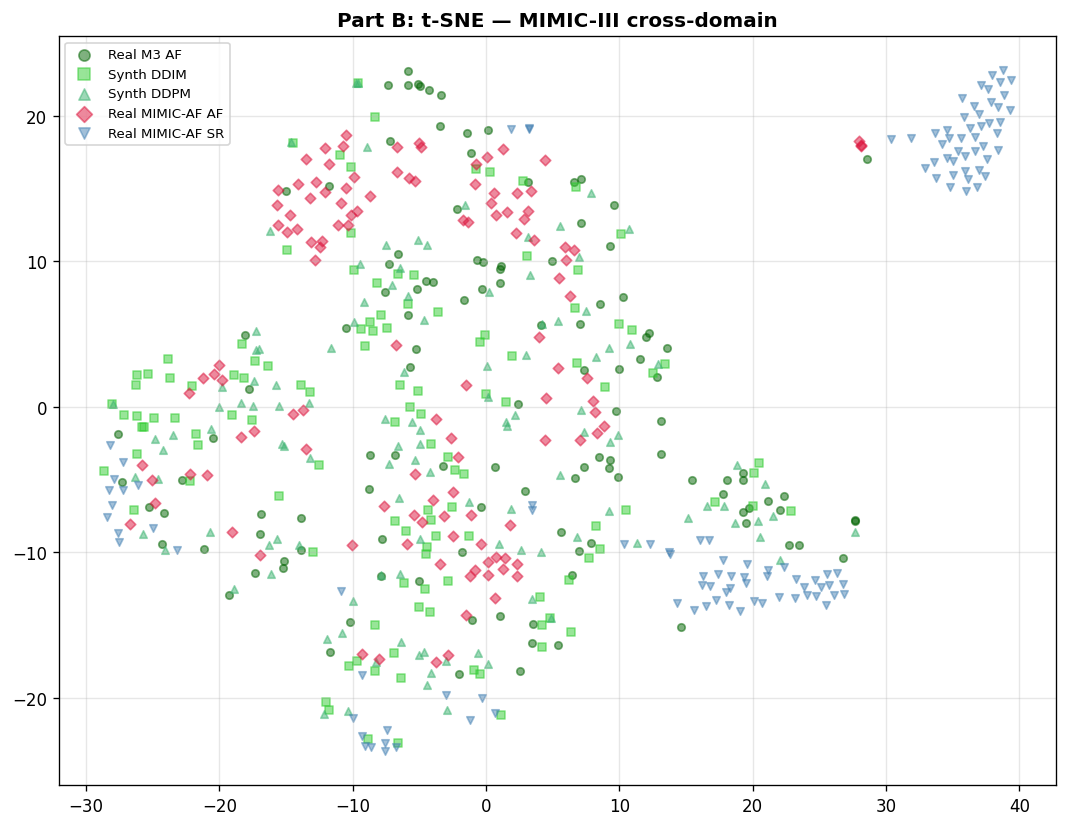


Fidelity summary (band LSD, 0.5–8 Hz):
  DDIM: LSD=6.79 dB  WD=1.9948  MMD²=0.02309  DTW=30.471  Gap closed=68.5%
  DDPM: LSD=6.64 dB  WD=1.1364  MMD²=0.00791  DTW=32.631  Gap closed=89.2%


In [46]:
# ── B3: Fidelity (both samplers) + t-SNE ─────────────────────────────────────
if len(real_m3) >= 20 and synth_m3:
    print('Fidelity — MIMIC-III real AF vs generated:')
    feat_m3_real = feature_vec(real_m3[:N_B_EVAL])
    fid_m3 = fidelity_report(real_m3, synth_m3, 'MIMIC-III',
                              feats_real_af=feats['real_AF'])

    # t-SNE (4-way: M3 real, DDIM synth, MIMIC-AF real AF, MIMIC-AF real SR)
    N_TT = min(120, len(real_m3), *[len(v) for v in synth_m3.values()],
               len(feats['real_AF']), len(feats['real_SR']))
    feat_s_ddim = feature_vec(synth_m3['DDIM'][:N_TT])
    feat_s_ddpm = feature_vec(synth_m3['DDPM'][:N_TT])
    all_f = np.concatenate([feat_m3_real[:N_TT], feat_s_ddim, feat_s_ddpm,
                             feats['real_AF'][:N_TT], feats['real_SR'][:N_TT]])
    all_l = (['Real M3 AF']*N_TT + ['Synth DDIM']*N_TT + ['Synth DDPM']*N_TT +
             ['Real MIMIC-AF AF']*N_TT + ['Real MIMIC-AF SR']*N_TT)
    sc_b = StandardScaler().fit(all_f)
    print('Computing t-SNE (Part B)...')
    emb_b = TSNE(n_components=2,perplexity=30,random_state=SEED,n_iter=1000
                 ).fit_transform(sc_b.transform(all_f))
    style_b = {'Real M3 AF':('darkgreen','o','real'),'Synth DDIM':('limegreen','s','ddim'),
               'Synth DDPM':('mediumseagreen','^','ddpm'),
               'Real MIMIC-AF AF':('crimson','D','real'),'Real MIMIC-AF SR':('steelblue','v','real')}
    fig,ax=plt.subplots(figsize=(9,7))
    for lbl,(col,mrk,_) in style_b.items():
        msk=[l==lbl for l in all_l]
        ax.scatter(emb_b[msk,0],emb_b[msk,1],c=col,marker=mrk,alpha=0.5,s=20,label=lbl)
    ax.set_title('Part B: t-SNE — MIMIC-III cross-domain',fontweight='bold')
    ax.legend(markerscale=1.5,fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    print(f'\nFidelity summary (band LSD, 0.5–8 Hz):')
    for sname,m in fid_m3.items():
        gap_pct=100*(1-m['mmd']/m.get('mmd_gap',float('nan'))) if m.get('mmd_gap',0)>0 else float('nan')
        print(f'  {sname}: LSD={m["lsd"]:.2f} dB  WD={m["wd_mean"]:.4f}  '
              f'MMD²={m["mmd"]:.5f}  DTW={m["dtw"]:.3f}  Gap closed={gap_pct:.1f}%')
elif synth_m3:
    print('No real M3 PPG — showing only feature stats of synthetics.')
    for sname,arr in synth_m3.items():
        print(f'  {sname}: {arr.shape}  range=[{arr.min():.2f},{arr.max():.2f}]')
else:
    print('No M3 data — Part B fidelity skipped.')


In [47]:
# ── B4: ClfUNetGAN — MIMIC-III-conditioned synthetics ────────────────────────
# Uses DDIM pool only for classifier (DDPM ancestral pool interchangeable)

if 'DDIM' in synth_m3 and len(synth_m3['DDIM']) >= 50:
    syn_m3 = synth_m3['DDIM']   # use DDIM pool for classifier
    N_DB = min(len(syn_m3),int((y_tr==1).sum()),int((y_tr==0).sum()))
    rng_db=np.random.default_rng(SEED+300)
    raf=X_tr[y_tr==1]; rsr=X_tr[y_tr==0]
    db1_X=np.vstack([samp(syn_m3,N_DB,rng_db),samp(rsr,N_DB,rng_db)])
    db1_y=np.array([1]*N_DB+[0]*N_DB)
    NHB=N_DB//2
    db2_X=np.vstack([samp(syn_m3,NHB,rng_db),samp(raf,NHB,rng_db),samp(rsr,N_DB,rng_db)])
    db2_y=np.array([1]*NHB+[1]*NHB+[0]*N_DB)
    dbr_X=np.vstack([samp(raf,N_DB,rng_db),samp(rsr,N_DB,rng_db)])
    dbr_y=np.array([1]*N_DB+[0]*N_DB)
    N_XD=min(len(real_m3),int((y_te==0).sum())) if len(real_m3)>0 else 0
    X_xdom_b=np.zeros((0,WIN_LEN),dtype=np.float32); y_xdom_b=np.array([])
    if N_XD>0:
        rng_xd=np.random.default_rng(SEED+301)
        X_xdom_b=np.vstack([real_m3[rng_xd.choice(len(real_m3),N_XD,replace=False)],
                             X_te[rng_xd.choice(np.where(y_te==0)[0],N_XD,replace=False)]])
        y_xdom_b=np.array([1]*N_XD+[0]*N_XD)
    N_SEEDS_B=5; res_b_mimic,res_b_xdom={},{}
    for ds_name,Xtr_d,ytr_d in [
            ('DB1 — M3-synth AF + MIMIC-AF SR',db1_X,db1_y),
            ('DB2 — M3-synth+real AF + SR (hybrid)',db2_X,db2_y),
            ('DBref — Real MIMIC-AF AF+SR',dbr_X,dbr_y)]:
        print(f'\n{ds_name}')
        ml_m={k:[] for k in ['auroc','precision','f1']}
        ml_x={k:[] for k in ['auroc','precision','f1']}
        for s in range(N_SEEDS_B):
            torch.manual_seed(s); np.random.seed(s)
            clf,thr=train_clf_ug(Xtr_d,ytr_d,X_vl,y_vl)
            clf.eval()
            for ml,(Xte_,yte_) in [(ml_m,(X_te,y_te)),(ml_x,(X_xdom_b,y_xdom_b))]:
                if len(Xte_)==0: continue
                m=eval_clf_ug(clf,Xte_,yte_,threshold=thr)
                for k in ml: ml[k].append(m[k])
            print(f'  seed {s}  [MIMIC-AF] AUROC={ml_m["auroc"][-1]:.4f}  '
                  f'Precision={ml_m["precision"][-1]:.4f}  F1={ml_m["f1"][-1]:.4f}  '
                  f'[XDom] AUROC={ml_x["auroc"][-1] if ml_x["auroc"] else float("nan"):.4f}')
        res_b_mimic[ds_name]={k:(float(np.mean(v)),float(np.std(v))) for k,v in ml_m.items()}
        res_b_xdom[ds_name] ={k:(float(np.mean(v)),float(np.std(v))) for k,v in ml_x.items() if v}
    print(f'\n{"="*95}')
    print(f'  Part B — ClfUNetGAN (DDIM pool, 5 seeds)')
    print(f'{"="*95}')
    for tname,rdict in [('[MIMIC-AF test]',res_b_mimic),
                         (f'[XDom: M3 AF+MIMIC-AF SR  N={N_XD}/class]',res_b_xdom)]:
        if not rdict: continue
        print(f'  ── {tname}')
        print(f"  {'Dataset':<40}  {'AUROC':>14}  {'Precision':>12}  {'F1':>10}")
        for n,m in rdict.items():
            if 'auroc' not in m: continue
            print(f"  {n:<40}  {m['auroc'][0]:.4f}\u00b1{m['auroc'][1]:.3f}  "
                  f"{m['precision'][0]:.4f}\u00b1{m['precision'][1]:.3f}  "
                  f"{m['f1'][0]:.4f}\u00b1{m['f1'][1]:.3f}")
else:
    print('Not enough M3 synthetics for classifier experiment.')


DB1 — M3-synth AF + MIMIC-AF SR
  seed 0  [MIMIC-AF] AUROC=0.7475  Precision=0.5429  F1=0.7037  [XDom] AUROC=0.6674
  seed 1  [MIMIC-AF] AUROC=0.7455  Precision=0.5429  F1=0.7037  [XDom] AUROC=0.6606
  seed 2  [MIMIC-AF] AUROC=0.7436  Precision=0.5429  F1=0.7037  [XDom] AUROC=0.6591
  seed 3  [MIMIC-AF] AUROC=0.7426  Precision=0.5429  F1=0.7037  [XDom] AUROC=0.6624
  seed 4  [MIMIC-AF] AUROC=0.7455  Precision=0.5429  F1=0.7037  [XDom] AUROC=0.6616

DB2 — M3-synth+real AF + SR (hybrid)
  seed 0  [MIMIC-AF] AUROC=0.7173  Precision=0.6323  F1=0.7734  [XDom] AUROC=0.6671
  seed 1  [MIMIC-AF] AUROC=0.4933  Precision=0.5429  F1=0.7037  [XDom] AUROC=0.6107
  seed 2  [MIMIC-AF] AUROC=0.7326  Precision=0.5429  F1=0.7037  [XDom] AUROC=0.6762
  seed 3  [MIMIC-AF] AUROC=0.7285  Precision=0.5429  F1=0.7037  [XDom] AUROC=0.6741
  seed 4  [MIMIC-AF] AUROC=0.7241  Precision=0.6288  F1=0.7708  [XDom] AUROC=0.6692

DBref — Real MIMIC-AF AF+SR
  seed 0  [MIMIC-AF] AUROC=0.6155  Precision=0.6554  F1=0.75

---
## Part C — Cross-Domain: ZenodoV2

Extracts real ZenodoV2 AF windows (wrist PPG, 100 Hz → 125 Hz) and generates
synthetic AF PPG using the MIMIC-AF DDPM model with ZenodoV2 conditioning.

- **C.1** Fidelity: LSD · Wasserstein · MMD · DTW · t-SNE (both samplers)
- **C.2** Classifier: ClfUNetGAN (DC1/DC2/DCref, DDIM pool, 2 test sets)

In [50]:
import h5py
from pathlib import Path as _Path
from scipy.signal import resample_poly as _resample_poly

ZENODO_DATA_DIR  = _Path('/kaggle/input/datasets/vegatronxz/zenodo-v2/zenodo_v2')
ZENODO_IBI_CACHE = _Path(WORK_DIR)/'zenodo_af_ibi_ddpm.csv'
ZENODO_NPZ_CACHE = _Path(WORK_DIR)/'zenodo_af_ppg_ddpm.npz'

_ZENODO_CAT_A=[1,2,4,6,8,11,12,17,18,19,20,21,23,27,32,34,37,41,43,44,45]
_ZENODO_ECG_FS=500; _ZENODO_PPG_FS=100; _ZENODO_WIN_RAW=WIN_SEC*_ZENODO_PPG_FS
_ZENODO_EXCL={28,29,42}

def _decode_z(arr):
    try: return ''.join(chr(int(c)) for c in np.array(arr).flatten() if int(c)!=0).strip()
    except: return ''
def _ts_to_s(d,t):
    try:
        day=int(d.strip()) if d.strip().isdigit() else 1
        h,m,s=[int(x) for x in t.strip().split(':')]
        return (day-1)*86400+h*3600+m*60+s
    except: return None
def _load_zen_ecg(sid):
    with h5py.File(ZENODO_DATA_DIR/f'{sid:03d}_ECG.mat','r') as f:
        qrs=np.array(f['QRSindex']).squeeze().astype(int)
        af=np.array(f['AF_annotation']).squeeze().astype(int)
        rr=np.array(f['rr']).squeeze().astype(np.float64)
        t0=_ts_to_s(_decode_z(f['recording_startday']),_decode_z(f['recording_starttime']))
    return dict(qrs=qrs[:len(af)],af=af,rr=rr,t0_sec=t0)
def _load_zen_ppg_segs(sid):
    segs=[]
    with h5py.File(ZENODO_DATA_DIR/f'{sid:03d}_PPG.mat','r') as f:
        ppg_refs=f['PPG_GREEN']; day_refs=f['recording_startday']; time_refs=f['recording_starttime']
        for i in range(ppg_refs.shape[0]):
            sig=np.array(f[ppg_refs[i,0]]).squeeze().astype(np.float32)
            t0=_ts_to_s(_decode_z(f[day_refs[i,0]]),_decode_z(f[time_refs[i,0]]))
            if t0 is not None: segs.append(dict(sig=sig,t0_sec=t0))
    return segs
_b4z,_a4z=butter(4,[0.5/(_ZENODO_PPG_FS/2),8./(_ZENODO_PPG_FS/2)],btype='band')
def _preproc_zen(win):
    if not np.all(np.isfinite(win)) or np.all(win==win[0]): return None
    filt=filtfilt(_b4z,_a4z,win.astype(float))
    if np.std(filt)<1e-4: return None
    s125=_resample_poly(filt,FS,_ZENODO_PPG_FS)[:WIN_LEN]
    if len(s125)<WIN_LEN: return None
    mn,mx=s125.min(),s125.max()
    if mx-mn<1e-8: return None
    return (2*(s125-mn)/(mx-mn)-1).astype(np.float32)
def _zen_feats(rr_win):
    rr=rr_win[(rr_win>=IBI_MIN)&(rr_win<=IBI_MAX)]
    if len(rr)<2: return None,None,None
    im=float(np.mean(rr))
    if not (30<60./im<200): return None,None,None
    return im,float(np.std(rr)),(float(np.sqrt(np.mean(np.diff(rr)**2))) if len(rr)>=3 else 0.05)

# Invalidate empty cache
if ZENODO_NPZ_CACHE.exists():
    _pk=np.load(ZENODO_NPZ_CACHE)
    if _pk['signals'].shape[0]==0:
        print('Empty cache — rebuilding.'); ZENODO_NPZ_CACHE.unlink(); ZENODO_IBI_CACHE.unlink(missing_ok=True)

if ZENODO_NPZ_CACHE.exists() and ZENODO_IBI_CACHE.exists():
    print('Loading ZenodoV2 AF cache...')
    real_zen=np.load(ZENODO_NPZ_CACHE)['signals']
    meta_zen=pd.read_csv(ZENODO_IBI_CACHE)
    print(f'  PPG: {real_zen.shape}  IBI: {len(meta_zen)} rows')
else:
    print('Extracting ZenodoV2 AF (~30–60 min first run)...')
    rows_z,sigs_z=[],[]; CAP_ZEN=600
    for sid in sorted(_ZENODO_CAT_A):
        if sid in _ZENODO_EXCL: continue
        try: ecg_d=_load_zen_ecg(sid); segs=_load_zen_ppg_segs(sid)
        except Exception as e: print(f'  S{sid:03d}: {e}'); continue
        if ecg_d['t0_sec'] is None: continue
        qrs_t=ecg_d['qrs']/_ZENODO_ECG_FS+ecg_d['t0_sec']; af_wins=[]
        for seg in segs:
            if len(af_wins)>=CAP_ZEN: break
            sig=seg['sig'].astype(float); t0=seg['t0_sec']
            for wi in range(len(sig)//_ZENODO_WIN_RAW):
                if len(af_wins)>=CAP_ZEN: break
                s0=wi*_ZENODO_WIN_RAW; ts=t0+s0/_ZENODO_PPG_FS; te=ts+WIN_SEC
                bi=np.where((qrs_t>=ts)&(qrs_t<te))[0]
                if len(bi)<4: continue
                if ecg_d['af'][bi].mean()<=0.5: continue
                im,is_,irm=_zen_feats(ecg_d['rr'][bi])
                if im is None: continue
                ppg=_preproc_zen(seg['sig'][s0:s0+_ZENODO_WIN_RAW])
                if ppg is None: continue
                af_wins.append((ppg,im,is_,irm))
        for ppg,im,is_,irm in af_wins:
            sigs_z.append(ppg); rows_z.append({'subject_id':sid,'ibi_mean':im,'ibi_std':is_,'rmssd':irm})
        print(f'  S{sid:03d}: {len(af_wins)} AF windows')
    real_zen=(np.array(sigs_z,dtype=np.float32) if sigs_z else np.zeros((0,WIN_LEN),dtype=np.float32))
    meta_zen=(pd.DataFrame(rows_z) if rows_z else pd.DataFrame(columns=['subject_id','ibi_mean','ibi_std','rmssd']))
    np.savez_compressed(ZENODO_NPZ_CACHE,signals=real_zen); meta_zen.to_csv(ZENODO_IBI_CACHE,index=False)
    print(f'Cached {real_zen.shape[0]} ZenodoV2 AF windows')

# Conditioning from ZenodoV2 IBI features
meta_zen_r=meta_zen.rename(columns={'ibi_mean':'IBI_mean','ibi_std':'IBI_std','rmssd':'RMSSD'})
meta_zen_r=meta_zen_r.dropna().query(f'IBI_mean>={IBI_MIN} and IBI_mean<={IBI_MAX} and IBI_std>=0')
if len(meta_zen_r)>0:
    nm_z,ns_z,nr_z=norm_ibi(meta_zen_r.IBI_mean.values,meta_zen_r.IBI_std.values,meta_zen_r.RMSSD.values)
    cond_zen_np=np.stack([nm_z,ns_z,nr_z,np.ones(len(nm_z),dtype=np.float32)],axis=1)
    print(f'ZenodoV2 AF: {real_zen.shape}  conditioning: {len(cond_zen_np)} windows')
    if len(meta_zen_r)>0:
        print(f'  IBI_mean={meta_zen_r.IBI_mean.mean():.4f}  IBI_std={meta_zen_r.IBI_std.mean():.4f}  RMSSD={meta_zen_r.RMSSD.mean():.4f}')
else:
    cond_zen_np=np.zeros((0,RAW_COND_DIM),dtype=np.float32)
    print('No valid ZenodoV2 windows.')


Extracting ZenodoV2 AF (~30–60 min first run)...
  S001: 600 AF windows
  S002: 600 AF windows
  S004: 600 AF windows
  S006: 600 AF windows
  S008: 600 AF windows
  S011: 496 AF windows
  S012: 600 AF windows
  S017: 600 AF windows
  S018: 600 AF windows
  S019: 600 AF windows
  S020: 600 AF windows
  S021: 600 AF windows
  S023: 600 AF windows
  S027: 600 AF windows
  S032: 600 AF windows
  S034: 600 AF windows
  S037: 600 AF windows
  S041: 600 AF windows
  S043: 600 AF windows
  S044: 600 AF windows
  S045: 11 AF windows
Cached 11907 ZenodoV2 AF windows
ZenodoV2 AF: (11907, 1250)  conditioning: 11907 windows
  IBI_mean=0.6529  IBI_std=0.1529  RMSSD=0.2171


Generating 11907 ZenodoV2-conditioned [DDIM]...
  Done: (2000, 1250)
Generating 11907 ZenodoV2-conditioned [DDPM]...
  Done: (2000, 1250)

Fidelity — ZenodoV2 real AF vs generated:
  [DDIM]  LSD=7.65 dB  WD=5.9556  MMD²=0.14866  DTW=41.875
  [DDPM]  LSD=7.54 dB  WD=4.5599  MMD²=0.10504  DTW=42.189
  [Domain gap: ZenodoV2 vs MIMIC-AF real AF]  MMD²=0.30959
Computing t-SNE (Part C)...


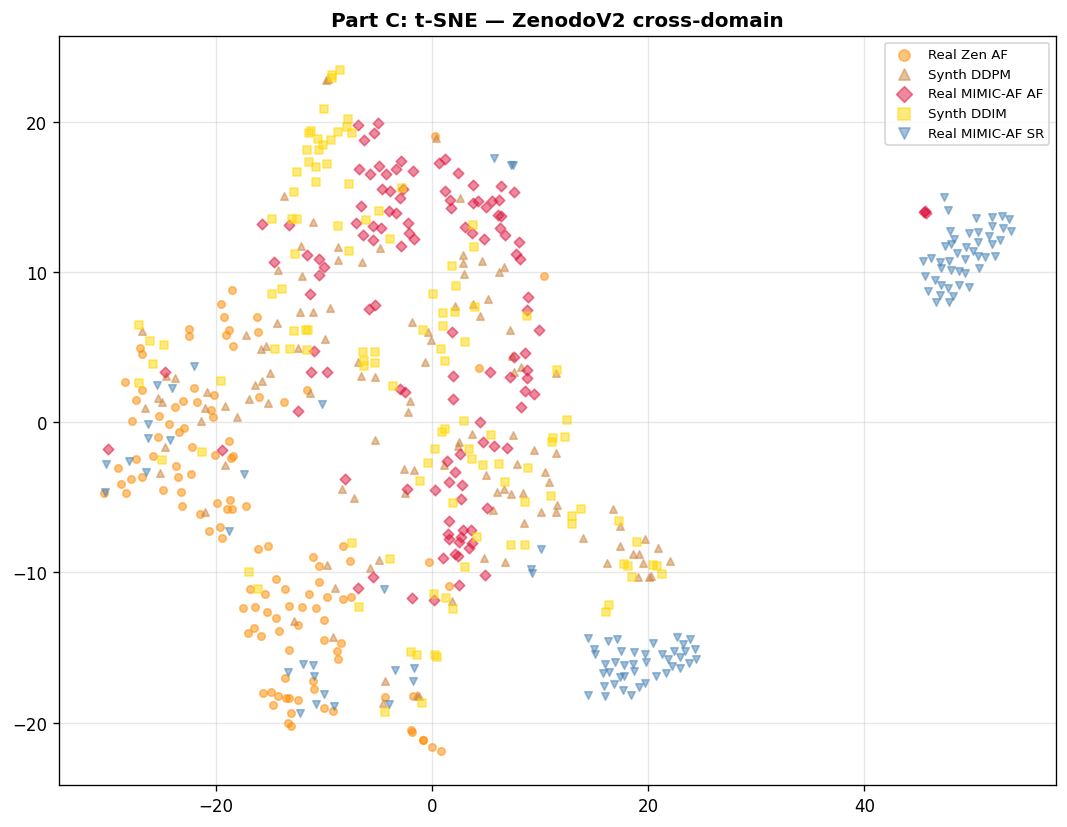


DC1 — Zen-synth AF+MIMIC-AF SR
  seed 0  [MIMIC-AF] AUROC=0.7289  Precision=0.5429  F1=0.7037  [XDom] AUROC=0.8100
  seed 1  [MIMIC-AF] AUROC=0.5218  Precision=0.5429  F1=0.7037  [XDom] AUROC=0.5859
  seed 2  [MIMIC-AF] AUROC=0.7316  Precision=0.5429  F1=0.7037  [XDom] AUROC=0.8114
  seed 3  [MIMIC-AF] AUROC=0.7241  Precision=0.5429  F1=0.7037  [XDom] AUROC=0.8078
  seed 4  [MIMIC-AF] AUROC=0.7215  Precision=0.5429  F1=0.7037  [XDom] AUROC=0.8132

DC2 — Zen-synth+real AF+SR
  seed 0  [MIMIC-AF] AUROC=0.6736  Precision=0.6618  F1=0.7743  [XDom] AUROC=0.7964
  seed 1  [MIMIC-AF] AUROC=0.5195  Precision=0.5314  F1=0.6623  [XDom] AUROC=0.6273
  seed 2  [MIMIC-AF] AUROC=0.6825  Precision=0.6472  F1=0.7714  [XDom] AUROC=0.7954
  seed 3  [MIMIC-AF] AUROC=0.6801  Precision=0.6494  F1=0.7725  [XDom] AUROC=0.7973
  seed 4  [MIMIC-AF] AUROC=0.6706  Precision=0.6600  F1=0.7664  [XDom] AUROC=0.7951

DCref — Real MIMIC-AF AF+SR
  seed 0  [MIMIC-AF] AUROC=0.6142  Precision=0.6543  F1=0.7495  [XDom] 

In [51]:
# ── C2: Generate + C3: Fidelity + C4: ClfUNetGAN ────────────────────────────
synth_zen = {}
if len(cond_zen_np) > 0:
    for sname in ['DDIM', 'DDPM']:
        print(f'Generating {len(cond_zen_np)} ZenodoV2-conditioned [{sname}]...')
        synth_zen[sname] = gen_synth(cond_zen_np, sampler=sname.lower(), n_max=2000)
        print(f'  Done: {synth_zen[sname].shape}')

if len(real_zen) >= 20 and synth_zen:
    print('\nFidelity — ZenodoV2 real AF vs generated:')
    fid_zen = fidelity_report(real_zen, synth_zen, 'ZenodoV2', feats_real_af=feats['real_AF'])

    # t-SNE
    N_TT=min(120,len(real_zen),*[len(v) for v in synth_zen.values()],len(feats['real_AF']),len(feats['real_SR']))
    all_f=np.concatenate([feature_vec(real_zen[:N_TT]),feature_vec(synth_zen['DDIM'][:N_TT]),
                           feature_vec(synth_zen['DDPM'][:N_TT]),feats['real_AF'][:N_TT],feats['real_SR'][:N_TT]])
    all_l=(['Real Zen AF']*N_TT+['Synth DDIM']*N_TT+['Synth DDPM']*N_TT+
            ['Real MIMIC-AF AF']*N_TT+['Real MIMIC-AF SR']*N_TT)
    sc_c=StandardScaler().fit(all_f)
    print('Computing t-SNE (Part C)...')
    emb_c=TSNE(n_components=2,perplexity=30,random_state=SEED,n_iter=1000).fit_transform(sc_c.transform(all_f))
    cols_c={'Real Zen AF':'darkorange','Synth DDIM':'gold','Synth DDPM':'peru',
            'Real MIMIC-AF AF':'crimson','Real MIMIC-AF SR':'steelblue'}
    mrks_c={'Real Zen AF':'o','Synth DDIM':'s','Synth DDPM':'^','Real MIMIC-AF AF':'D','Real MIMIC-AF SR':'v'}
    fig,ax=plt.subplots(figsize=(9,7))
    for lbl in set(all_l):
        msk=[l==lbl for l in all_l]
        ax.scatter(emb_c[msk,0],emb_c[msk,1],c=cols_c[lbl],marker=mrks_c[lbl],alpha=0.5,s=20,label=lbl)
    ax.set_title('Part C: t-SNE — ZenodoV2 cross-domain',fontweight='bold')
    ax.legend(markerscale=1.5,fontsize=8); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

        # ClfUNetGAN (same structure as Part B, DC1/DC2/DCref)
    if 'DDIM' in synth_zen and len(synth_zen['DDIM']) >= 50:
        syn_z=synth_zen['DDIM']
        N_DC=min(len(syn_z),int((y_tr==1).sum()),int((y_tr==0).sum()))
        rng_dc=np.random.default_rng(SEED+400); raf=X_tr[y_tr==1]; rsr=X_tr[y_tr==0]
        NHC=N_DC//2
        dsets_c=[('DC1 — Zen-synth AF+MIMIC-AF SR',np.vstack([samp(syn_z,N_DC,rng_dc),samp(rsr,N_DC,rng_dc)]),np.array([1]*N_DC+[0]*N_DC)),
                  ('DC2 — Zen-synth+real AF+SR',np.vstack([samp(syn_z,NHC,rng_dc),samp(raf,NHC,rng_dc),samp(rsr,N_DC,rng_dc)]),np.array([1]*NHC+[1]*NHC+[0]*N_DC)),
                  ('DCref — Real MIMIC-AF AF+SR',np.vstack([samp(raf,N_DC,rng_dc),samp(rsr,N_DC,rng_dc)]),np.array([1]*N_DC+[0]*N_DC))]
        N_XD_C=min(len(real_zen),int((y_te==0).sum()))
        rng_xdc=np.random.default_rng(SEED+401)
        X_xdom_c=np.vstack([real_zen[rng_xdc.choice(len(real_zen),N_XD_C,replace=False)],
                             X_te[rng_xdc.choice(np.where(y_te==0)[0],N_XD_C,replace=False)]])
        y_xdom_c=np.array([1]*N_XD_C+[0]*N_XD_C)
        N_SEEDS_C=5; res_c_maf,res_c_xdom={},{}
        for ds_name,Xtr_d,ytr_d in dsets_c:
            print(f'\n{ds_name}')
            ml_m={k:[] for k in ['auroc','precision','f1']}; ml_x={k:[] for k in ['auroc','precision','f1']}
            for s in range(N_SEEDS_C):
                torch.manual_seed(s); np.random.seed(s)
                clf,thr=train_clf_ug(Xtr_d,ytr_d,X_vl,y_vl)
                clf.eval()
                for ml,(Xte_,yte_) in [(ml_m,(X_te,y_te)),(ml_x,(X_xdom_c,y_xdom_c))]:
                    m=eval_clf_ug(clf,Xte_,yte_,threshold=thr)
                    for k in ml: ml[k].append(m[k])
                print(f'  seed {s}  [MIMIC-AF] AUROC={ml_m["auroc"][-1]:.4f}  '
                      f'Precision={ml_m["precision"][-1]:.4f}  F1={ml_m["f1"][-1]:.4f}  '
                      f'[XDom] AUROC={ml_x["auroc"][-1]:.4f}')
            res_c_maf[ds_name]={k:(float(np.mean(v)),float(np.std(v))) for k,v in ml_m.items()}
            res_c_xdom[ds_name]={k:(float(np.mean(v)),float(np.std(v))) for k,v in ml_x.items()}
        print(f'\n{"="*80}\n  Part C ClfUNetGAN (DDIM pool, {N_SEEDS_C} seeds)\n{"="*80}')
        for tname,rd in [('[MIMIC-AF test]',res_c_maf),(f'[XDom: Zen AF+MIMIC-AF SR ({N_XD_C}/cls)]',res_c_xdom)]:
            print(f'  {tname}')
            print(f"  {'Dataset':<42}  {'AUROC':>14}  {'Precision':>12}  {'F1':>10}")
            for n,m in rd.items():
                print(f"  {n:<42}  {m['auroc'][0]:.4f}\u00b1{m['auroc'][1]:.3f}  "
                      f"{m['precision'][0]:.4f}\u00b1{m['precision'][1]:.3f}  "
                      f"{m['f1'][0]:.4f}\u00b1{m['f1'][1]:.3f}")
else:
    print('Not enough ZenodoV2 data for Part C.')


---
## Part D — Cross-Domain: VitalDB (FV3)

Mirrors FV3 from the OT-CFM notebook but now using the DDPM model.
Uses real VitalDB AFIB/AFL PPG windows as conditioning source.

- **D.1** Fidelity: LSD · Wasserstein · MMD · DTW · t-SNE (both samplers)
- **D.2** Classifier: ClfUNetGAN (D_VDB1/D_VDB2/D_VDB_ref, both samplers, 2 test sets)

**Prerequisites:** VitalDB pipeline output at `/kaggle/working/vitaldb_af_dataset/`  
or `/kaggle/input/.../vitaldb-af-dataset/` (adjust path if needed).

In [52]:
# ── D1: Load VitalDB ─────────────────────────────────────────────────────────
from pathlib import Path as _VPath
_VDB_CANDIDATES = [
    '/kaggle/working/vitaldb_af_dataset',
    '/kaggle/input/datasets/vegatronxz/vitaldb-af-dataset/vitaldb_af_dataset',
]
VITALDB_OUT = None
for _p in _VDB_CANDIDATES:
    if _VPath(_p).exists(): VITALDB_OUT = _VPath(_p); break
if VITALDB_OUT is None:
    print('VitalDB dataset not found. Adjust _VDB_CANDIDATES.'); _run_d = False
else:
    print(f'VitalDB found: {VITALDB_OUT}')
    ppg_vdb_raw = np.load(VITALDB_OUT/'ppg_windows.npy').astype(np.float32)   # z-scored
    meta_vdb    = pd.read_csv(VITALDB_OUT/'metadata_windows.csv')
    print(f'  PPG: {ppg_vdb_raw.shape}  IBI rows: {len(meta_vdb)}')
    print(f'  Cases: {meta_vdb["case_id"].nunique()}')
    print(meta_vdb[['ibi_mean','ibi_std','rmssd']].describe().round(4).iloc[1:4].to_string())

    # Rescale z-scored VitalDB PPG → [-1,1] to match model output space
    def _zscore_to_mm(signals):
        out=np.empty_like(signals)
        for i,sig in enumerate(signals):
            mn,mx=sig.min(),sig.max()
            out[i]=2*(sig-mn)/(mx-mn)-1 if mx-mn>1e-8 else np.zeros_like(sig)
        return out.astype(np.float32)
    ppg_vdb_mm = _zscore_to_mm(ppg_vdb_raw)
    print(f'  After rescaling: range=[{ppg_vdb_mm.min():.2f},{ppg_vdb_mm.max():.2f}]')

    # VitalDB conditioning → normalise with MIMIC-AF training stats
    nm_v,ns_v,nr_v=norm_ibi(meta_vdb.ibi_mean.values,meta_vdb.ibi_std.values,meta_vdb.rmssd.values)
    cond_vdb_np=np.stack([nm_v,ns_v,nr_v,np.ones(len(nm_v),dtype=np.float32)],axis=1)
    _run_d = True


VitalDB found: /kaggle/input/datasets/vegatronxz/vitaldb-af-dataset/vitaldb_af_dataset
  PPG: (12461, 1250)  IBI rows: 12461
  Cases: 106
      ibi_mean  ibi_std   rmssd
mean    0.7751   0.1673  0.2302
std     0.1992   0.0887  0.1258
min     0.3688   0.0012  0.0013
  After rescaling: range=[-1.00,1.00]


Generating 3200 VitalDB-conditioned [DDIM]...
  Done: (3200, 1250)
Generating 3200 VitalDB-conditioned [DDPM]...
  Done: (3200, 1250)

Fidelity — VitalDB real AF vs generated (both samplers):
  [DDIM]  LSD=7.43 dB  WD=3.7622  MMD²=0.06574  DTW=35.129
  [DDPM]  LSD=7.47 dB  WD=3.8442  MMD²=0.06292  DTW=32.797
  [Domain gap: VitalDB vs MIMIC-AF real AF]  MMD²=0.40989
Computing t-SNE (Part D)...


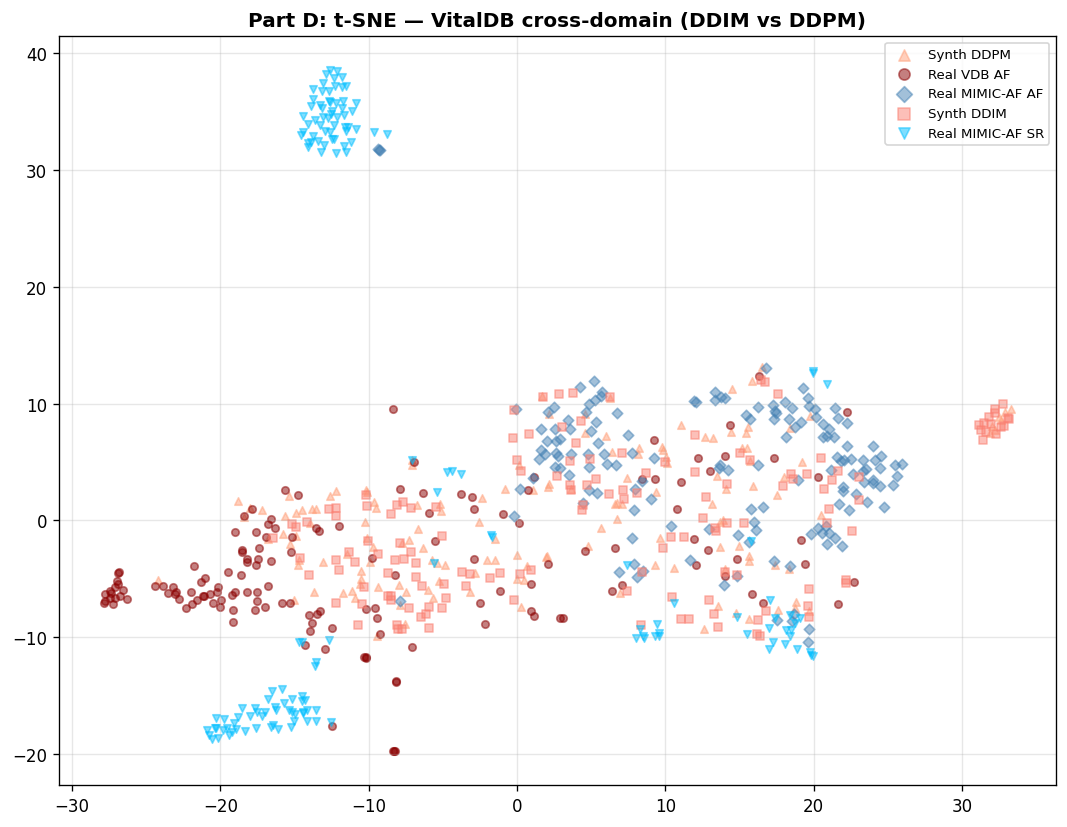

In [55]:
# ── D2–D3: Generate both samplers + fidelity ─────────────────────────────────
synth_vdb = {}
if _run_d:
    N_VDB_GEN = min(3200, len(cond_vdb_np))
    rng_v = np.random.default_rng(SEED)
    idx_v = rng_v.choice(len(cond_vdb_np), N_VDB_GEN, replace=False)
    cond_vdb_sub   = cond_vdb_np[idx_v]
    ppg_vdb_sub_mm = ppg_vdb_mm[idx_v]   # matching real windows

    for sname in ['DDIM', 'DDPM']:
        print(f'Generating {N_VDB_GEN} VitalDB-conditioned [{sname}]...')
        synth_vdb[sname] = gen_synth(cond_vdb_sub, sampler=sname.lower())
        print(f'  Done: {synth_vdb[sname].shape}')

    print('\nFidelity — VitalDB real AF vs generated (both samplers):')
    fid_vdb = fidelity_report(ppg_vdb_sub_mm, synth_vdb, 'VitalDB',
                               feats_real_af=feats['real_AF'])

    # t-SNE (5-way)
    N_TT=min(150,len(ppg_vdb_sub_mm),*[len(v) for v in synth_vdb.values()],
             len(feats['real_AF']),len(feats['real_SR']))
    all_f=np.concatenate([feature_vec(ppg_vdb_sub_mm[:N_TT]),
                           feature_vec(synth_vdb['DDIM'][:N_TT]),
                           feature_vec(synth_vdb['DDPM'][:N_TT]),
                           feats['real_AF'][:N_TT],feats['real_SR'][:N_TT]])
    all_l=(['Real VDB AF']*N_TT+['Synth DDIM']*N_TT+['Synth DDPM']*N_TT+
            ['Real MIMIC-AF AF']*N_TT+['Real MIMIC-AF SR']*N_TT)
    sc_d=StandardScaler().fit(all_f)
    print('Computing t-SNE (Part D)...')
    emb_d=TSNE(n_components=2,perplexity=40,random_state=SEED,n_iter=1000).fit_transform(sc_d.transform(all_f))
    cols_d={'Real VDB AF':'darkred','Synth DDIM':'salmon','Synth DDPM':'lightsalmon',
            'Real MIMIC-AF AF':'steelblue','Real MIMIC-AF SR':'deepskyblue'}
    mrks_d={'Real VDB AF':'o','Synth DDIM':'s','Synth DDPM':'^','Real MIMIC-AF AF':'D','Real MIMIC-AF SR':'v'}
    fig,ax=plt.subplots(figsize=(9,7))
    for lbl in set(all_l):
        msk=[l==lbl for l in all_l]
        ax.scatter(emb_d[msk,0],emb_d[msk,1],c=cols_d[lbl],marker=mrks_d[lbl],alpha=0.5,s=20,label=lbl)
    ax.set_title('Part D: t-SNE — VitalDB cross-domain (DDIM vs DDPM)',fontweight='bold')
    ax.legend(markerscale=1.5,fontsize=8); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


In [56]:
# ── D4: ClfUNetGAN — VitalDB conditioned synthetics (both samplers) ───────────
if _run_d:
    N_VDB_CLF=min(len(synth_vdb['DDIM']),int((y_tr==1).sum()),int((y_tr==0).sum()))
    N_SEEDS_D=5
    results_vdb_full = {}  # {sampler: {test_set: {ds_name: metrics}}}

    N_XD_D=min(len(ppg_vdb_mm),int((y_te==0).sum()))
    rng_xvd=np.random.default_rng(SEED+500)
    X_xdom_d=np.vstack([ppg_vdb_mm[rng_xvd.choice(len(ppg_vdb_mm),N_XD_D,replace=False)],
                         X_te[rng_xvd.choice(np.where(y_te==0)[0],N_XD_D,replace=False)]])
    y_xdom_d=np.array([1]*N_XD_D+[0]*N_XD_D)

    for sname in ['DDIM','DDPM']:
        syn_v=synth_vdb[sname]
        rng_dv=np.random.default_rng(SEED+501); raf=X_tr[y_tr==1]; rsr=X_tr[y_tr==0]
        NHV=N_VDB_CLF//2
        dsets_d=[('D_VDB1 — VDB-synth AF+MIMIC-AF SR',
                   np.vstack([samp(syn_v,N_VDB_CLF,rng_dv),samp(rsr,N_VDB_CLF,rng_dv)]),
                   np.array([1]*N_VDB_CLF+[0]*N_VDB_CLF)),
                  ('D_VDB2 — VDB-synth+real AF+SR (hybrid)',
                   np.vstack([samp(syn_v,NHV,rng_dv),samp(raf,NHV,rng_dv),samp(rsr,N_VDB_CLF,rng_dv)]),
                   np.array([1]*NHV+[1]*NHV+[0]*N_VDB_CLF)),
                  ('D_VDB_ref — Real MIMIC-AF AF+SR',
                   np.vstack([samp(raf,N_VDB_CLF,rng_dv),samp(rsr,N_VDB_CLF,rng_dv)]),
                   np.array([1]*N_VDB_CLF+[0]*N_VDB_CLF))]
        res_maf,res_xdom={},{}
        print(f'\n>>> Sampler: {sname}')
        for ds_name,Xtr_d,ytr_d in dsets_d:
            print(f'  {ds_name}')
            ml_m={k:[] for k in ['auroc','precision','f1']}; ml_x={k:[] for k in ['auroc','precision','f1']}
            for s in range(N_SEEDS_D):
                torch.manual_seed(s); np.random.seed(s)
                clf,thr=train_clf_ug(Xtr_d,ytr_d,X_vl,y_vl)
                clf.eval()
                for ml,(Xte_,yte_) in [(ml_m,(X_te,y_te)),(ml_x,(X_xdom_d,y_xdom_d))]:
                    m=eval_clf_ug(clf,Xte_,yte_,threshold=thr)
                    for k in ml: ml[k].append(m[k])
                print(f'    seed {s}  [MIMIC-AF] AUROC={ml_m["auroc"][-1]:.4f}  '
                      f'Precision={ml_m["precision"][-1]:.4f}  F1={ml_m["f1"][-1]:.4f}  '
                      f'[VDB XDom] AUROC={ml_x["auroc"][-1]:.4f}')
            res_maf[ds_name]={k:(float(np.mean(v)),float(np.std(v))) for k,v in ml_m.items()}
            res_xdom[ds_name]={k:(float(np.mean(v)),float(np.std(v))) for k,v in ml_x.items()}
        results_vdb_full[sname]={'mimic_af':res_maf,'cross_dom':res_xdom}

    print(f'\n{"="*100}')
    print(f'  Part D — ClfUNetGAN VitalDB (5 seeds)')
    print(f'{"="*100}')
    for sname in ['DDIM','DDPM']:
        for tname,rkey in [('[MIMIC-AF test]','mimic_af'),(f'[XDom: VDB AF+MIMIC-AF SR ({N_XD_D}/cls)]','cross_dom')]:
            print(f'  Sampler={sname}  {tname}')
            rdict=results_vdb_full[sname][rkey]
            print(f"  {'Dataset':<45}  {'AUROC':>14}  {'Precision':>12}  {'F1':>10}")
            for n,m in rdict.items():
                print(f"  {n:<45}  {m['auroc'][0]:.4f}\u00b1{m['auroc'][1]:.3f}  "
                      f"{m['precision'][0]:.4f}\u00b1{m['precision'][1]:.3f}  "
                      f"{m['f1'][0]:.4f}\u00b1{m['f1'][1]:.3f}")
        d1 =results_vdb_full[sname]['cross_dom'].get('D_VDB1 — VDB-synth AF+MIMIC-AF SR',{})
        ref=results_vdb_full[sname]['cross_dom'].get('D_VDB_ref — Real MIMIC-AF AF+SR',{})
        if d1 and ref:
            print(f'  [{sname}] Cross-domain gap D_VDB1 vs ref: '
                  f'AUROC {d1["auroc"][0]-ref["auroc"][0]:+.4f}  '
                  f'F1 {d1["f1"][0]-ref["f1"][0]:+.4f}')


>>> Sampler: DDIM
  D_VDB1 — VDB-synth AF+MIMIC-AF SR
    seed 0  [MIMIC-AF] AUROC=0.7287  Precision=0.5429  F1=0.7037  [VDB XDom] AUROC=0.4371
    seed 1  [MIMIC-AF] AUROC=0.4189  Precision=0.5429  F1=0.7037  [VDB XDom] AUROC=0.8438
    seed 2  [MIMIC-AF] AUROC=0.7277  Precision=0.5429  F1=0.7037  [VDB XDom] AUROC=0.3850
    seed 3  [MIMIC-AF] AUROC=0.7182  Precision=0.5429  F1=0.7037  [VDB XDom] AUROC=0.4460
    seed 4  [MIMIC-AF] AUROC=0.7307  Precision=0.5429  F1=0.7037  [VDB XDom] AUROC=0.4368
  D_VDB2 — VDB-synth+real AF+SR (hybrid)
    seed 0  [MIMIC-AF] AUROC=0.6973  Precision=0.6348  F1=0.7708  [VDB XDom] AUROC=0.5451
    seed 1  [MIMIC-AF] AUROC=0.4769  Precision=0.5429  F1=0.7037  [VDB XDom] AUROC=0.8423
    seed 2  [MIMIC-AF] AUROC=0.6967  Precision=0.5683  F1=0.7240  [VDB XDom] AUROC=0.5507
    seed 3  [MIMIC-AF] AUROC=0.7020  Precision=0.5711  F1=0.7266  [VDB XDom] AUROC=0.5395
    seed 4  [MIMIC-AF] AUROC=0.6929  Precision=0.6316  F1=0.7667  [VDB XDom] AUROC=0.5547
  D_

---
## §13 — Data Scarcity (both classifiers, DDIM + optional DDPM)

N AF subjects varied, all SR always included (MIMIC-AF specificity: AF and SR disjoint).

- `TRTR_N`: trained on N×AF real + all SR real  
- `ClfB_N (DDIM)`: trained on (N×AF real + N×AF DDIM synth) + all SR real  
- `ClfB_N (DDPM)`: same with DDPM ancestral pool (set `_RUN_DDPM_SCAR=True` to enable)

5 subject-sampling seeds. Both ClfUNetGAN and Clf1D.

In [58]:
# ── E0: Setup + references ────────────────────────────────────────────────────
_RUN_DDPM_SCAR = True   # Set False to skip DDPM ancestral pool (~10× slower)

def _load_fold(df_fold, max_per_class=None):
    signals, labels = [], []
    for rh, lbl in [('AF',1),('SR',0)]:
        sub = df_fold[df_fold.event_rhythm==rh]
        if max_per_class: sub = sub.sample(min(max_per_class,len(sub)),random_state=SEED)
        for _,row in sub.iterrows():
            sig = load_ppg(row['csv_path'],int(row['start_sample']))
            if sig is not None: signals.append(sig); labels.append(lbl)
    return np.array(signals), np.array(labels)

_scar_af_subj = list(df_train[df_train.event_rhythm=='AF']['subject_id'].unique())
_scar_sr_df   = df_train[df_train.event_rhythm=='SR']
print(f'AF subjects in train: {len(_scar_af_subj)}')
print(f'SR windows always included: {len(_scar_sr_df):,}')

# Synthetic pools for scarcity
print('\nGenerating DDIM scarcity pool (2000/class)...')
N_SCAR_POOL = 2000
_pool_ddim = {}
for rh in ['AF','SR']:
    df_c=df_train[df_train.event_rhythm==rh].sample(
        min(N_SCAR_POOL,len(df_train[df_train.event_rhythm==rh])),random_state=SEED+60)
    nm,ns,nr=norm_ibi(df_c.IBI_mean.values,df_c.IBI_std.values,df_c.RMSSD.values)
    sign=np.full(len(nm),{'AF':1.,'SR':-1.}[rh],dtype=np.float32)
    cond_p=np.stack([nm,ns,nr,sign],axis=1)
    _pool_ddim[rh]=gen_synth(cond_p,sampler='ddim')
    print(f'  DDIM {rh}: {_pool_ddim[rh].shape[0]}')

_pool_ddpm = {}
if _RUN_DDPM_SCAR:
    print('\nGenerating DDPM ancestral scarcity pool (2000/class)...')
    for rh in ['AF','SR']:
        df_c=df_train[df_train.event_rhythm==rh].sample(
            min(N_SCAR_POOL,len(df_train[df_train.event_rhythm==rh])),random_state=SEED+70)
        nm,ns,nr=norm_ibi(df_c.IBI_mean.values,df_c.IBI_std.values,df_c.RMSSD.values)
        sign=np.full(len(nm),{'AF':1.,'SR':-1.}[rh],dtype=np.float32)
        cond_p=np.stack([nm,ns,nr,sign],axis=1)
        _pool_ddpm[rh]=gen_synth(cond_p,sampler='ddpm')
        print(f'  DDPM {rh}: {_pool_ddpm[rh].shape[0]}')
else:
    print('DDPM scarcity pool skipped (_RUN_DDPM_SCAR=False).')

# Full-data reference (uncapped)
print('\nComputing full-data TRTR references (uncapped)...')
X_tr_full, y_tr_full = _load_fold(df_train, max_per_class=50_000)
print(f'  Full train: {X_tr_full.shape}  AF={int((y_tr_full==1).sum())} SR={int((y_tr_full==0).sum())}')
_ref_ug, _ref_c1d = [], []
for s in range(5):
    torch.manual_seed(s); np.random.seed(s)
    c1,t1=train_clf_ug(X_tr_full,y_tr_full,X_vl,y_vl); _ref_ug.append(eval_clf_ug(c1,X_te,y_te,threshold=t1)['auroc'])
    c2,t2=train_clf(X_tr_full,y_tr_full,X_vl,y_vl);     _ref_c1d.append(eval_clf(c2,X_te,y_te,threshold=t2)['auroc'])
REF_UG  = float(np.mean(_ref_ug))
REF_C1D = float(np.mean(_ref_c1d))
print(f'  ClfUNetGAN TRTR (full): {REF_UG:.4f}\u00b1{np.std(_ref_ug):.4f}')
print(f'  Clf1D      TRTR (full): {REF_C1D:.4f}\u00b1{np.std(_ref_c1d):.4f}')


AF subjects in train: 13
SR windows always included: 2,384

Generating DDIM scarcity pool (2000/class)...
  DDIM AF: 2000
  DDIM SR: 2000

Generating DDPM ancestral scarcity pool (2000/class)...
  DDPM AF: 2000
  DDPM SR: 2000

Computing full-data TRTR references (uncapped)...
  Full train: (5438, 1250)  AF=3064 SR=2374
  ClfUNetGAN TRTR (full): 0.6177±0.0399
  Clf1D      TRTR (full): 0.3554±0.0777


In [59]:
# ── E1–E2: Scarcity loop (both classifiers × both samplers) ──────────────────
N_VALUES_E = [3, 5, 8, 12, 15]
N_SEEDS_E  = 5
_pools_to_test = {'DDIM': _pool_ddim}
if _RUN_DDPM_SCAR and _pool_ddpm: _pools_to_test['DDPM'] = _pool_ddpm

_scar_results = {}  # {clf_name: {pool_name: {N: {'TRTR':..,'ClfB':..}}}}

for clf_name, _train_fn, _eval_fn, _ref_auroc in [
        ('ClfUNetGAN', train_clf_ug, eval_clf_ug, REF_UG),
        ('Clf1D',      train_clf,    eval_clf,    REF_C1D)]:
    _scar_results[clf_name] = {}
    for pool_name, pool in _pools_to_test.items():
        _scar_results[clf_name][pool_name] = {}
        print(f'\n── {clf_name} × {pool_name} pool ──────────────────────────────────────────')
        for N in N_VALUES_E:
            n_sel=min(N,len(_scar_af_subj)); auroc_tr,auroc_cb=[],[]
            for seed in range(N_SEEDS_E):
                rng_sc=np.random.default_rng(seed*1000+N)
                sel=rng_sc.choice(_scar_af_subj,n_sel,replace=False)
                df_af_sc=df_train[df_train.subject_id.isin(sel)&(df_train.event_rhythm=='AF')]
                Xr,yr=_load_fold(pd.concat([df_af_sc,_scar_sr_df]),max_per_class=50_000)
                n_af_r,n_sr_r=int((yr==1).sum()),int((yr==0).sum())
                if n_af_r<4 or n_sr_r<4: continue
                torch.manual_seed(seed); np.random.seed(seed)
                ct,tht=_train_fn(Xr,yr,X_vl,y_vl)
                mt=_eval_fn(ct,X_te,y_te,threshold=tht); auroc_tr.append(mt['auroc'])
                rng_b=np.random.default_rng(seed*1000+N+500)
                af_s=pool['AF'][rng_b.choice(len(pool['AF']),min(n_af_r,len(pool['AF'])),replace=False)]
                sr_s=pool['SR'][rng_b.choice(len(pool['SR']),min(n_sr_r,len(pool['SR'])),replace=False)]
                Xa=np.vstack([Xr[yr==1],af_s,Xr[yr==0],sr_s])
                ya=np.array([1]*(n_af_r+len(af_s))+[0]*(n_sr_r+len(sr_s)))
                torch.manual_seed(seed+9999); np.random.seed(seed+9999)
                cb,thb=_train_fn(Xa,ya,X_vl,y_vl)
                mb=_eval_fn(cb,X_te,y_te,threshold=thb); auroc_cb.append(mb['auroc'])
            if auroc_tr:
                _scar_results[clf_name][pool_name][N]={
                    'TRTR':(float(np.mean(auroc_tr)),float(np.std(auroc_tr))),
                    'ClfB':(float(np.mean(auroc_cb)),float(np.std(auroc_cb)))}
        # Print table for this combination
        print(f'\n  {clf_name} × {pool_name}  [SR always full, {N_SEEDS_E} seeds]')
        print(f"  {'N':>6}  {'TRTR_N':>20}  {'ClfB_N':>20}  {'\u0394':>9}  {'Gap closed':>12}")
        print('  '+'─'*72)
        for N,r in sorted(_scar_results[clf_name][pool_name].items()):
            delta=r['ClfB'][0]-r['TRTR'][0]
            gap=_ref_auroc-r['TRTR'][0]
            closed=f'{delta/gap:>11.1%}' if gap>1e-4 else ('  TRTR>ref' if gap<-1e-4 else '   at ref')
            print(f"  {N:>6}  {r['TRTR'][0]:.4f}\u00b1{r['TRTR'][1]:.4f}        "
                  f"{r['ClfB'][0]:.4f}\u00b1{r['ClfB'][1]:.4f}        "
                  f"{delta:>+9.4f}  {closed}")
        print(f"  {'Full':>6}  {_ref_auroc:.4f} (ref)")



── ClfUNetGAN × DDIM pool ──────────────────────────────────────────

  ClfUNetGAN × DDIM  [SR always full, 5 seeds]
       N                TRTR_N                ClfB_N          Δ    Gap closed
  ────────────────────────────────────────────────────────────────────────
       3  0.5665±0.0704        0.5797±0.0935          +0.0131        25.6%
       5  0.5895±0.0548        0.6475±0.0585          +0.0580       205.8%
       8  0.6125±0.0545        0.5546±0.1151          -0.0580     -1120.0%
      12  0.6177±0.0482        0.6050±0.0373          -0.0128     at ref
      15  0.6156±0.0384        0.5656±0.0456          -0.0500     -2380.4%
    Full  0.6177 (ref)

── ClfUNetGAN × DDPM pool ──────────────────────────────────────────

  ClfUNetGAN × DDPM  [SR always full, 5 seeds]
       N                TRTR_N                ClfB_N          Δ    Gap closed
  ────────────────────────────────────────────────────────────────────────
       3  0.5703±0.0682        0.5792±0.0511          +0.0089 

In [60]:
# ── E3: Joint summary table ───────────────────────────────────────────────────
print()
print('='*90)
print('  Part E — Data Scarcity Joint Summary: Δ AUROC (ClfB − TRTR)')
print('='*90)
header = f"  {'N':>6}"
for clf_name in _scar_results:
    for pool_name in _scar_results[clf_name]:
        header += f"  {clf_name[:3]}×{pool_name[:4]:>8}"
print(header); print('  '+'─'*80)
for N in N_VALUES_E:
    row = f'  {N:>6}'
    for clf_name in _scar_results:
        for pool_name in _scar_results[clf_name]:
            r = _scar_results[clf_name][pool_name].get(N,{})
            delta = r['ClfB'][0]-r['TRTR'][0] if r else float('nan')
            row += f'  {delta:>+13.4f}'
    print(row)
print('='*90)
print('\u0394 > 0 \u2192 synthetic augmentation helps at this N.')
print('Columns: ClfUNetGAN/Clf1D × DDIM/DDPM pool')
print('Expected pattern: positive \u0394 at small N (data-limited regime), '
      'near-zero at large N (saturated regime).')



  Part E — Data Scarcity Joint Summary: Δ AUROC (ClfB − TRTR)
       N  Clf×    DDIM  Clf×    DDPM  Clf×    DDIM  Clf×    DDPM
  ────────────────────────────────────────────────────────────────────────────────
       3        +0.0131        +0.0089        -0.1443        -0.1138
       5        +0.0580        +0.0354        -0.1837        -0.1092
       8        -0.0580        +0.0069        -0.2577        -0.1671
      12        -0.0128        -0.0032        -0.1084        -0.0252
      15        -0.0500        -0.0062        -0.1122        -0.1353
Δ > 0 → synthetic augmentation helps at this N.
Columns: ClfUNetGAN/Clf1D × DDIM/DDPM pool
Expected pattern: positive Δ at small N (data-limited regime), near-zero at large N (saturated regime).
